In [46]:
import math
import glob, os    #, h5py
import torch as tc
import qutip as qt
from qutip import *
from qutip_qip.operations import ry, rz, rx
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import pylab as plab
from scipy.optimize import minimize
from scipy.stats import unitary_group
from torchmin import minimize_constr
import torch
import torch.optim as optim
import sympy as sym
import itertools
%matplotlib inline

In [2]:
# --- Global settings 

# file_directory = r'/home/roytanay/Sideband'

default_dtype = torch.float64
complex_dtype = torch.complex64
numpy_tolerance = 1e-6
MIXED_PRECISION = True

# ---

torch.set_default_dtype(default_dtype)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

print('--- Notes ---')
print('You must use a CUDA-enabled GPU to run this notebook.')
print('--- Device ---')
print('Device (GPU) count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('CUDA available. Current device:', torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print('No CUDA device available; skipping device name query.')

print('Using device:', device)

print('Mixed precision via autocast available for CUDA:', torch.amp.autocast_mode.is_autocast_available('cuda'))

print('--- Datatype ---')
print(f"Default dtype: {torch.get_default_dtype()}")
print('Default complex dtype:', complex_dtype)
print('Using mixed precision (bfloat16):', MIXED_PRECISION)

--- Notes ---
You must use a CUDA-enabled GPU to run this notebook.
--- Device ---
Device (GPU) count: 1
CUDA available. Current device: NVIDIA A100 80GB PCIe MIG 2g.20gb
Using device: cuda:0
Mixed precision via autocast available for CUDA: True
--- Datatype ---
Default dtype: torch.float64
Default complex dtype: torch.complex64
Using mixed precision (bfloat16): True


In [3]:
GHz = 1
MHz = 1e-3
kHz = 1e-6
Hz = 1e-9

Nc = 1500
a = qt.tensor(qt.destroy(Nc), qt.qeye(2))
sigz = qt.tensor(qt.qeye(Nc), qt.sigmaz())
sigp = qt.tensor(qt.qeye(Nc), qt.sigmam())
sigm = qt.tensor(qt.qeye(Nc), qt.sigmap())
sigx = sigp + sigm
sigy = -1j*(sigm - sigp)

## Free Hamiltonian

$$ H = -\frac{\chi}{2}\hat{a}^\dagger \hat{a}\hat{\sigma}_z - \frac{\chi'}{2}\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}\hat{\sigma}_z - K_s\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a} $$

Note that $\hat{n}^2 = \hat{n} + \hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}$ (i.e.,   $\hat{n}^2 \equiv\hat{a}^\dagger\hat{a}^\dagger\hat{a}\hat{a}$),  since the $\hat{n}$ term will be combined with the other Hamiltonian terms. Hence the Hamiltonian above describes 
$$ H \equiv \frac{\chi}{2}\hat{n}\hat{\sigma}_z - \frac{\chi'}{2}\hat{n}^2\hat{\sigma}_z- K_s\hat{n}^2$$ 
where $\chi$ is the first-order Dispersive shift, $\chi'$ is the second-order correction to the dispersive shift and $K_s$ is the Kerr self nonlinearity.


## Drive Hamiltonian
$$ H_d = C_I(t)[\hat{a}+ \hat{a}^\dagger] - i C_Q(t)[\hat{a}+ \hat{a}^\dagger] + q_I(t)\hat{\sigma}_x + q_Q(t)\hat{\sigma}_y$$

where $C_{I,Q}$ are the cavity drives in the $I-Q$ quadrature while $q_{I,Q}$ are the qubit drives in the $I-Q$ quadrature.

## Arbitrary unitary decomposition

Define the Echoed Conditional Displacement (ECD) gate as 

$$\text{ECD}(\beta) = D(\beta/2)|e\rangle |g\rangle + D(-\beta/2)|g\rangle |e\rangle = \sigma_xD(\beta\sigma_z/2)$$

where $\beta\in \mathbb{C}$ and $D(\alpha) = e^{\alpha \hat{a}^\dagger- \alpha^*\hat{a}}$.

Define arbitrary rotation as 
$$ 
R_\varphi(\theta) = \exp{\left[-i\frac{\theta}{2}(\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi))\right]} = \cos(\theta/2)I - i[\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi)]\sin(\theta/2).$$
 
where the right hand side is by the Euler identity since $[\sigma_x\cos(\varphi)+ \sigma_y\sin(\varphi)]^2=1$. i.e  Rotation by $\theta$ about the axis $(\cos\varphi, \sin\varphi, 0)$ in the $XY-$plane.

The ECD and Rotation gate form a universal gateset as seen in https://journals.aps.org/rmp/pdf/10.1103/RevModPhys.77.513




From above reference, the an ECD($\beta$) is decomposed into (hardware) gates (of 4 Displacements and one $\pi$ gate on the Transmon) such that 
$$\text{ECD}(\beta) \approx \text{ECD}(2i\alpha\sin(\chi T/2))$$
where $\chi$ is the dispersive coupling, $T$ is the total gate duration. Hence, the displacement in the cavity has a radius $\chi T \alpha$. Hence, from dimension analysis,  $\beta\sim \mu Hz $ since $\chi\sim KHz$, and $T \sim ns$. 

Recall that $\langle \beta |\hat{N}|\beta\rangle = \beta^2$, where $\hat{N} = \hat{a}^\dagger\hat{a}$. Hence, for the state $|\beta\rangle$ in the cavity the average number of photons is $|\beta|^2$ .i.e. If the number of photons feasible on a hardware is $\sim 30$, then the expected displacement distance is $\sim 5.477$.

Theoretically, the expected number of blocks to reach 'good' fidelity = $((2N_{trunc})^2-1)/4 = N_{trunc}^2- 1/4 \sim \mathcal{O}(N_{trunc}^2)$.

In [4]:
def ECD_Compile(N_blocks, Unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp = False):
    
    def tc_fock(N_trunc, n):
        return tc.kron(tc.tensor(qutip.fock(2,0).full(), dtype= complex_dtype),tc.tensor(qutip.fock(N_trunc,n).full(),dtype= complex_dtype))
    
    def tc_sigmax():
        return tc.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=complex_dtype)

    def tc_sigmay():
        return tc.tensor([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex_dtype)
        
    
    def tc_sigmap():
        ''' torch sigmap'''
        X = tc.tensor([[0,1], [0,0]], dtype=complex_dtype)
        return X
        
    def tc_sigmam():
        ''' torch sigmam'''
        X = tc.tensor([[0,0], [1,0]], dtype=complex_dtype)
        return X
    
    def tc_displace(N, alpha):
        """
        Defines the displacement operator D(alpha) using only numpy and scipy.
        N: Hilbert space dimension
        alpha: Complex displacement amplitude
        """
        
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(1, N):
            a[n-1, n] = tc.sqrt(tc.tensor(n))
            
        # 2. Create creation operator (a^\dagger)
        adag = a.H                # This performs conjugate Transpose operation
        
        # 3. Form the operator: alpha*a^\dagger - alpha*conj(a)
        operator_exponent = alpha * adag - tc.conj(alpha) * a
        
        # 4. Compute matrix exponential
        displacement_operator = tc.linalg.matrix_exp(operator_exponent)
        
        return displacement_operator

    
    def tc_idty(N):
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(N):
            a[n, n] = 1
        return a
        
    def ECD(beta_real, beta_imag, T_dim):    
        return tc.kron(tc_sigmap(), tc_displace(T_dim, (beta_real+ 1j*beta_imag)/2)) + tc.kron(tc_sigmam(), tc_displace(T_dim, -(beta_real+ 1j*beta_imag)/2))
    
    
    def Rot(phi, theta, T_dim):
        sx = tc.kron(tc_sigmax(), tc_idty(T_dim))
        sy = tc.kron(tc_sigmay(), tc_idty(T_dim))
        idty = tc.kron(tc_idty(2), tc_idty(T_dim))
        if theta == 0:
            return idty
        else:          
            return ((torch.cos(theta/2.0))*idty - 1j * ((torch.cos(phi) * sx) + (torch.sin(phi) * sy)) * torch.sin(theta/2.0))

    def P_Ntrunc(N_trunc, bumper):
        ''' Projection unto computational space '''
        T_dim = N_trunc + bumper
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for i in range(N_trunc):
            mat[i,i]=1 
        return mat
        
    def Q_Ntrunc(N_trunc, bumper):
        ''' Projection unto bumper space '''
        T_dim = N_trunc + bumper
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for j in range(0,N_trunc):
            for i in range(N_trunc, T_dim):
                mat[j,i] = 1 
        return mat

    def Full_Unitary(Unitary, bumper, N_trunc):
        T_dim = bumper +N_trunc
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for i in range(N_trunc):
            for j in range(N_trunc):
                mat[i,j] = Unitary[i,j]
        for k in range(N_trunc, T_dim):
            mat[k,k] = 1                
        return mat
            

    
    # One ECD Block
    def U_block_ECD(beta_real, beta_imag, phi, theta, T_dim):
        return ECD(beta_real, beta_imag,  T_dim) @ Rot(phi, theta, T_dim) 

    # Sequence of ECD blocks
    def U_circuit_ECD(betas_real, betas_imag, phis, thetas, bumper, N_trunc):

        T_dim = bumper + N_trunc
        b_state_pop ={}                                            # bumper state population
        for index in range(N_trunc, T_dim):
            b_state_pop[f'{index}'] = [] 

        
        U = tc.kron(tc_idty(2), tc_idty(T_dim))
        block_list = []
        for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
            block_list.append(U_block_ECD(beta_real, beta_imag, phi, theta, T_dim))


        state = tc_fock(T_dim,0)
        for num in range(len(block_list)):
            U = block_list[num]@ U
            
            state = block_list[num]@state        # final cavity state (starting with cavity = |0>, Transmon = |g>) after each ECD+Rot block 
            for k in range(T_dim-pen, T_dim):
                prob = tc.tensor((np.exp(k+1))/np.exp(T_dim))*(tc.abs(tc_fock(T_dim,k).H @state))**2
                b_state_pop[f'{k}'].append(prob)        #.detach().numpy()[0][0])
        
        if Add_block == False:
            return U,  b_state_pop  
            
        else:
            U = tc.kron(tc_idty(2), tc_displace(T_dim, (betas_real[-1]+ 1j*betas_imag[-1])/2)) @ Rot(phis[-1], thetas[-1], T_dim) @ U
            block_list.append(U)            
            state = U@state 
            
            for k in range(N_trunc, T_dim):
                prob = tc.tensor(k/T_dim) *(tc.abs(tc_fock(T_dim,k).H @state))**2
                b_state_pop[f'{k}'].append(prob)        #.detach().numpy()[0][0])
        
            return U,  b_state_pop 


    def state_cost(state_dict,N_trunc, bumper):   
        T_dim = N_trunc+bumper
        sums = 0
        for index in range(N_trunc, T_dim):
            l = len(state_dict[f'{index}'])
            sums += sum(state_dict[f'{index}'])
        return sums
   
    def Unitary_cost(Oper1, Oper2, N_trunc):
        ''' oper1 should always be the target unitary'''

        upper = Oper1[0:N_trunc, 0:N_trunc] - Oper2[0:N_trunc, 0:N_trunc]
        d = tc.tensor(upper.shape[0])
        Uval = tc.sqrt(tc.abs(tc.trace(upper.H @ upper)))/d
        return Uval

    def Unitary_cost2(Oper1, Oper2, N_trunc):
        T_dim = N_trunc
        mat = Oper1[0:T_dim, 0:T_dim] - Oper2[0:T_dim, 0:T_dim]
        val1  = tc.sqrt(tc.abs(tc.trace(mat.H @ mat)))/tc.tensor(mat.shape[0])
        return val1
        

    
    opt_process = {}  
    def my_callback(result):
        """
        A callback function to monitor optimization progress.
        """
        val = Error_func(result, Unitary, N_trunc)
        opt_process[val]= result
    
    
    b_state_pop ={}      # bumper state population
    for index in range(N_trunc, bumper+N_trunc):
        b_state_pop[f'{index}'] = [] 
        
    def Error_func(params, Unitary, bumper, N_trunc):
        '''params=[betas, varphis, thetas] - hence 4l sized list '''
        ''''  args = (Unitary)'''   
        r = int(len(params)/4)
        U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], bumper, N_trunc)
        U_0 = U[0]       # Final matrix after ECD+ Rot blocks
        U_1 = U[1]       # dictionary of states  after each block of  ECD+Rot block 
        
        Target_Uni = Full_Unitary(Unitary, bumper, N_trunc)
        cost_1 = Unitary_cost(Unitary, U_0, N_trunc)
        cost_2 = state_cost(U_1, N_trunc, bumper)

        cost_3 = Unitary_cost2(tc.kron(tc_idty(2), Full_Unitary(Unitary, bumper, N_trunc)), U_0, N_trunc)
          
        return  tc.tensor(0.5)*cost_3 + tc.tensor(0.5)*cost_2

    def grad(ini_params, Unitary, N_trunc):
        deriv = []  
        epsilon = tc.tensor(5e-4, dtype= default_dtype)
        for i in range(len(ini_params)):
            new_params_plus = tc.tensor([ele for ele in ini_params])
            new_params_minus = tc.tensor([ele for ele in ini_params]) 
            new_params_plus[i] = ini_params[i] + epsilon
            new_params_minus[i] = ini_params[i] - epsilon
            partial_deriv_i = (Error_func(new_params_plus, Unitary, N_trunc) 
                               - Error_func(new_params_minus, Unitary, N_trunc))/(2*tc.sinh(epsilon))
            deriv.append(partial_deriv_i) 
        grad = tc.tensor(deriv, dtype = default_dtype) 
        return grad

    def grad2(ini_params, Unitary, N_trunc):

        deriv = []
        h = tc.tensor(5e-4, dtype=default_dtype)
        for i in range(len(ini_params)):            
            params_plus = tc.tensor([ele for ele in ini_params])
            params_plus[i] = params_plus[i] + h
            partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
                               - Error_func(ini_params, Unitary, N_trunc))/h
            deriv.append(partial_deriv_i)  
        return tc.tensor(deriv, dtype = default_dtype)

    if Unitary.isunitary == False:
        raise ValueError("Provided operator is non-unitary.")

    
    if Add_block == True:
        Extra_block = 1
    else:
        Extra_block = 0
            
        
    print( '\n', '*'* 10 + f' Optimizing Parameters for {N_blocks} blocks and {bumper} bumper state(s) ' + '*'* 10)
    
   
#  Pytorch LBGFS Approach
    # It must be a PyTorch tensor and require gradients

   
    # np.random.seed(100)
    # short_params = np.random.randn(N_blocks*4)
    # params = np.zeros(N_blocks*4)
    # ini_guess = [-1.42912068, -0.93764388,  2.36990927, -0.14060579, -1.20470189,
    #     2.12543493,  0.01142713,  1.02743363, -0.27849057,  1.12376009,
    #     1.19687465, -0.04404359,  0.05902581,  1.95449544,  0.26458346,
    #     0.63597662,  0.77132739, -0.47408786,  2.64695558,  0.10334972,
    #    -0.44672227,  0.59760598,  0.63624819, -0.07185582, -0.8343884 ,
    #    -0.29047546,  1.83506454,  0.45302586,  0.83483514, -1.0703254 ,
    #     2.42048258,  0.08126191]

   
    # for k in range(2*N_trunc**2):
    #     m = k*2*N_trunc**2
    #     s = k*N_blocks
    #     params[s:s+ 2*N_trunc**2] = ini_guess[m:m+ 2*N_trunc**2]
    #     # print(params)
        
    # params_tc = tc.tensor(params, dtype=default_dtype, requires_grad= True)
    
    
    tc.manual_seed(1) 
    Unitary = tc.tensor(Unitary.full(), dtype = complex_dtype)
    N_params = tc.tensor(N_blocks*4)
    params_tc = tc.randn(N_params, dtype=default_dtype, requires_grad= True)
    optimizer = torch.optim.LBFGS([params_tc], max_iter =3000, line_search_fn = 'strong_wolfe', lr=0.95, tolerance_change=tol)

    loss_history = []
    def closure():
        optimizer.zero_grad()                                            # Clear gradient
        loss = Error_func(params_tc, Unitary, bumper, N_trunc)                   # Compute loss 
        loss.backward() 
        # params_tc.grad = grad(params_tc, Unitary, N_trunc)              # Assign the calculated gradient    
        loss_history.append(loss.item())
        return loss

    optimizer.step(closure)

    opt_arg = params_tc.detach()
    opt_val = loss_history[-1]

        
    # Unitary = tc.tensor(Unitary.full(), dtype = complex_dtype)
    # N_params = tc.tensor(N_blocks*4)
    # epoch_dict = {}
    # opt_val = 1
    # N_max = 100
    # count = 0
    # # tc.manual_seed(1) 
    # while (opt_val > thres) and (count < N_max): 
    #     # define optimizer
    #     count=count+1
    #     params_tc = tc.randn(N_params, dtype=default_dtype, requires_grad= True)
    #     optimizer = torch.optim.LBFGS([params_tc], max_iter =3000, line_search_fn = 'strong_wolfe', lr=0.95, tolerance_change=tol)
    
    #     loss_history = []
    #     def closure():
    #         optimizer.zero_grad()                                            # Clear gradient
    #         loss = Error_func(params_tc, Unitary, bumper, N_trunc)                   # Compute loss 
    #         loss.backward() 
    #         # params_tc.grad = grad(params_tc, Unitary, N_trunc)              # Assign the calculated gradient    
    #         loss_history.append(loss.item())
    #         return loss
    
    #     optimizer.step(closure)
    
    #     opt_arg = params_tc.detach()
    #     opt_val = loss_history[-1]
    #     epoch_dict[opt_val]= opt_arg
    #     # print('count: ', count, '   ', 'opt_val: ', opt_val)
        

    # opt_val = min(list(epoch_dict.keys()))
    # opt_arg = epoch_dict[opt_val]
 
    k = int(len(params_tc.detach())/4)
    out_dict = {'Infidelity': opt_val , 'Betas_real': opt_arg[0:k], 'Betas_imag':opt_arg[k:2*k], 
            'Phis': opt_arg[2*k:3*k], 'Thetas': opt_arg[3*k:4*k]}

    
    # Plot Infidelity 
    if Disp == True:
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15,6))
        # plt.subplots_adjust(wspace= 1)
        ax[0].plot(loss_history, color='blue', marker='o', markersize= 4)
        ax[0].axhline(y = opt_val, color = 'r', linestyle='--', label= f'y = {opt_val:.3g}')
        ax[0].set_yscale('log')
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Loss")
        ax[0].set_title(f'Optimization History for {N_blocks} blocks with {bumper} bumper state(s).')
        ax[0].grid(True, which="both", ls="-", alpha=0.5)
        ax[0].legend()
        # plt.show()


        betas_real = out_dict['Betas_real']
        betas_imag = out_dict['Betas_imag']
        phis = out_dict['Phis']
        thetas = out_dict['Thetas']
        # print(betas_real, betas_imag)
        
        def check(betas_real, betas_imag, phis, thetas, bumper, N_trunc):
            full_dim = bumper+ N_trunc
            b_state_pop ={}                                            # bumper state population
            for index in range(N_trunc, full_dim):
                b_state_pop[f'{index}'] = [] 
        
            U = tc.kron(tc_idty(2), tc_idty(full_dim))
            for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
                U = U_block_ECD(beta_real, beta_imag, phi, theta, full_dim) @ U
        
                for k in range(N_trunc, full_dim):
                    fin_state = U@tc_fock(full_dim,0)
                    prob = (tc.abs(tc_fock(full_dim,k).H @fin_state))**2
                    b_state_pop[f'{k}'].append(prob.detach().numpy()[0][0])
        
            
        
            for i in range(bumper):
                s = i+N_trunc
                ax[1].plot(range(1, len(betas_real)+1, 1), list(b_state_pop.values())[i], 'o:',label=f'state |{s}>')
            ax[1].set_title('Optimization higher state history')
            ax[1].set_ylabel('Probability')
            ax[1].set_yscale('log')
            ax[1].set_xlabel('Block')
            ax[1].set_xticks(range(1, len(betas_real)+1, 1))
            ax[1].grid(True, which="both", axis = 'both', ls="-",)
            ax[1].legend()
            plt.show()
           

        check(betas_real, betas_imag, phis, thetas, bumper, N_trunc)


        Mat = U_circuit_ECD(opt_arg[0:k],opt_arg[k:2*k], opt_arg[2*k:3*k], opt_arg[3*k:4*k], bumper, N_trunc)[0]
        Mat2 = Qobj(Mat, dims = [Mat.shape[0], Mat.shape[1]])

        return out_dict, Mat2

    else:
        return out_dict 

In [5]:
# Define cavity unitary
N_trunc =2
# mat = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
# mat[0,1] = 1
# mat[1,0] = 1
# mat[0,2]= 1
# mat[1,0] = 1
# mat[2,1] = 1
# # for k in range(N_trunc):
# #     mat[k,k] = np.exp(1j*np.pi*(k+1)/2)
# cav_unitary = Qobj(mat, dims = [N_trunc, N_trunc])

# generate random cavity unitary

cav_unitary = Qobj(unitary_group.rvs(N_trunc, random_state=42), dims = [N_trunc, N_trunc])   

In [283]:
# Parameters
N_blocks = 8
tol = 1e-9
bumper = 0  # dimensions including Bumper states-9
pen = 0  # penalizes no bumper state
thres = 1e-7


 ********** Optimizing Parameters for 8 blocks and 0 bumper state(s) **********


/tmp/ipykernel_1604/2282870559.py:374: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


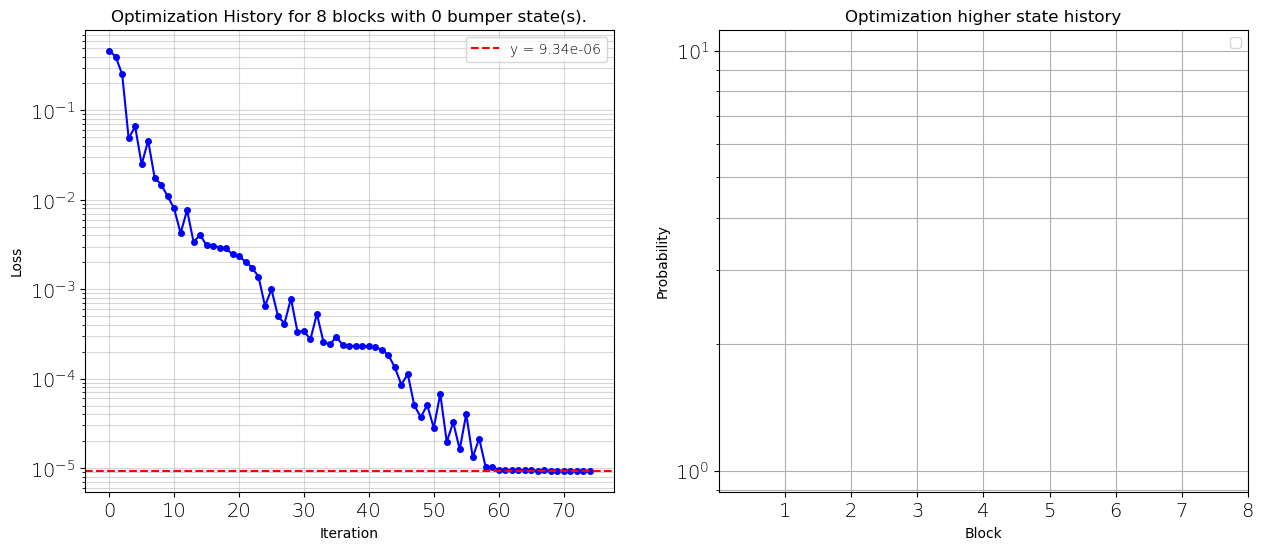

CPU times: user 1.32 s, sys: 35 ms, total: 1.35 s
Wall time: 1.32 s


Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.27701712-1.30590990e-01j -0.76347917+5.68542838e-01j
   0.00300359-7.14813173e-03j  0.00125916-2.32957304e-04j]
 [ 0.36121905+8.80736828e-01j  0.17008106+2.54683971e-01j
  -0.00127362-1.01786968e-03j  0.00352866+3.54427472e-03j]
 [-0.00352862+3.54430825e-03j  0.00127357-1.01778680e-03j
   0.17008106-2.54683942e-01j  0.36121893-8.80736768e-01j]
 [-0.00125913-2.33013183e-04j -0.00300344-7.14812055e-03j
  -0.76347923-5.68542838e-01j  0.27701706+1.30590916e-01j]]

In [266]:
# Run optimization
%time dictn = ECD_Compile(N_blocks, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=True)
dictn[1]

In [6]:
cav_unitary
# dictn[0]

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.27702459-0.13059069j -0.76350488+0.56856287j]
 [ 0.36122517+0.88074958j  0.1700831 +0.25469254j]]

In [11]:
# dict_vals = list(dictn[0].values())
# ini_guess = (tc.cat((dict_vals[1], dict_vals[2], dict_vals[3], dict_vals[4]))).numpy()
# ini_guess

# ini_guess = [-1.42912068, -0.93764388,  2.36990927, -0.14060579, -1.20470189,
#         2.12543493,  0.01142713,  1.02743363, -0.27849057,  1.12376009,
#         1.19687465, -0.04404359,  0.05902581,  1.95449544,  0.26458346,
#         0.63597662,  0.77132739, -0.47408786,  2.64695558,  0.10334972,
#        -0.44672227,  0.59760598,  0.63624819, -0.07185582, -0.8343884 ,
#        -0.29047546,  1.83506454,  0.45302586,  0.83483514, -1.0703254 ,
#         2.42048258,  0.08126191]

#  Qubit Loss Plots

In [284]:
bumper = 0
N_trunc = 2
pen = 0
Qubit_seq_loss = []
for seq_len in range(7,15):
    Qubit_seq_loss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


 ********** Optimizing Parameters for 7 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 8 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 9 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 10 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 11 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 12 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 13 blocks and 0 bumper state(s) **********

 ********** Optimizing Parameters for 14 blocks and 0 bumper state(s) **********


In [305]:
bumper = 2
N_trunc = 2
pen = 0
Qubit_seq_bloss = []
for seq_len in range(7,15):
    Qubit_seq_bloss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


 ********** Optimizing Parameters for 7 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 8 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 9 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 10 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 11 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 12 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 13 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 14 blocks and 2 bumper state(s) **********


In [306]:
bumper = 2
N_trunc = 2
pen = 1  # penalizes highest fock level
Qubit_seq_p1bloss = []
for seq_len in range(7,15):
    Qubit_seq_p1bloss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


 ********** Optimizing Parameters for 7 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 8 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 9 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 10 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 11 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 12 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 13 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 14 blocks and 2 bumper state(s) **********


In [307]:
bumper = 2
N_trunc = 2
pen = 2  # penalizes highest fock level
Qubit_seq_p2bloss = []
for seq_len in range(7,15):
    Qubit_seq_p2bloss.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False)['Infidelity'])


 ********** Optimizing Parameters for 7 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 8 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 9 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 10 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 11 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 12 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 13 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 14 blocks and 2 bumper state(s) **********


In [115]:
# Qubit_seq_loss = [7.422588055305823e-08, 4.02951769729043e-08, 5.878408870785279e-08, 4.181627843991009e-08, 6.495265125749938e-08,
#                  8.033163112486363e-08, 5.449630080534007e-08, 9.750017682108592e-08]
# Qubit_seq_bloss = [2.376323755015619e-05, 0.00010623427806422114, 9.002094157040119e-05, 4.5346801925916225e-05, 0.00010660885163815692,
#                  2.809952275129035e-05, 7.450425619026646e-05, 0.0001020229174173437]
# Qubit_seq_p1bloss = [0.016544325277209282, 0.0016050804406404495, 0.002464152639731765, 0.001102112466469407, 0.0009976333240047097,
#                      0.0021470836363732815, 0.0004913911106996238, 0.000746796082239598]
# Qubit_seq_p2bloss = [0.06874150037765503, 0.014713470824062824, 0.010987287387251854, 0.006725532468408346, 0.005286623258143663,
#                      0.005890492349863052, 0.007293791510164738, 0.006233891937881708]

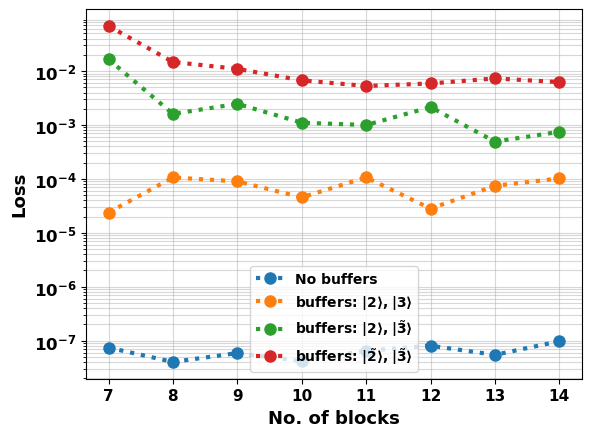

In [8]:
plt.rcParams['font.weight'] = 'bold'
plt.plot(range(7,15), Qubit_seq_loss, 'o:',label='No buffers', lw=3, markersize= 8)
plt.plot(range(7,15), Qubit_seq_bloss,'o:',label=r'buffers: $|2\rangle,|3\rangle$', lw=3, markersize= 8)
plt.plot(range(7,15), Qubit_seq_p1bloss,'o:',label=r'buffers: $|2\rangle,|\tilde{3}\rangle$', lw=3, markersize= 8)
plt.plot(range(7,15), Qubit_seq_p2bloss, 'o:',label=r'buffers: $|\tilde{2}\rangle,|\tilde{3}\rangle$', lw=3, markersize= 8)
plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.title(f'Loss function for Random dense Qubit  gate')
plt.yscale('log')
plt.ylabel('Loss', fontsize=13, fontweight='bold')
plt.xlabel('No. of blocks', fontsize=13, fontweight='bold')
plt.xticks(range(7,15), fontsize=11)
plt.yticks([1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], fontsize=12)
plt.legend()
plt.savefig('RandomQubitGate.pdf', format= 'pdf')
plt.show()

# Check for Stability of ECD parameters

In [116]:
def check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper, N_trunc, pen):
    def tc_fock(N_trunc, n):
            return tc.kron(tc.tensor(qutip.fock(2,0).full(), dtype= complex_dtype),tc.tensor(qutip.fock(N_trunc,n).full(),dtype= complex_dtype))
        
    def tc_sigmax():
        return tc.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=complex_dtype)
    
    def tc_sigmay():
        return tc.tensor([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex_dtype)
        
    
    def tc_sigmap():
        ''' torch sigmap'''
        X = tc.tensor([[0,1], [0,0]], dtype=complex_dtype)
        return X
        
    def tc_sigmam():
        ''' torch sigmam'''
        X = tc.tensor([[0,0], [1,0]], dtype=complex_dtype)
        return X
    
    def tc_displace(N, alpha):
        """
        Defines the displacement operator D(alpha) using only numpy and scipy.
        N: Hilbert space dimension
        alpha: Complex displacement amplitude
        """
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(1, N):
            a[n-1, n] = tc.sqrt(tc.tensor(n))
        adag = a.H    
        operator_exponent = alpha * adag - tc.conj(alpha) * a
        displacement_operator = tc.linalg.matrix_exp(operator_exponent)
        return displacement_operator
    
    
    def tc_idty(N):
        a = tc.zeros((N, N), dtype=complex_dtype)
        for n in range(N):
            a[n, n] = 1
        return a
        
    def ECD(beta_real, beta_imag, N_trunc):    
        return tc.kron(tc_sigmap(), tc_displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + tc.kron(tc_sigmam(), tc_displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))

    def Rot(phi, theta, N_trunc):
        sx = tc.kron(tc_sigmax(), tc_idty(N_trunc))
        sy = tc.kron(tc_sigmay(), tc_idty(N_trunc))
        idty = tc.kron(tc_idty(2), tc_idty(N_trunc))
        if theta == 0:
            return idty
        else:          
            return ((torch.cos(theta/2.0))*idty - 1j * ((torch.cos(phi) * sx) + (torch.sin(phi) * sy)) * torch.sin(theta/2.0))
    
    
    # One ECD Block
    def U_block_ECD(beta_real, beta_imag, phi, theta, N_trunc):
        return ECD(beta_real, beta_imag,  N_trunc) @ Rot(phi, theta, N_trunc) 
    
    
    def Unitary_cost(Oper1, Oper2, N_trunc):
        T_dim = N_trunc
        mat = Oper1[0:T_dim, 0:T_dim] - Oper2[0:T_dim, 0:T_dim]
        val1  = tc.sqrt(tc.abs(tc.trace(mat.H @ mat)))/tc.tensor(mat.shape[0])
        return val1    
    
    def Full_Unitary(Unitary, bumper, N_trunc):
        T_dim = bumper + N_trunc
        mat = tc.zeros([T_dim, T_dim], dtype=complex_dtype)
        for i in range(N_trunc):
            for j in range(N_trunc):
                mat[i,j] = Unitary[i,j]
        for k in range(N_trunc, T_dim):
            mat[k,k] = 1  
        return mat

    full_dim = bumper+ N_trunc
    b_state_pop ={}   
    b_state_pop1 ={}                                           # bumper state population
    for index in range(N_trunc, bumper+N_trunc):
        b_state_pop[f'{index}'] = [] 
        b_state_pop1[f'{index}'] = [] 

    U = tc.kron(tc_idty(2), tc_idty(full_dim))
    for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
        U = U_block_ECD(beta_real, beta_imag, phi, theta, full_dim) @ U

        for k in range(N_trunc, full_dim):
            fin_state = U@tc_fock(full_dim,0)
            fin_state1 = U@tc_fock(full_dim,1)
            prob = (tc.abs(tc_fock(full_dim,k).H @fin_state))**2
            prob1 = (tc.abs(tc_fock(full_dim,k).H @fin_state1))**2
            b_state_pop[f'{k}'].append(prob.detach().numpy()[0][0])
            b_state_pop1[f'{k}'].append(prob1.detach().numpy()[0][0])

    
    width = 1
    matr = np.ones([bumper,len(betas_real)])
    matr1 = np.ones([bumper,len(betas_real)])
    y = [f'{k}' for k in range(N_trunc, N_trunc+bumper) ]


    x = np.arange(1, len(betas_real)+1, 1, dtype='int')
    pop_list = []                 # contains list of population of each bumper state after every block in the sequence
    pop_list1 = []
    for i in range(bumper):
        s = i+N_trunc
        matr[i,:] = list(b_state_pop.values())[i]
        matr1[i,:] = list(b_state_pop1.values())[i]
        pop_list.append(list(b_state_pop.values())[i])
        pop_list1.append(list(b_state_pop1.values())[i])

    

    infid_list = []
    for k in range(1, bumper+1):
        T_dim = k+ N_trunc
        U = tc.kron(tc_idty(2), tc_idty(T_dim))
        for beta_real, beta_imag, phi, theta in zip(betas_real, betas_imag, phis, thetas): 
            U = U_block_ECD(beta_real, beta_imag, phi, theta, T_dim) @ U

        Oper1 = tc.kron(tc_idty(2), Full_Unitary(cav_unitary, k, N_trunc))
        Oper2 = U
        infid_list.append(Unitary_cost(Oper1, Oper2, N_trunc).numpy())

    data = np.ones([bumper,len(betas_real)])
    data1  = np.ones([bumper,len(betas_real)])
    for i in range(bumper):
        p = bumper-(i+1)
        data[p,:] = matr[i,:]
        data1[p,:] = matr1[i,:]

    return {'Block_Pop': pop_list, 'Bump_Infid': infid_list, 'data': data, 'data1': data1}



## Qubit (N_trunc = 2), penalize No Fock state (pen=0), sweep over 1-10 bumper states

In [18]:
dictlist19_0 = [] 
N_trunc = 2
seq_len = 20
thres = 1e-7
pen = 0
for bumper in range(1,11):
    %time dictlist19_0.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False))


 ********** Optimizing Parameters for 20 blocks and 1 bumper state(s) **********
CPU times: user 3.89 s, sys: 57.8 ms, total: 3.95 s
Wall time: 3.89 s

 ********** Optimizing Parameters for 20 blocks and 2 bumper state(s) **********
CPU times: user 3.42 s, sys: 62.1 ms, total: 3.48 s
Wall time: 3.43 s

 ********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********
CPU times: user 4.64 s, sys: 58.1 ms, total: 4.7 s
Wall time: 4.64 s

 ********** Optimizing Parameters for 20 blocks and 4 bumper state(s) **********
CPU times: user 5.2 s, sys: 54.1 ms, total: 5.25 s
Wall time: 5.19 s

 ********** Optimizing Parameters for 20 blocks and 5 bumper state(s) **********
CPU times: user 14.5 s, sys: 64.1 ms, total: 14.6 s
Wall time: 14.6 s

 ********** Optimizing Parameters for 20 blocks and 6 bumper state(s) **********
CPU times: user 14.5 s, sys: 76.1 ms, total: 14.6 s
Wall time: 14.5 s

 ********** Optimizing Parameters for 20 blocks and 7 bumper state(s) **********
CPU time

In [114]:
# dictlist19_0 = [{'Infidelity': 2.181143281632103e-05,
#   'Betas_real': tc.tensor([-0.6600, -0.4378, -0.9487, -0.3370, -0.3257, -0.5740,  1.3731,  1.2414,
#            0.1538, -0.0182,  0.1552,  0.4489, -1.3078,  0.3129,  0.6024,  0.9656,
#            0.8533,  0.3463,  0.5110,  1.6813,  0.7259, -3.6426]),
#   'Betas_imag': tc.tensor([-1.7455, -2.1113, -1.0256,  0.3195,  1.2659, -0.1461, -2.3082,  1.4527,
#            0.6979,  1.1319,  0.3812,  0.1077, -1.6044, -0.4740, -2.1445, -0.1815,
#            0.3246, -0.3139,  1.5211,  2.3817,  1.9103,  0.2115]),
#   'Phis': tc.tensor([ 1.3091,  0.7278, -1.0818,  0.7552,  0.3239, -0.7103,  1.3362,  0.5409,
#           -1.0703,  2.0741,  1.1798, -0.0165, -0.6895, -0.0459, -0.8654,  0.6307,
#           -0.5564,  0.0861,  1.2464,  0.8838,  0.1265, -1.3310]),
#   'Thetas': tc.tensor([-0.9716, -0.3817, -1.4137,  0.4774, -0.3129,  0.8294,  1.2142,  0.5015,
#            2.8427,  0.9266,  0.8893, -1.3667, -1.7275, -0.3049,  1.2490, -0.1864,
#           -2.6795, -0.3926,  0.0430,  0.5525,  1.0414, -0.9572])},
#  {'Infidelity': 3.8689406210323796e-05,
#   'Betas_real': tc.tensor([-0.5338, -0.6749, -0.6453, -0.4008, -0.0171, -0.3560,  1.1152,  1.2266,
#           -0.4853,  0.0589,  0.0411,  0.7193, -1.1839,  0.6667,  0.4196,  1.2446,
#            0.8657,  0.1403,  0.6918,  1.6169,  0.9073, -3.8616]),
#   'Betas_imag': tc.tensor([-2.6180e+00, -1.6189e+00, -1.1112e+00,  4.9706e-01,  1.0725e+00,
#            2.4414e-03, -2.1459e+00,  1.4164e+00,  1.0320e+00,  7.8346e-01,
#            5.2642e-01,  2.5441e-01, -1.7846e+00, -5.2127e-01, -1.9725e+00,
#           -4.3296e-01,  1.1897e-01, -3.3608e-01,  1.7638e+00,  2.2536e+00,
#            2.4563e+00,  1.7631e-01]),
#   'Phis': tc.tensor([ 1.1590,  0.8811, -1.1341,  0.7678,  0.1134, -0.7741,  1.2604,  0.5232,
#           -0.4232,  1.9333,  0.9388,  0.0033, -1.2046,  0.0066, -1.0437,  0.1891,
#           -0.4435, -0.4194,  1.2037,  0.8593,  0.1116, -1.0961]),
#   'Thetas': tc.tensor([-0.8618, -1.3370, -0.9624, -0.0780, -0.3443,  0.6373,  1.1343,  0.9328,
#            3.0874,  1.1119,  0.8596, -1.0731, -1.6388, -0.8796,  1.0759, -0.6550,
#           -2.9891, -0.8030, -0.2885,  0.5148,  0.6866, -0.7387])},
#  {'Infidelity': 4.508512938627973e-05,
#   'Betas_real': tc.tensor([ 0.0185, -1.0610, -0.6867, -0.3137, -0.3052, -0.0902,  0.4601,  1.4031,
#           -0.2946, -0.2594,  0.0750,  1.0020, -1.3366,  0.1280,  0.9485,  1.0486,
#            0.8412,  0.4083,  0.6475,  1.7247,  0.5415, -3.9579]),
#   'Betas_imag': tc.tensor([-2.1803, -1.7176, -1.1648,  0.6008,  1.0292, -0.0706, -2.1282,  1.4452,
#            1.4195,  0.4818,  0.2410,  0.2802, -1.2647, -0.4507, -1.8285, -0.1238,
#            0.6639, -0.6772,  1.4983,  2.3225,  1.9238,  0.2171]),
#   'Phis': tc.tensor([ 1.4078,  1.0023, -0.9579,  0.7505,  0.2786, -0.6834,  0.8430,  0.3925,
#           -0.7216,  2.1404,  1.3869,  0.1766, -0.9248,  0.1385, -0.8199,  0.1934,
#           -0.7417, -0.2036,  1.1927,  0.5490,  0.2193, -0.9576]),
#   'Thetas': tc.tensor([-1.0763, -0.6969, -1.1651,  0.1846, -0.3027,  0.8194,  1.2899,  1.1267,
#            2.9432,  1.0595,  0.7629, -1.2300, -1.3990,  0.1123,  1.2319, -0.6143,
#           -2.6697, -0.6084, -0.2644,  0.4249,  1.4478, -1.5285])},
#  {'Infidelity': 0.00010002058115787804,
#   'Betas_real': tc.tensor([-0.2006, -0.5290, -0.6702, -0.5165, -0.3736, -0.3934,  0.7998,  1.5993,
#           -0.3971,  0.2944, -0.3061,  1.0083, -0.7060,  0.4861,  0.7768,  0.9541,
#            0.9860,  0.1847,  0.3812,  1.4536,  0.9209, -3.5582]),
#   'Betas_imag': tc.tensor([-1.8095, -1.8247, -1.2904,  1.0130,  0.4792, -0.1420, -2.2262,  1.7329,
#            1.4070,  0.7559,  1.0146,  0.0759, -1.2158, -0.6712, -2.4062, -0.1349,
#            0.4626, -0.5260,  1.5758,  2.1592,  2.0168,  0.2872]),
#   'Phis': tc.tensor([ 1.5406,  0.9485, -1.2694,  0.8376,  0.4192, -0.7409,  1.2346,  0.5126,
#           -0.7696,  2.0245,  0.8014, -0.1890, -0.3409,  0.0526, -1.1889,  0.4012,
#           -0.6788, -0.2831,  1.1813,  1.3675,  0.5065, -1.1593]),
#   'Thetas': tc.tensor([-1.0265, -1.0259, -1.3478,  0.4213,  0.1563,  0.6712,  1.2794,  0.2868,
#            3.0194,  1.2408,  1.0268, -0.9941, -1.6433, -0.6175,  1.6155, -0.6340,
#           -2.6917, -0.6765, -0.1990,  0.5098,  1.4793, -1.5634])},
#  {'Infidelity': 0.0001085132680600509,
#   'Betas_real': tc.tensor([-0.6280, -0.4534, -0.7935, -0.2548, -0.2560, -0.0961,  0.9766,  1.4148,
#           -0.1298, -0.0481, -0.0713,  0.7806, -0.9979,  0.7118, -0.0372,  1.2958,
#            0.9742,  0.6662,  0.2710,  1.7076,  0.9137, -3.7167]),
#   'Betas_imag': tc.tensor([-1.8686, -1.8484, -1.1815,  0.5098,  1.1856, -0.0022, -1.8908,  1.9592,
#            0.9973,  1.0187,  0.8828,  0.4355, -1.4270, -0.7300, -1.9771, -0.1468,
#            0.2727, -0.2284,  1.5278,  2.1127,  1.6138, -0.1114]),
#   'Phis': tc.tensor([ 1.4571,  0.9658, -1.2877,  0.7273,  0.3137, -0.6915,  1.8364,  0.4497,
#           -1.2199,  2.1292,  1.3145,  0.0247, -0.8066, -0.0939, -0.6683,  0.7932,
#           -0.4783, -0.3356,  1.1177,  1.0714, -0.2550, -1.3806]),
#   'Thetas': tc.tensor([-1.0684, -1.0993, -1.4005,  0.4801, -0.0883,  1.1511,  1.7674,  0.7199,
#            2.9338,  1.2402,  1.1304, -1.7830, -2.0346, -0.7290,  0.8767, -0.3947,
#           -3.0026, -0.3385, -0.5353,  0.7513,  0.9137, -0.9070])},
#  {'Infidelity': 0.00022018971503712237,
#   'Betas_real': tc.tensor([-0.4041, -0.5605, -1.1198, -0.2638, -0.6227, -0.5200,  1.0302,  1.6339,
#           -0.2726,  0.3507, -0.0789,  0.5580, -0.4940,  0.6106,  0.3495,  1.5423,
#            0.8427,  0.1422,  0.6644,  1.6788,  0.9572, -3.2348]),
#   'Betas_imag': tc.tensor([-2.3860, -2.0094, -1.4819,  0.4868,  1.0922, -0.3115, -1.8614,  1.0705,
#            1.5618,  0.7205,  0.5276,  0.2915, -1.7642, -0.8199, -2.0858,  0.4008,
#            0.0735, -0.3132,  1.5908,  1.9186,  1.5605,  0.0894]),
#   'Phis': tc.tensor([ 1.8852,  1.0781, -1.5224,  0.8881,  0.3726, -0.5879,  1.3976,  0.1789,
#           -0.9856,  2.0311,  1.4662,  0.0392, -1.2408,  0.1333, -0.7713,  0.4707,
#           -0.8863, -0.2117,  1.2464,  0.9384,  0.3218, -1.3385]),
#   'Thetas': tc.tensor([-0.8844, -1.1170, -1.6375, -0.5234, -0.0295,  1.1715,  1.7218,  0.0441,
#            3.1757,  1.3220,  0.8942, -1.1325, -1.7614, -0.5193,  0.9397, -0.5692,
#           -2.7885, -1.1152,  0.0164,  1.1364,  1.0282, -1.5113])},
#  {'Infidelity': 0.00034939631586894393,
#   'Betas_real': tc.tensor([-0.7394, -0.7182, -0.8325, -0.4314, -0.8041, -0.7968,  1.2787,  0.9038,
#           -0.4361,  0.0047, -0.1910,  0.6048, -1.1870,  0.0841, -0.0239,  0.9934,
#            0.8317,  0.3960,  0.1977,  1.4878,  0.9141, -3.1823]),
#   'Betas_imag': tc.tensor([-2.0773, -1.7354, -1.4942,  0.8536,  1.3443, -0.7991, -1.7617,  1.9576,
#            0.8227,  0.8546,  0.5522,  0.5969, -1.2157, -0.5621, -2.2366, -0.4182,
#            0.4077, -0.4393,  1.6870,  2.1353,  1.8525,  0.1793]),
#   'Phis': tc.tensor([ 1.7866,  0.5674, -1.6137,  0.3882,  0.5251, -0.4570,  1.0729,  0.6151,
#           -0.8753,  1.7927,  1.5419, -0.1991, -1.4056,  0.0380, -0.9373,  0.7686,
#           -0.7300,  0.0391,  1.1250,  0.6752,  0.0547, -1.3478]),
#   'Thetas': tc.tensor([-1.0260, -0.9338, -1.2695,  0.4476, -0.1795,  1.4607,  1.0914,  0.5059,
#            3.5454,  1.2519,  1.0194, -0.9538, -1.6340,  0.0078,  0.6593, -0.9204,
#           -2.6119, -0.6716,  0.2288,  0.9320,  0.7891, -0.7410])},
#  {'Infidelity': 0.00038468887214548886,
#   'Betas_real': tc.tensor([-0.8442, -0.6652, -1.5524,  0.4437, -0.1321, -0.5054,  1.3048,  1.8011,
#           -0.5035,  0.3914, -0.0399,  0.3839, -1.5154,  0.1030,  0.8893,  1.1614,
#            0.7716,  0.0676,  0.0445,  1.3164,  1.3015, -3.3519]),
#   'Betas_imag': tc.tensor([-1.8720, -1.6600, -1.3816,  0.5963,  1.3883, -0.0218, -1.7004,  2.3449,
#            0.3858,  0.7919,  0.9243, -0.3041, -0.9420, -0.4156, -2.3219, -0.4224,
#            0.2695, -0.0360,  2.0208,  2.5675,  1.8599,  0.5705]),
#   'Phis': tc.tensor([ 1.6855,  0.4266, -1.6826,  0.4160, -0.1175, -0.5386,  1.0437,  0.9440,
#           -0.6633,  1.3822,  1.0793,  0.1660, -1.0708,  0.2612, -0.3719,  0.5439,
#           -0.8435, -0.2739,  1.5282,  0.2942,  0.2742, -0.4240]),
#   'Thetas': tc.tensor([-1.1285, -0.4684, -1.3439,  0.4529, -0.5667,  1.1724,  1.3617,  0.7893,
#            3.0110,  1.0565,  1.4565, -1.6590, -2.1439, -0.6908,  1.1819,  0.1718,
#           -2.5932, -0.6438, -0.7415,  1.4781,  1.1729, -1.4076])},
#  {'Infidelity': 0.0003763099084608257,
#   'Betas_real': tc.tensor([-6.3595e-01, -8.0309e-01, -1.2264e+00,  3.3628e-02,  1.0817e-03,
#           -3.8913e-01,  1.2276e+00,  1.2431e+00, -3.2567e-02,  4.5551e-01,
#            7.2705e-01,  9.8984e-01, -1.5491e+00,  2.0944e-01, -4.7415e-01,
#            6.1806e-01,  1.0257e+00,  4.4166e-01,  9.3474e-01,  1.9398e+00,
#            1.2028e+00, -3.0627e+00]),
#   'Betas_imag': tc.tensor([-2.3142, -2.2539, -0.6811,  0.9722,  1.5643,  0.0966, -1.7784,  1.9074,
#            0.9621,  0.6890,  1.0087,  1.0926, -1.0260, -0.2903, -2.1733,  0.0800,
#            0.1445,  0.0081,  1.7104,  2.0217,  1.9254,  0.1155]),
#   'Phis': tc.tensor([ 1.5022,  0.4943, -1.4961,  0.9082,  0.1256, -0.9945,  1.4399,  0.7302,
#           -1.3393,  1.3541,  0.9064, -0.1654, -0.9680, -0.1092, -1.4154,  0.6494,
#           -0.7461, -0.7914,  1.5469,  0.9512, -0.0730, -1.2074]),
#   'Thetas': tc.tensor([-1.1114, -0.8530, -1.1614,  0.1846, -0.3961,  1.6254,  1.7785,  0.9178,
#            2.2681,  1.3572,  1.3326, -1.0674, -1.1398, -0.1639,  0.3489, -1.8362,
#           -2.1314, -0.7558,  0.8764,  1.7184,  1.2439, -0.8853])},
#  {'Infidelity': 0.001080686110071838,
#   'Betas_real': tc.tensor([-0.8288, -0.8002, -0.5671,  0.2377, -1.1677, -0.2948,  0.6328,  1.1784,
#            0.1722,  0.2972,  0.2081,  0.0304, -0.5485,  0.1149, -0.8746,  0.3553,
#            0.6365, -0.1833,  0.1371,  1.3264,  1.0838, -3.8390]),
#   'Betas_imag': tc.tensor([-1.7402, -1.5320, -0.3284,  0.2459,  1.4262, -0.2677, -1.6540,  1.9633,
#            0.7531,  1.1454,  0.8318, -0.3529, -1.7983, -1.2550, -2.9809,  0.0526,
#            0.4874, -0.3539,  1.2051,  2.4245,  1.8699,  0.0083]),
#   'Phis': tc.tensor([ 1.0133,  1.5986, -1.8645,  0.8851, -0.2548, -1.3166,  2.1561,  0.7366,
#           -0.7001,  2.0958,  1.5743, -0.1395,  0.1547, -0.0744, -0.4441,  1.2206,
#           -1.0466, -0.4941,  0.8345,  0.5137, -0.1098, -1.3765]),
#   'Thetas': tc.tensor([-0.8883,  0.3272, -0.9179,  0.6747, -0.5574,  1.5923,  1.6217,  1.9856,
#            4.5189,  1.4294,  1.0926, -1.5310, -1.5614,  0.5143,  1.3190, -0.5956,
#           -3.1519, -0.0302, -0.5252,  1.6566,  1.7642,  0.2359])}]

In [17]:
dictlist19_0_out = []
# List of dictionaries of the form  {'Block_Pop': pop_list, 'Bump_Infid': infid_list }
pen = 0
for k in range(len(dictlist19_0)):
    betas_real = dictlist19_0[k]['Betas_real']
    betas_imag = dictlist19_0[k]['Betas_imag']
    phis = dictlist19_0[k]['Phis']
    thetas = dictlist19_0[k]['Thetas']
    bumper_check = 13
    dictlist19_0_out .append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

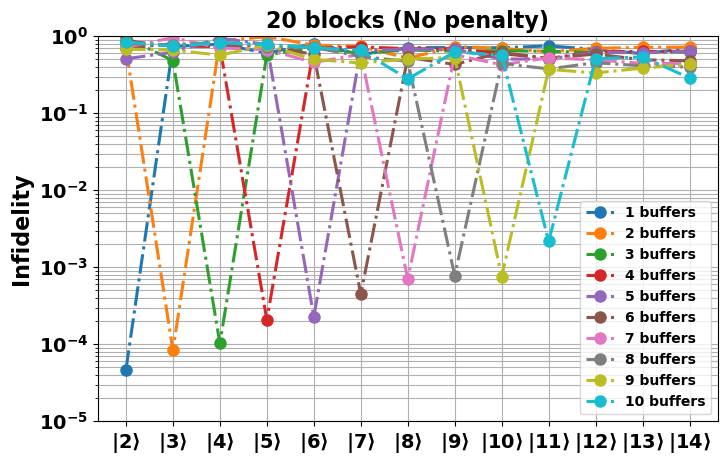

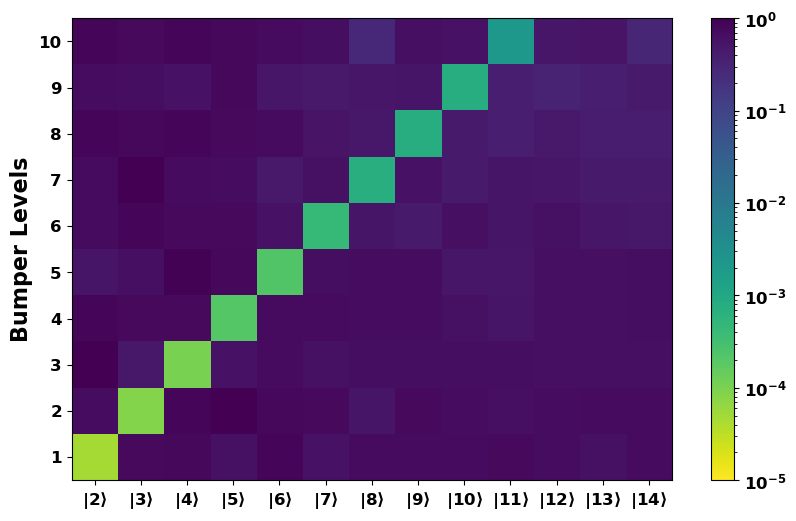

In [35]:
vmin0 = 1e-5
vmax0 =1

plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_0_out)):
    plt.plot(x2, dictlist19_0_out[k]['Bump_Infid'],  'o-.', markersize=8, lw = 2.2, label=f'{k+1} buffers')
plt.title('20 blocks (No penalty)', fontsize =16, fontweight='bold')
plt.ylabel('Infidelity', fontsize=16, fontweight='bold')
plt.ylim(vmin0, vmax0)
plt.yscale('log')
plt.xticks(x2)
plt.legend()
plt.xticks(x2, [rf"$|{i}\rangle$" for i in x2])
# plt.xlabel('Fock State', fontsize=16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QubitGate_loss0.pdf', format = 'pdf', bbox_inches='tight')
plt.show()




L = len(dictlist19_0_out)
data = np.zeros((len(dictlist19_0_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_0_out[i]['Bump_Infid']


plt.figure(figsize=(10,6))
plt.rcParams["font.weight"] = "bold"
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log', vmin = vmin0, vmax=vmax0)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(x3, [rf"$|{i}\rangle$" for i in x2])
plt.yticks(x4, [L-i for i in range(L)])
# plt.xlabel('Fock States', fontsize=16)
plt.ylabel('Bumper Levels', fontsize=16, fontweight='bold')
# plt.savefig('New_QubitGate_loss0.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

## Qubit (N_trunc = 2), penalize largest Fock state (pen=1), sweep over 1-10 bumper states

In [43]:
dictlist19_0b = [] 
N_trunc = 2
seq_len = 20
thres = 1e-7
pen = 1
for bumper in range(1,11):
    dictlist19_0b.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol,pen, thres, Add_block = False, Disp=False))


 ********** Optimizing Parameters for 20 blocks and 1 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 4 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 5 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 6 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 7 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 8 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 9 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 10 bumper state(s) **********


In [19]:
# dictlist19_0b = [{'Infidelity': 0.00017690370441414416,
#   'Betas_real': tc.tensor([ 0.1388, -0.2042,  0.1228,  0.4761, -0.0145,  0.1020,  0.1669,  1.7269,
#            0.9385,  1.2077,  0.6949, -0.5492, -0.0109, -0.2870, -0.7599,  1.2954,
#            0.4436, -0.1780,  0.3754,  0.1466]),
#   'Betas_imag': tc.tensor([ 2.9349, -4.1803, -0.2443, -0.1205, -0.2114,  0.6023,  0.2861, -0.6871,
#           -1.0865,  1.7086,  1.7555,  0.3296,  0.9140,  0.8538, -1.5138,  0.2697,
#           -0.1316,  0.6791, -0.4560,  0.1350]),
#   'Phis': tc.tensor([ 1.5326,  1.8537,  1.6921, -0.2172,  1.1556,  0.5649, -1.9906,  0.3958,
#           -0.4028, -0.6439,  0.8341,  0.9229, -0.7750,  1.8324,  1.5005,  0.2404,
#           -0.4685, -0.0615, -1.6104, -0.9779]),
#   'Thetas': tc.tensor([-1.3545e-03, -9.1668e-02,  1.7313e+00,  8.7750e-01, -5.8093e-01,
#           -1.7672e+00, -7.6689e-01,  4.0876e-01, -5.8053e-01, -3.6248e-01,
#           -6.6508e-01,  9.2957e-01,  1.1449e+00,  8.5078e-01,  7.2146e-01,
#           -6.9659e-01,  1.4343e+00,  1.4216e-01, -2.6155e+00, -5.0763e-01])},
#  {'Infidelity': 0.00039015215588733554,
#   'Betas_real': tc.tensor([ 0.0123, -0.5346, -0.3874, -0.5802, -0.3556, -0.0426,  0.5852,  0.9048,
#            0.0814,  0.8384, -0.4296,  0.0529, -0.4909,  0.7792,  0.4116,  0.6150,
#            0.6545,  0.5107,  0.7473,  0.8664]),
#   'Betas_imag': tc.tensor([ 2.2930, -5.0866, -2.5989, -1.4885, -1.5752, -0.3569, -0.0375, -0.1466,
#           -1.2737,  0.8493,  1.4640,  1.2532,  0.5405, -0.0279, -1.0347, -0.3504,
#           -0.7483, -0.4173,  0.3715,  0.4423]),
#   'Phis': tc.tensor([ 1.7987,  1.9062,  1.1270, -0.6203,  2.1425,  1.8674, -1.5617,  0.0753,
#            1.0173, -1.1677,  1.1487,  1.3551, -1.7064,  1.8928,  0.8413, -0.4954,
#           -0.5027, -0.8519, -1.2851,  1.5000]),
#   'Thetas': tc.tensor([-0.0276,  2.8804,  0.3240,  1.2677,  0.1790, -1.5134, -0.6519, -1.1320,
#           -1.2583,  0.7104,  0.3091,  0.6833,  1.5144, -0.6223,  0.9291, -1.3896,
#           -0.9898,  0.3026,  0.0171, -0.1017])},
#  {'Infidelity': 0.0009525290224701166,
#   'Betas_real': tc.tensor([-0.0398, -1.2273, -0.6151, -0.1217, -0.3310,  0.0581,  1.2674,  0.4159,
#           -0.3395, -0.0052,  0.3334, -0.0260, -0.5754,  0.6801,  0.6318,  1.2196,
#            0.2398, -0.4928,  0.2936,  0.8263]),
#   'Betas_imag': tc.tensor([ 0.5446, -4.0799, -3.8152, -1.1428, -0.4397, -0.5180,  0.7362,  0.2122,
#           -1.0445,  0.8814,  0.7721,  0.4152,  0.8092,  0.3746, -1.9748, -0.6863,
#           -0.5848,  0.5899,  0.2566, -0.0911]),
#   'Phis': tc.tensor([ 0.9512,  1.8011,  2.3605, -0.2566,  1.4173,  0.9139, -2.3945,  1.8049,
#            0.7088, -0.9328,  1.3971, -0.1092, -0.7874,  1.7579,  2.3046,  0.0726,
#           -1.1550, -0.2242, -1.9582,  0.4588]),
#   'Thetas': tc.tensor([-3.1593, -0.0213,  0.5555,  3.1297, -1.0543, -1.3405, -1.0417, -0.3622,
#           -0.6608,  1.1762, -0.3159,  0.6157,  1.1822, -0.4467,  0.3990, -0.5590,
#            0.2640,  1.4635, -1.4211, -0.9893])},
#  {'Infidelity': 0.0012929807417094707,
#   'Betas_real': tc.tensor([ 0.4197, -1.8693, -1.3278, -0.0897, -0.9643, -0.8504,  1.0020,  0.7922,
#           -1.1927,  0.1232,  0.8553,  1.5706,  0.1579,  1.2640,  0.1326,  1.1719,
#            0.2958,  0.0527,  0.5527,  1.0760]),
#   'Betas_imag': tc.tensor([ 0.8578, -3.3499, -3.3998, -0.2430, -1.0292, -0.4394,  0.8900, -0.2914,
#           -1.3916,  1.0811,  1.0137,  1.1833,  0.6651, -0.1993, -1.9341, -0.4079,
#           -0.6592,  0.9491,  1.0672,  0.4849]),
#   'Phis': tc.tensor([ 2.4398,  3.1237,  2.2599,  0.1247,  1.7576,  1.6757, -0.4850,  1.7301,
#           -1.1884, -1.4166,  0.9123,  0.4031, -1.4760,  1.1693,  1.3930, -1.0851,
#           -0.5840,  0.2735, -0.1591,  1.3132]),
#   'Thetas': tc.tensor([-3.1500,  0.0454,  0.0459,  0.9232, -0.5596, -0.7241, -1.3695, -0.3264,
#           -0.3037, -0.6438, -0.4098,  0.7322,  1.6338, -0.9483,  1.8442, -0.3803,
#            1.4285,  1.2956, -0.1585, -2.2388])},
#  {'Infidelity': 0.0006208464619703591,
#   'Betas_real': tc.tensor([-0.5044, -1.0678, -0.6322, -0.1375,  0.1378, -1.0392,  0.1158,  0.6322,
#           -0.4840,  0.6019, -0.1237,  0.2091, -0.2831,  0.7683,  0.2590,  0.8425,
#            0.4991,  0.1416,  0.8153,  1.1470]),
#   'Betas_imag': tc.tensor([-0.3947, -1.6688, -1.5618, -0.5944, -0.8261, -0.2430,  0.3084, -0.3348,
#           -1.6377,  1.2250,  1.5528,  0.2752,  0.8103,  0.0969, -0.6269,  0.0638,
#           -1.0581,  0.3753,  0.1677, -0.9245]),
#   'Phis': tc.tensor([ 1.8406,  2.1653,  2.2128, -0.7870,  1.2736,  1.1184, -1.4839, -0.0036,
#           -0.3295, -0.5025,  1.3275,  0.0591, -1.6101,  1.3531,  0.2558, -0.2459,
#            0.0856,  0.7559, -1.0815,  1.0199]),
#   'Thetas': tc.tensor([-1.2736e+00, -7.4645e-02, -1.5503e-04,  1.1063e+00,  3.9423e-02,
#           -8.5025e-01, -1.5760e+00, -1.1664e+00, -1.3161e+00, -7.5087e-01,
#           -8.4064e-02,  1.4618e+00,  2.0435e+00, -8.8348e-01,  7.3148e-01,
#           -2.4186e+00,  1.1150e-01,  7.2028e-01, -7.0839e-01, -3.0175e-01])},
#  {'Infidelity': 0.0005237055011093616,
#   'Betas_real': tc.tensor([ 0.0106, -0.7953,  0.2354, -0.5585, -0.4465, -0.4576,  0.1891,  0.5260,
#           -0.8151, -0.5084,  0.0252,  0.2926, -0.6905,  0.2646,  0.4301,  0.6911,
#            0.3929, -0.6764,  0.2412,  0.8827]),
#   'Betas_imag': tc.tensor([-0.3764, -1.2313, -0.9381, -0.6968,  0.0250,  1.3441,  0.6335, -0.3215,
#           -1.1179,  0.6983,  0.7093, -0.0202,  0.2672,  0.0875, -0.4407, -0.6044,
#           -2.3865,  0.3816,  0.4161, -0.6700]),
#   'Phis': tc.tensor([ 1.8095,  2.5789,  1.1538,  1.1081,  1.4364,  0.1975, -0.4265,  1.1674,
#            1.6729, -0.9616, -0.6287,  1.1465, -1.1157,  1.2279,  0.6039, -1.3469,
#           -0.3099, -1.1511, -1.8348,  0.8363]),
#   'Thetas': tc.tensor([-0.1758, -0.3128,  0.3484,  0.9110,  1.4146, -0.1831, -0.2489, -0.8964,
#           -1.2892,  1.2889, -0.5254,  0.8040,  2.0993, -1.2614,  0.9332, -2.0498,
#           -0.0818,  1.6454, -1.6107, -1.9681])},
#  {'Infidelity': 0.0008807653211988509,
#   'Betas_real': tc.tensor([ 0.0963, -1.5446, -0.6386, -0.3631, -0.3869, -0.0360, -0.0345,  0.7965,
#           -0.8614,  0.1864,  0.8273,  0.0606, -0.6734,  0.1124,  0.3033,  0.8759,
#            0.2916,  0.0483,  0.6103,  0.5226]),
#   'Betas_imag': tc.tensor([-0.9898, -1.8958, -1.2956, -1.4952, -0.5853,  0.4334,  0.8393,  0.4250,
#           -1.6076,  1.1783,  1.1021,  0.7075,  0.4144,  0.1186, -0.4068, -0.5679,
#           -1.9326,  0.5457,  0.0390, -1.2034]),
#   'Phis': tc.tensor([ 1.2548e+00,  2.2888e+00,  1.7299e+00,  2.1403e-03,  1.3484e+00,
#            3.2033e-01, -1.5890e+00,  7.0571e-01,  7.5970e-01, -1.4630e+00,
#            9.9031e-01,  7.6363e-01, -8.3447e-01,  1.8338e+00,  8.8910e-01,
#           -8.5167e-01, -6.0628e-01,  2.8896e-01, -1.4418e+00,  1.0536e+00]),
#   'Thetas': tc.tensor([-0.1233,  0.0169, -0.1233,  0.5329,  0.0907, -1.4795, -1.7996,  0.0605,
#           -0.7739,  1.3844, -0.0105,  1.0133,  1.4030, -0.5849,  0.2472, -1.8366,
#           -0.0455,  0.5461, -0.3988, -0.3800])},
#  {'Infidelity': 0.00047322738100774586,
#   'Betas_real': tc.tensor([ 0.2240, -1.5622, -0.7757, -0.1083,  0.0574, -0.4933,  0.0831,  0.7936,
#            0.5231,  0.2794, -0.3122,  0.3158, -0.7385,  0.6513,  0.5624,  0.9565,
#           -0.0146, -0.2967,  0.4916,  0.9122]),
#   'Betas_imag': tc.tensor([-0.3253, -2.0940, -1.3202, -1.4048, -0.8077,  0.5621,  0.7648,  0.2243,
#           -1.4391,  0.3105,  0.2785,  0.4484,  0.4875,  0.0960, -0.5827, -0.1745,
#           -1.6750,  0.6951,  0.1768, -0.7964]),
#   'Phis': tc.tensor([ 1.4613,  1.8173,  1.2804,  0.5761,  1.2612,  0.9865, -0.4271,  0.5014,
#           -0.0212, -0.5870,  0.6743, -0.0793, -0.6694,  1.7731,  1.1014, -0.9212,
#           -1.0210, -0.3687, -1.8713,  0.5124]),
#   'Thetas': tc.tensor([-5.5858e-02, -6.9782e-01, -1.1879e-03,  1.0414e+00,  2.3610e-02,
#           -3.5376e-01, -9.0929e-01, -2.3496e-01, -5.3860e-01, -5.7128e-01,
#           -4.8673e-01,  1.7612e+00,  9.5357e-01, -8.7797e-01,  7.5036e-01,
#           -1.8171e+00, -1.0905e-01,  1.0624e+00, -1.1165e+00, -1.2832e+00])},
#  {'Infidelity': 0.0002736392489168793,
#   'Betas_real': tc.tensor([ 0.2238, -1.6590, -0.0155, -0.6403, -0.2720, -0.1242,  0.2060,  0.8262,
#           -0.4757,  0.3519,  0.1843,  0.5429, -0.2329,  0.6575,  0.0236,  1.6299,
#            1.0057, -0.2133,  0.4285,  1.8545]),
#   'Betas_imag': tc.tensor([-1.0932, -1.6525, -0.6025, -1.3348, -0.8099,  0.4737,  0.4348, -0.1705,
#           -1.6760,  0.9903,  1.3981,  0.1578,  0.6994, -0.0161, -0.4804, -0.8281,
#           -1.9946,  0.4306,  0.3426, -0.8008]),
#   'Phis': tc.tensor([ 1.4884,  2.2576,  1.2068,  0.0424,  1.2810,  0.5331, -0.9721,  0.5436,
#            0.4279, -0.7652,  1.1003,  0.1799, -0.8132,  1.9967,  0.8932, -0.4690,
#           -0.9579,  0.1180, -1.0420,  0.6172]),
#   'Thetas': tc.tensor([-0.0082, -0.0062, -0.6957,  0.6505,  0.3392, -1.4016, -1.5026, -0.7086,
#           -0.8532, -0.0792,  0.0555,  1.1713,  1.3636, -1.2382,  0.9388, -1.6094,
#            0.0033,  0.5603, -0.4066, -0.4019])},
#  {'Infidelity': 0.0008605329785495996,
#   'Betas_real': tc.tensor([ 0.7463, -1.3887, -0.4003, -0.1453, -0.3607, -0.9098,  1.1153,  1.0849,
#           -0.4721, -0.1208, -0.0605,  0.8662, -0.1932,  0.4797,  1.4440,  1.8438,
#            0.5033,  0.3244,  0.4819,  1.6412]),
#   'Betas_imag': tc.tensor([-1.1711, -2.5575,  0.1673, -1.6505, -0.8517,  0.5113,  0.5044,  0.2682,
#           -1.4240,  0.7669,  1.2162,  0.3428,  0.7794,  0.0310, -1.5403, -1.3870,
#           -1.4628,  0.3078,  0.2054,  0.1476]),
#   'Phis': tc.tensor([ 1.5695,  2.1047,  2.1500,  0.8155,  1.4070,  0.4106, -0.2741,  0.5037,
#            0.3153, -0.8066,  1.5367,  0.3611, -1.6945,  2.6088,  1.1005,  0.0212,
#           -0.5277,  0.2378, -1.1706,  0.5973]),
#   'Thetas': tc.tensor([-0.0365, -0.0188,  0.9205,  1.8550,  0.1802, -1.2080, -1.0752,  0.1441,
#           -1.8915,  0.7083,  0.2243,  0.1518,  1.6498, -1.0820,  0.7697, -0.1369,
#           -0.2631,  0.6801,  0.1333, -0.6769])}]

In [27]:
dictlist19_0b_out = []         # List of dictionaries of tge form  {'Block_Pop': pop_list, 'Bump_Infid': infid_list }
pen = 1 
for k in range(len(dictlist19_0b)):
    betas_real = dictlist19_0b[k]['Betas_real']
    betas_imag = dictlist19_0b[k]['Betas_imag']
    phis = dictlist19_0b[k]['Phis']
    thetas = dictlist19_0b[k]['Thetas']
    bumper_check = 13
    dictlist19_0b_out .append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

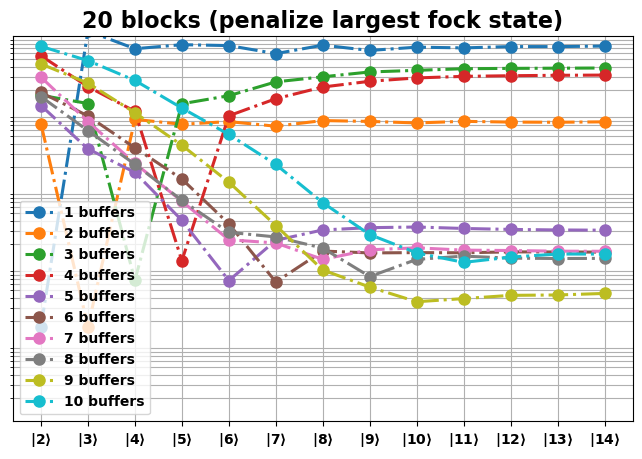

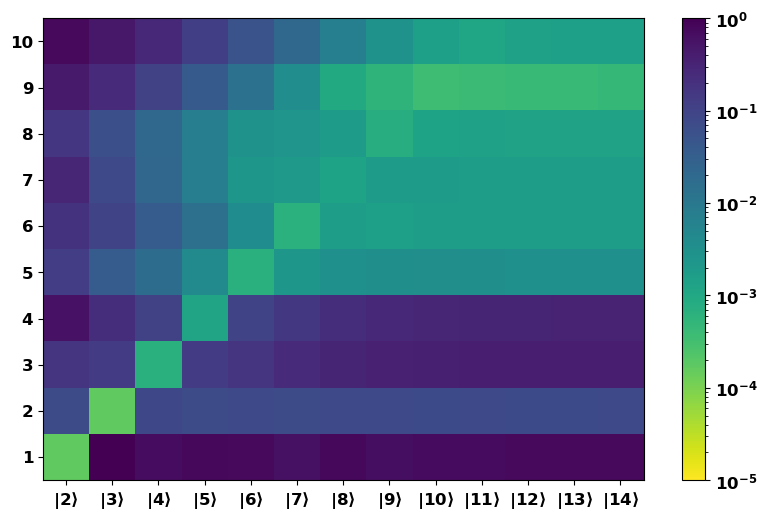

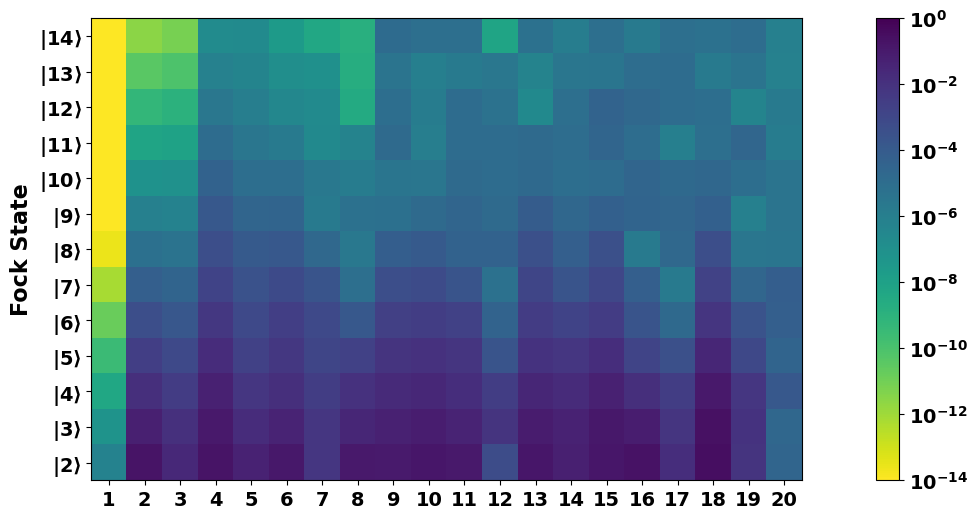

In [62]:
vmin0 = 1e-5
vmax0 =1

plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_0b_out)):
    plt.plot(x2, dictlist19_0b_out[k]['Bump_Infid'],  'o-.', markersize=8, lw = 2.2, label=f'{k+1} buffers')
plt.title('20 blocks (penalize largest fock state)', fontsize =16, fontweight='bold')
# plt.ylabel('Infidelity', fontsize=16, fontweight='bold')
plt.ylim(vmin0,vmax0)
plt.yscale('log')
plt.yticks([])
plt.xticks(x2)
plt.legend()
plt.xticks(x2, [rf"$|{i}\rangle$" for i in x2])
# plt.xlabel('Fock State', fontsize=16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QubitGate_loss0b.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

L = len(dictlist19_0b_out)
data = np.zeros((len(dictlist19_0b_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_0b_out[i]['Bump_Infid']


plt.rcParams["font.weight"] = "bold"
plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log', vmin = vmin0, vmax=vmax0)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(x3, [rf"$|{i}\rangle$" for i in x2])
plt.yticks(x4, [L-i for i in range(L)])
# plt.xlabel('Fock States', fontsize=16)
# plt.ylabel('Bumper Levels', fontsize=16)
plt.savefig('New_QubitGate_loss0b.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


vmin = 1e-14
vmax = 1
bumper = 13  
lev = 9
ind = lev-1
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_0b_out[ind]['data'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+2}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen1.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


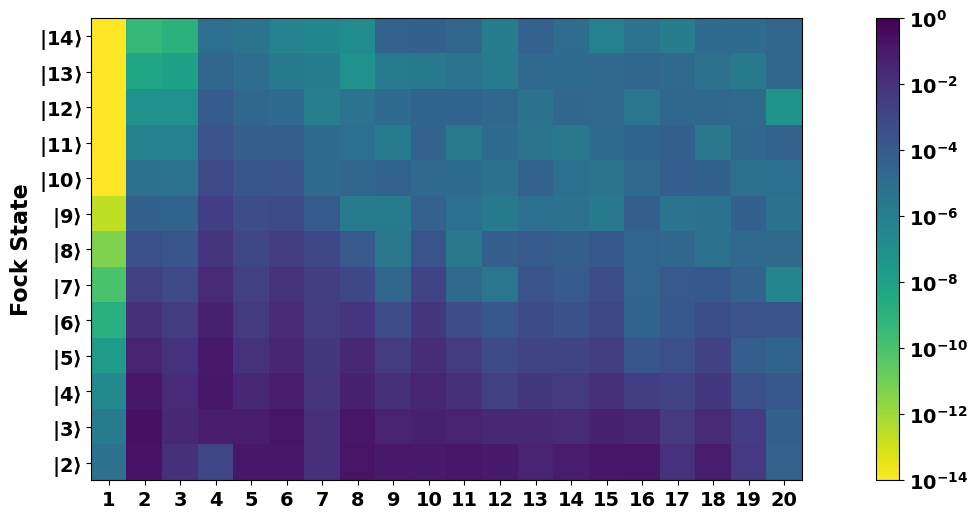

In [81]:
# Start from 1 state
lev = 9
ind = lev-1
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_0b_out[ind]['data1'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+2}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen1.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

## Qubit (N_trunc = 2), penalize two largest Fock state (pen=2), sweep over 1-10 bumper states

In [20]:
dictlist19_1 = [] 
N_trunc = 2
seq_len = 20
thres = 1e-7
pen = 2
for bumper in range(2,11):
    dictlist19_1.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol, pen, thres, Add_block = False, Disp=False))


 ********** Optimizing Parameters for 20 blocks and 2 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 4 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 5 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 6 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 7 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 8 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 9 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 10 bumper state(s) **********


In [113]:
# dictlist19_1 = [{'Infidelity': 0.005374395288527012,
#   'Betas_real': tc.tensor([ 0.1409, -0.2421, -0.2320,  0.5785, -0.4830, -0.9545, -0.2410,  0.3119,
#           -1.6653, -1.2379, -0.3261, -0.2702,  0.3572,  0.5174,  0.8232,  1.6219,
#            0.4990,  0.7240,  0.3488,  0.0725]),
#   'Betas_imag': tc.tensor([ 3.2181, -4.6925, -1.2341, -0.2791, -1.0024, -1.0468,  0.1165,  0.9228,
#           -0.6528,  0.3420, -0.1901,  0.5836,  0.1187, -0.8754, -0.4129,  0.5864,
#           -0.7261,  0.0783, -0.2524,  0.0427]),
#   'Phis': tc.tensor([-0.5068,  0.4457,  3.4324, -0.9272,  3.4758,  1.7821,  0.7616, -0.5529,
#            0.1926, -1.0716,  0.4973,  0.9585, -0.8274,  2.4973,  0.9751,  1.6707,
#           -1.7762,  1.6409, -2.1208,  0.1020]),
#   'Thetas': tc.tensor([ 0.0075,  2.5678,  0.1415,  2.6313, -0.3018, -0.1960, -1.8350, -0.9154,
#           -3.2172,  0.0423, -2.4728,  1.2491,  0.8454,  1.0330,  1.3189, -1.4194,
#           -1.2093,  0.9366, -1.1903, -2.0535])},
#  {'Infidelity': 0.0011435330379754305,
#   'Betas_real': tc.tensor([ 0.0833, -0.9309, -0.9698, -0.3471, -0.1705,  0.2858,  0.5335,  0.4522,
#           -0.0080, -0.3793,  0.1338, -0.6111,  0.4800,  1.0116,  0.4342,  1.0225,
#            0.3071, -0.8090,  0.0395,  0.0801]),
#   'Betas_imag': tc.tensor([ 0.2629, -3.9761, -4.0855,  0.0418,  0.0206, -0.4835, -0.2734, -0.4147,
#            0.3710,  0.4965,  0.2770,  0.2997, -0.0263,  0.0506, -0.1933,  0.7201,
#           -0.7577, -0.0756,  0.4298, -0.0417]),
#   'Phis': tc.tensor([ 1.0018,  2.0920,  1.8721, -0.9336,  1.2732,  0.9488, -2.3369,  1.4628,
#            0.6551, -0.5671,  0.7663, -0.6464,  0.2709,  1.0305,  1.8252,  0.4997,
#            0.0094, -0.2582, -2.8707,  1.2796]),
#   'Thetas': tc.tensor([-3.1983, -0.0630,  0.0223,  3.6710, -1.0045, -1.8594, -1.4460,  0.1053,
#           -0.6203,  0.3539, -0.5769,  1.9650,  1.5479,  0.0619, -0.4370, -0.3851,
#            1.0428,  1.3578, -1.6185, -1.5267])},
#  {'Infidelity': 0.0009517356520518661,
#   'Betas_real': tc.tensor([ 0.0230, -1.1096, -1.1555, -0.0883, -0.4753, -0.7327, -0.3706,  0.0369,
#           -0.4477,  0.2590,  0.3106,  0.0941, -0.6169, -0.1136,  1.0079,  2.5437,
#            0.4698, -0.7526,  0.2370,  0.5861]),
#   'Betas_imag': tc.tensor([ 0.5964, -4.0775, -4.1723, -0.8679, -0.7196,  0.2956, -0.3745, -0.5955,
#           -1.0652,  0.3960,  0.7870,  0.3350,  0.8135, -0.0890, -0.7927,  0.3114,
#           -0.7741,  0.3436,  0.4301, -0.1737]),
#   'Phis': tc.tensor([ 1.9396,  2.9188,  2.9985,  0.0647,  1.7874,  0.4771, -1.3651,  0.5903,
#           -0.4394, -1.1360,  0.8574,  1.1432, -1.7247,  0.7747,  1.2692, -2.4091,
#           -0.7455,  0.1540, -2.8395,  1.6018]),
#   'Thetas': tc.tensor([-3.1467,  0.0058, -0.0351,  1.5104, -0.0247,  0.1771, -0.6261, -1.3084,
#           -0.2855, -1.5385, -0.0317, -1.7454, -0.1464, -1.0671,  0.8541, -0.2308,
#            0.6214,  1.5591, -1.3519, -1.2182])},
#  {'Infidelity': 0.0009666899568401277,
#   'Betas_real': tc.tensor([-0.0083, -0.6350,  0.3646, -0.1205, -0.3781, -0.8767,  0.0239,  0.4643,
#            0.3012,  0.9220,  0.1010,  0.0661, -0.6734,  0.7349,  0.2494,  1.2873,
#            0.6339, -0.5244,  0.3321,  0.5747]),
#   'Betas_imag': tc.tensor([-0.5906, -1.5316, -0.8031, -1.0133, -0.5770,  0.3845,  0.4702, -0.2925,
#           -1.6273,  0.8018,  1.1456,  0.7023,  0.3034,  0.2960, -0.4717,  0.0131,
#           -1.2423,  0.4392,  0.2554, -0.8609]),
#   'Phis': tc.tensor([ 0.8647,  1.8312,  2.2753,  0.8847,  1.2582, -0.0791, -0.7639,  1.2899,
#           -0.1363, -0.8167,  0.6262, -0.7963, -1.0005,  1.0486,  1.7056, -1.2147,
#           -0.8076,  0.0878, -2.8251,  1.4029]),
#   'Thetas': tc.tensor([-0.1758, -0.1731,  0.1864,  1.3641,  0.3657, -0.5966, -0.8183, -0.6792,
#           -0.3322, -0.0945,  0.0925,  0.9698,  2.2381, -1.1688,  1.0397, -1.4663,
#           -0.0648,  1.0014, -1.3421, -1.4740])},
#  {'Infidelity': 0.0007636470254510641,
#   'Betas_real': tc.tensor([ 0.2403, -1.0120, -0.5255, -0.2929, -0.0950, -0.8457, -0.0249,  1.4206,
#            0.4971,  0.0114,  0.0907,  0.2455, -0.1775,  0.7626,  0.1218,  0.7158,
#            0.6950,  0.3151,  0.8030,  1.2388]),
#   'Betas_imag': tc.tensor([-1.0503, -2.1651, -1.2452, -0.7529, -0.3389,  0.9643,  0.6013, -0.2308,
#           -1.7637,  1.4565,  1.0657,  0.0253,  0.6837, -0.0526, -0.5026, -0.4954,
#           -1.5953,  0.5632,  0.5354, -0.6488]),
#   'Phis': tc.tensor([ 0.9605,  2.5769,  1.6954,  0.6467,  1.2317, -0.2760, -0.8134,  1.3989,
#            1.2498, -0.9045,  0.9881,  0.0329, -0.5960,  1.0522,  1.3519, -0.6644,
#           -1.2070,  0.8441, -0.9637,  1.6323]),
#   'Thetas': tc.tensor([-0.1379, -0.0333,  0.0392,  0.5887,  1.0963, -1.9928, -1.2254, -0.6014,
#           -0.0345,  0.2079,  0.0849,  0.7835,  1.1420, -1.1707,  0.6369, -1.7976,
#           -0.0756,  0.5580, -0.1694, -0.3950])},
#  {'Infidelity': 0.000438271788880229,
#   'Betas_real': tc.tensor([ 0.1673, -1.0976,  0.1251,  0.1000,  0.0940,  0.1356,  0.4845,  1.3043,
#           -0.6202,  0.1892,  0.1527,  0.6520, -0.0378,  0.6036, -0.1403,  0.8221,
#           -0.0565,  0.0610,  0.5229,  0.5812]),
#   'Betas_imag': tc.tensor([-0.7620, -1.8438, -1.2804, -1.4683, -0.6733,  0.6953,  0.3997,  0.0706,
#           -0.9141,  1.3517,  0.5334, -0.3158,  0.7467, -0.1565, -0.4171, -0.8399,
#           -1.5997,  0.3307, -0.2040, -1.0568]),
#   'Phis': tc.tensor([ 1.8179,  2.6186,  2.1001, -0.3482,  1.5487,  0.3930, -1.1182,  1.5746,
#            1.0022, -0.5242,  1.2266,  0.5840, -0.7101,  1.2421,  1.3340, -0.4430,
#           -1.3755,  0.7185, -1.5321,  0.9202]),
#   'Thetas': tc.tensor([-0.1523, -0.1245,  0.0058,  0.3188, -0.1366, -1.3159, -1.2222, -0.4087,
#           -1.1028,  0.4072,  0.0440,  1.1832,  1.4132, -1.5774,  0.8551, -1.4234,
#            0.0473,  0.9046, -0.8072, -0.5393])},
#  {'Infidelity': 0.0005112029612064362,
#   'Betas_real': tc.tensor([-0.1722, -1.2052,  0.1784, -0.1300, -0.3211, -0.5336,  0.2356,  1.1290,
#           -0.5485, -0.5438, -0.3590,  0.2331, -0.7736,  0.6596,  0.6497,  0.8617,
#           -0.2022, -0.3583,  0.4378,  0.8919]),
#   'Betas_imag': tc.tensor([-0.1937, -2.4170, -1.5445, -1.3515, -1.0751,  0.4748,  0.7093,  0.6183,
#           -1.1021,  0.4454,  0.7895,  0.9920,  0.1806,  0.2064, -0.4678, -0.1343,
#           -1.6671,  0.6735,  0.2297, -0.7354]),
#   'Phis': tc.tensor([ 1.3986,  1.5257,  2.1079,  0.5119,  1.3667,  1.2549, -1.1548,  0.9098,
#            0.5045, -0.9380,  0.7558, -0.0466, -0.5690,  1.7370,  0.9060, -0.6329,
#           -0.9453, -0.2769, -2.0669,  0.7003]),
#   'Thetas': tc.tensor([-0.3355, -0.4488,  0.0307,  0.4933,  0.0617, -0.8599, -0.7252, -0.2126,
#           -0.9994,  0.5730, -0.5389,  0.9456,  2.1447, -0.9339,  0.7673, -1.6535,
#           -0.2815,  1.1236, -1.1353, -1.4402])},
#  {'Infidelity': 0.0005434571648947895,
#   'Betas_real': tc.tensor([ 0.3880, -1.4807, -0.3178, -0.3546, -0.3236, -0.2931,  0.3398,  1.0547,
#           -0.7348,  0.4254,  0.4992,  0.2510, -0.3713,  0.6222,  0.1422,  0.8433,
#           -0.2867, -0.5329,  0.3600,  1.1554]),
#   'Betas_imag': tc.tensor([-0.5114, -1.9755, -1.2568, -1.3265, -0.6127,  0.7668,  0.6369,  0.0454,
#           -1.8751,  1.1743,  1.6044,  0.3224,  0.6116, -0.0331, -0.6250,  0.0458,
#           -1.5419,  0.5024,  0.0924, -1.0858]),
#   'Phis': tc.tensor([ 1.5151,  2.0007,  1.4753,  0.1646,  1.2265,  0.7430, -0.8842,  1.4768,
#            0.8439, -0.9443,  1.1938,  0.3826, -1.2139,  1.7527,  1.3427, -0.9922,
#           -1.7227, -0.3917, -1.8623,  0.1636]),
#   'Thetas': tc.tensor([ 0.1216,  0.0469, -0.0170,  0.2279,  0.2309, -0.9135, -0.7994, -0.4632,
#           -0.5570,  0.1673, -0.0053,  1.4908,  1.3853, -1.4607,  1.2321, -1.5085,
#           -0.3202,  0.6649, -1.3307, -1.2431])},
#  {'Infidelity': 0.0011260793544352055,
#   'Betas_real': tc.tensor([ 0.9467, -1.1810, -0.4472,  0.1012, -0.2172, -1.0464,  0.8402,  1.0060,
#           -0.5647, -0.1737, -0.0021,  0.8704, -0.4973, -0.3840,  0.9473,  2.0490,
#            0.5319, -0.1371,  0.0163,  1.3969]),
#   'Betas_imag': tc.tensor([-1.2081, -2.5944,  0.0831, -1.5357, -0.7081,  0.5643,  0.9882,  0.4682,
#           -0.9657,  1.1358,  0.9312,  0.1026,  0.7358,  0.0323, -1.2116, -1.4630,
#           -1.9337,  0.2124,  0.3303,  0.1446]),
#   'Phis': tc.tensor([ 1.2306,  1.9321,  2.2818,  0.4490,  1.6102,  0.0222, -0.8510,  1.0006,
#           -0.1976, -0.8021,  1.3982,  0.3514, -1.7777,  1.3566,  1.1783,  0.2667,
#           -0.5783,  0.4200, -1.0850,  0.6547]),
#   'Thetas': tc.tensor([ 0.0047,  0.0050,  0.9385,  1.5227,  0.2677, -1.0907, -0.5499,  0.2687,
#           -2.7079,  0.3078,  0.1881,  0.8471,  1.7578, -0.7965,  1.0538, -0.0976,
#           -0.0673,  0.5860, -0.0528, -0.6731])}]

In [34]:
dictlist19_1_out = []
pen = 2 
for k in range(len(dictlist19_1)):
    betas_real = dictlist19_1[k]['Betas_real']
    betas_imag = dictlist19_1[k]['Betas_imag']
    phis = dictlist19_1[k]['Phis']
    thetas = dictlist19_1[k]['Thetas']
    bumper_check = 13
    dictlist19_1_out .append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

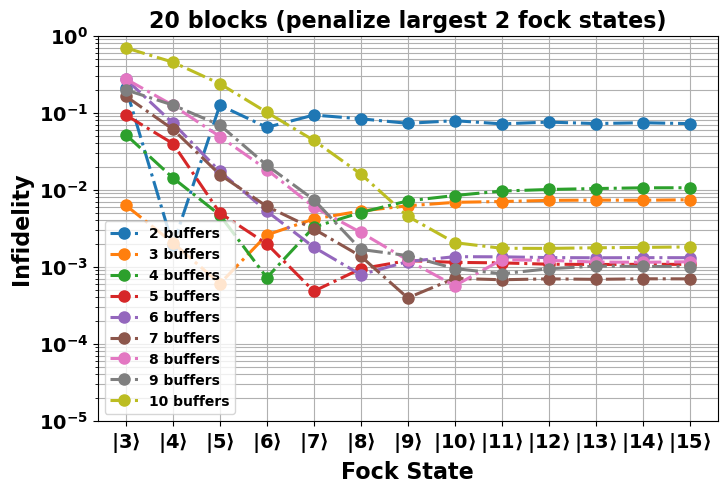

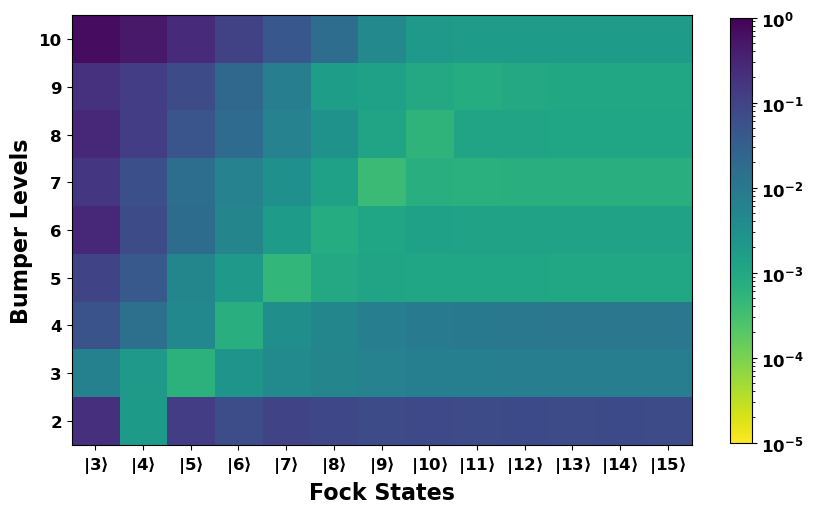

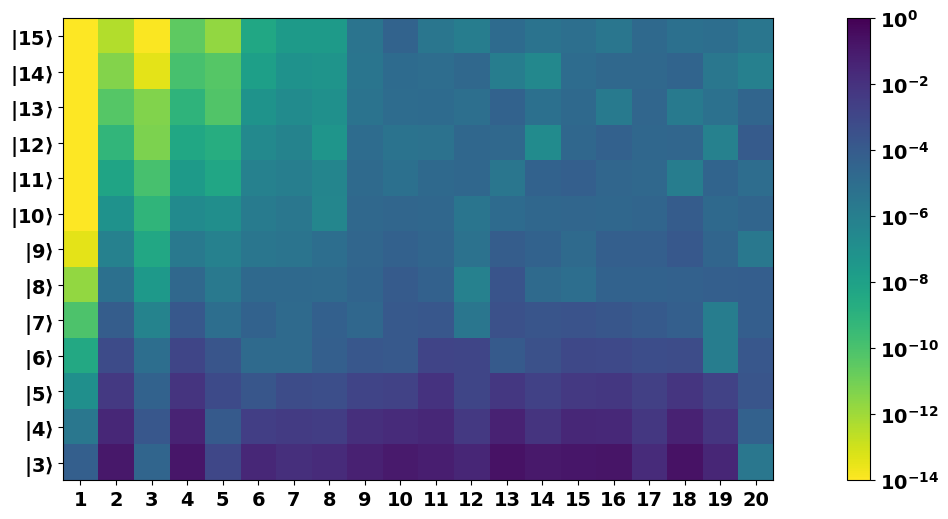

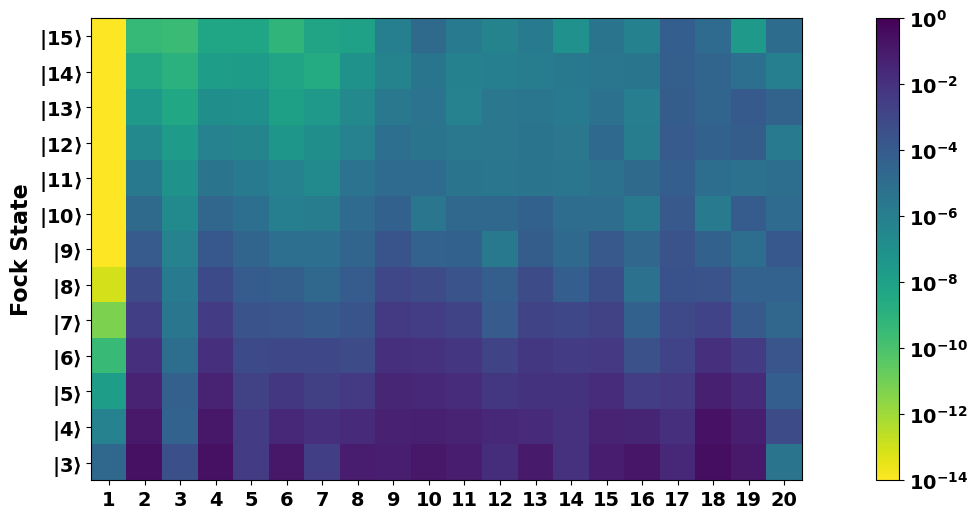

In [66]:
plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_1_out)):
    plt.plot(x2, dictlist19_1_out[k]['Bump_Infid'],  'o-.', markersize=8, lw = 2.2, label=f'{k+2} buffers')
plt.title('20 blocks (penalize largest 2 fock states)', fontsize =16, fontweight='bold')
plt.ylabel('Infidelity', fontsize=16, fontweight='bold')
plt.ylim(vmin0, vmax0)
plt.yscale('log')
plt.xticks(x2)
plt.legend()
plt.xticks(x2, [rf"$|{i+1}\rangle$" for i in x2])
plt.xlabel('Fock State', fontsize=16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QubitGate_loss2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

L = len(dictlist19_1_out)
data = np.zeros((len(dictlist19_1_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_1_out[i]['Bump_Infid']


plt.rcParams["font.weight"] = "bold"
plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log', vmin = vmin0, vmax=vmax0)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.92)
plt.xticks(x3, [rf"$|{i+1}\rangle$" for i in x2])
plt.yticks(x4, [L-i+1 for i in range(L)])
plt.xlabel('Fock States', fontsize=16, fontweight='bold')
plt.ylabel('Bumper Levels', fontsize=16, fontweight='bold')
plt.savefig('New_QubitGate_loss2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


vmin = 1e-14
vmax = 1
bumper = 13  
lev = 7
ind = lev-2
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[ind]['data'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+3}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
# plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


lev = 9
ind = lev-2
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[ind]['data'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+3}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

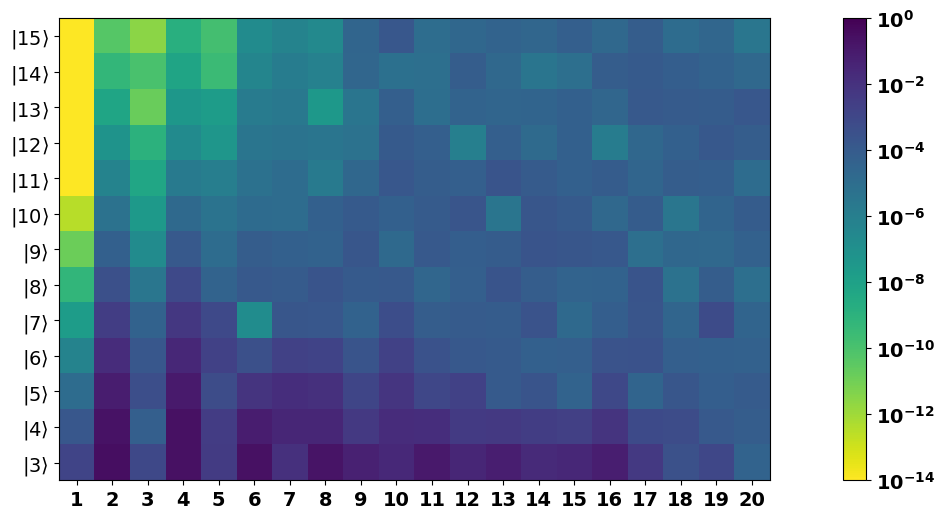

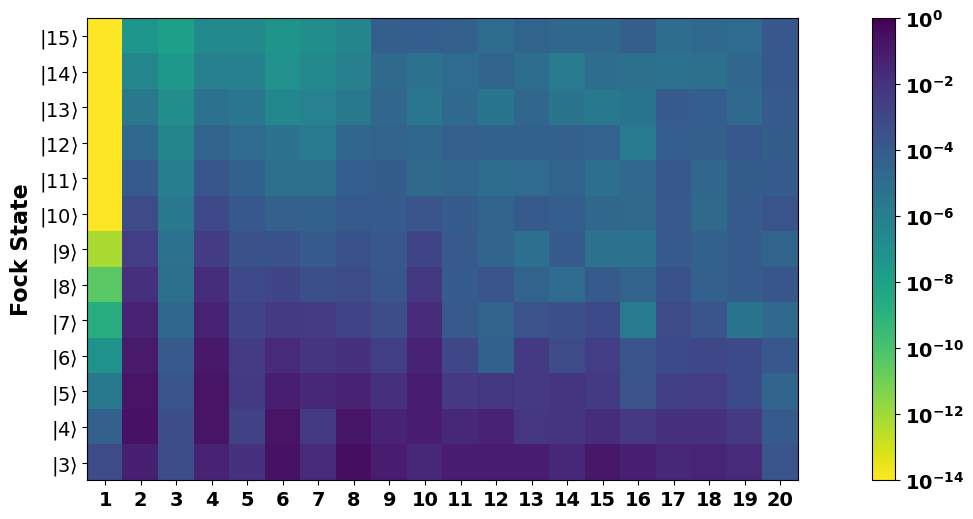

In [258]:
lev = 7
ind = lev-2
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[ind]['data1'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+3}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
# plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


lev = 9
ind = lev-2
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_1_out[ind]['data1'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+3}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen2.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

## Qubit (N_trunc = 2), penalize three largest Fock states (pen=3), sweep over 3-10 bumper states

In [24]:
dictlist19_2 = [] 
N_trunc = 2
seq_len = 20
thres = 1e-7
pen = 3
for bumper in range(3,11):
    dictlist19_2.append(ECD_Compile(seq_len, cav_unitary, bumper, N_trunc, tol,pen, thres, Add_block = False, Disp=False))


 ********** Optimizing Parameters for 20 blocks and 3 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 4 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 5 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 6 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 7 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 8 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 9 bumper state(s) **********

 ********** Optimizing Parameters for 20 blocks and 10 bumper state(s) **********


In [111]:
# dictlist19_2 = [{'Infidelity': 0.005474532023072243,
#   'Betas_real': tc.tensor([ 0.1946, -0.8062, -0.7115, -0.2010, -0.4470,  0.0105,  0.5807, -0.0460,
#           -0.3961,  0.1247,  0.4558, -0.2245,  0.1589,  0.9625,  0.2908,  1.3042,
#            0.2527, -0.7431, -0.0256, -0.1354]),
#   'Betas_imag': tc.tensor([ 0.1420, -4.1941, -3.9949, -0.4517, -0.3407, -0.4055,  0.0610,  0.2299,
#            0.4182,  0.1223,  0.5696,  0.2227,  0.1608, -0.2122, -0.1015,  0.7046,
#           -0.7529, -0.0873,  0.4103,  0.0272]),
#   'Phis': tc.tensor([ 0.9197,  2.0018,  1.7933, -0.7762,  1.2417,  0.8619, -2.0473,  0.9093,
#            0.5876, -0.3329,  0.8138, -0.2923,  0.3045,  1.1721,  1.1578, -0.4039,
#            0.1958, -0.0361, -2.8989,  1.4061]),
#   'Thetas': tc.tensor([-3.1581, -0.0171,  0.1921,  2.4944, -0.3326, -1.4571, -1.2297, -0.6275,
#           -0.8442,  0.5858,  0.4480,  2.0059,  2.0048,  0.2375, -0.5027, -1.2168,
#            1.1793,  1.4848, -1.6666, -1.4046])},
#  {'Infidelity': 0.0012054805411025882,
#   'Betas_real': tc.tensor([-0.1532, -0.1116, -0.1404,  0.4325, -0.2744,  0.2103,  0.7571,  0.4054,
#            0.2755,  0.4781,  0.5145,  0.2080, -0.2209,  0.0947, -0.4240,  1.2307,
#            0.1107, -0.6874,  0.1971,  0.1009]),
#   'Betas_imag': tc.tensor([-0.3187, -0.9868, -1.1212, -0.5351, -0.7672,  0.1490, -0.1451, -0.6609,
#           -1.1231,  0.2202,  0.5382,  0.4590,  0.0804, -0.5166, -0.1316,  0.6241,
#           -0.7448,  0.3241,  0.4069,  0.0540]),
#   'Phis': tc.tensor([ 1.3384,  2.7356,  2.7831,  0.4959,  1.8269,  1.1696, -0.9136,  0.1782,
#           -0.2477, -0.5840,  1.2874,  0.9741, -0.1993,  1.7658,  1.6074, -0.8074,
#            0.0315, -0.2119, -2.8967,  1.3433]),
#   'Thetas': tc.tensor([ 5.6831e-01, -9.1461e-01,  1.3525e-03,  2.2241e+00,  7.2424e-02,
#           -7.6320e-01, -1.0785e-01,  2.7094e-01, -3.7540e-01,  4.1827e-02,
#            5.0141e-01,  6.9501e-01,  1.0887e+00, -2.7423e-01, -6.3046e-01,
#           -1.6280e+00,  1.0294e+00,  1.2953e+00, -1.2515e+00, -1.5753e+00])},
#  {'Infidelity': 0.001293468289077282,
#   'Betas_real': tc.tensor([-0.3486, -1.0218,  0.2128, -0.4180,  0.2419,  0.2741,  0.0423,  0.4333,
#           -0.4593, -0.0068,  0.4151, -0.0711, -0.3638,  0.5349,  0.4984,  1.2724,
#            0.4328, -0.6045,  0.4064,  0.4688]),
#   'Betas_imag': tc.tensor([-0.6341, -1.2857, -0.8104, -0.6110, -0.5831,  0.4027,  0.8017,  0.3019,
#           -0.4352,  0.6452,  0.4404,  0.3957,  0.2506,  0.0898, -0.5777,  0.1034,
#           -1.6692,  0.6164,  0.3071, -0.4437]),
#   'Phis': tc.tensor([ 0.8754,  2.1360,  1.8221,  1.2018,  1.7006,  1.0181, -1.1664,  0.9684,
#            1.4101, -0.9372,  1.2737,  0.3941, -0.7191,  1.4649,  1.3602, -1.2150,
#           -0.9961, -0.4817, -2.3464,  1.1063]),
#   'Thetas': tc.tensor([ 0.4931,  0.1952,  0.2580,  1.7814,  0.5144, -0.9447, -0.8232, -0.3324,
#           -1.3042,  1.0048,  0.5929,  0.8969,  2.2216, -0.5491,  0.8591, -2.1188,
#           -0.2559,  1.3977, -1.4359, -1.5106])},
#  {'Infidelity': 0.0003216955519746989,
#   'Betas_real': tc.tensor([-0.1994, -0.9459, -0.4451, -0.3376, -0.0931, -0.9679, -0.0914,  1.2430,
#           -0.2617, -0.4350,  0.1562, -0.0030, -0.3350,  0.6451, -0.0225,  0.4656,
#            0.4328,  0.2571,  0.6968,  0.6864]),
#   'Betas_imag': tc.tensor([-1.1266, -1.9149, -0.9411, -0.9021, -0.3054,  0.6661,  0.5686, -0.0937,
#           -1.2542,  0.8700,  0.9403,  0.5775,  0.7638, -0.2175, -0.7527, -0.2294,
#           -1.1801,  0.2125,  0.2290, -0.7846]),
#   'Phis': tc.tensor([ 0.8597,  2.9165,  1.8203,  0.4626,  1.6164,  0.0858, -0.8516,  0.9756,
#            1.4011, -0.8506,  1.1152,  0.0055, -1.0121,  0.9626,  1.4885, -0.7616,
#           -1.1224,  1.0290, -0.8602,  2.0713]),
#   'Thetas': tc.tensor([-0.7962, -0.0467,  0.0447,  1.1427,  0.3432, -1.6562, -0.9243, -0.7259,
#           -0.0403, -0.0212,  0.1410,  0.3803,  1.5317, -1.1524,  0.3935, -1.7517,
#           -0.4928,  0.7354, -0.2674, -0.4797])},
#  {'Infidelity': 0.0003319318639114499,
#   'Betas_real': tc.tensor([ 0.0487, -0.8782,  0.0591, -0.2648, -0.5305, -0.1385,  0.7385,  1.3469,
#           -0.0354, -0.2534,  0.7907,  0.4323,  0.0904,  0.1450,  0.2231,  0.8912,
#            0.1725,  0.5369,  0.3231,  0.9321]),
#   'Betas_imag': tc.tensor([-0.2123, -1.9643, -2.2201, -1.3362, -1.4184,  0.5561,  0.4570,  0.1603,
#           -0.5329,  0.6350,  0.7308, -0.0042,  0.0446, -0.1709, -1.0509, -1.2955,
#           -0.6875,  0.7372, -0.2161, -0.7234]),
#   'Phis': tc.tensor([ 0.6901,  2.3855,  2.2609, -0.6482,  1.5990,  0.6526, -2.1047,  0.9082,
#            0.7149, -0.9614,  1.3029,  0.2624, -0.2924,  1.9757,  0.9689,  0.1084,
#           -0.6463, -0.0047, -1.8730,  0.3837]),
#   'Thetas': tc.tensor([ 1.1652e-01,  2.0702e-01, -3.6317e-03,  7.9589e-01, -3.0489e-04,
#           -1.2482e+00, -9.7303e-01,  6.4868e-02, -8.0892e-01, -1.5039e+00,
#           -7.6583e-01,  1.4587e+00,  8.2209e-01, -1.0552e-01, -1.5390e-01,
#           -1.2294e+00, -2.8119e-01,  1.5495e+00, -1.2045e+00, -1.3531e+00])},
#  {'Infidelity': 0.000695146678481251,
#   'Betas_real': tc.tensor([ 0.0906, -0.9883, -0.2167, -0.2844, -0.2624, -0.6976,  0.0662,  0.8668,
#           -0.0366, -0.2610, -0.2420,  0.2824, -0.7690,  0.5828,  0.5083,  0.9078,
#            0.0424, -0.3451,  0.5059,  1.0868]),
#   'Betas_imag': tc.tensor([-0.2816, -2.1385, -1.8669, -1.6103, -0.9532,  0.6635,  0.7564,  0.2917,
#           -0.9366,  0.5689,  0.8159,  0.7810,  0.4207,  0.2198, -0.5064, -0.1923,
#           -1.6822,  0.6544,  0.1449, -0.9342]),
#   'Phis': tc.tensor([ 1.4121,  1.5220,  2.1520,  0.7418,  1.3051,  0.9249, -0.6124,  1.2093,
#            0.5127, -0.7888,  0.7046,  0.1221, -0.6644,  1.8376,  0.8077, -0.6151,
#           -0.9736, -0.3038, -1.8110,  0.6246]),
#   'Thetas': tc.tensor([-0.0158, -0.3157, -0.0103,  0.6862,  0.0569, -0.6904, -0.8465, -0.3304,
#           -0.3839,  0.2045, -0.5076,  1.0279,  1.7443, -0.9018,  1.0390, -1.6820,
#           -0.1030,  0.9664, -1.0920, -1.2212])},
#  {'Infidelity': 0.0008073776261880994,
#   'Betas_real': tc.tensor([ 0.0440, -1.6412,  0.0153, -0.4330, -0.1026,  0.3437,  0.1586,  1.0045,
#           -0.7315,  0.1133,  0.7381,  0.4543, -0.3505,  0.7305,  0.5720,  1.1887,
#            0.0743,  0.8857,  0.2944,  1.3015]),
#   'Betas_imag': tc.tensor([-7.0192e-01, -1.8554e+00, -1.5268e+00, -1.3714e+00, -1.2983e+00,
#            4.5116e-01,  1.0574e+00,  4.8249e-01, -9.5830e-01,  9.2404e-01,
#            6.8652e-01,  6.2078e-01,  7.2416e-01,  1.6699e-01, -7.1917e-01,
#           -6.1227e-01, -1.4114e+00,  5.0704e-04, -4.8798e-01, -2.8074e-01]),
#   'Phis': tc.tensor([ 1.5617,  2.8719,  1.7082,  0.5667,  1.3436,  0.7542, -0.8497,  0.5352,
#            0.9945, -1.6216,  1.8886,  1.3414, -0.8865,  1.9062,  1.9648, -0.2973,
#            0.0122,  2.0744, -2.0794, -0.0314]),
#   'Thetas': tc.tensor([-0.4528, -0.2434,  0.0164,  0.7355,  0.0395, -1.0452, -0.9326, -0.5215,
#           -1.6960,  1.5104,  0.1384,  0.8391,  0.0983, -1.9636,  1.6246, -0.3026,
#           -1.4415,  0.8984, -1.7543, -1.6653])},
#  {'Infidelity': 0.00038451142609119415,
#   'Betas_real': tc.tensor([ 0.5988, -1.7106, -0.6127, -0.2781, -0.5605, -0.6502,  0.7118,  0.7092,
#            0.5302,  0.4125, -0.0300,  0.5833, -0.0691,  0.6600,  0.3596,  1.5582,
#            0.5285, -0.5181,  0.4271,  1.7919]),
#   'Betas_imag': tc.tensor([-0.9097, -1.7399, -0.2270, -1.4168, -1.1118, -0.0137,  0.5808,  0.6342,
#           -0.8534,  0.6620,  0.7917,  0.1246,  0.4373, -0.1008, -1.4644, -0.8790,
#           -0.8425,  0.6282,  0.2426,  0.1841]),
#   'Phis': tc.tensor([ 1.2080,  1.8167,  1.6437,  0.0526,  1.4107,  1.3283, -1.1890,  0.4803,
#            0.7901, -1.3795,  1.3582,  0.5484, -1.2952,  1.9919,  1.1199,  0.0843,
#            0.6998,  0.4346, -2.0138,  0.8166]),
#   'Thetas': tc.tensor([-0.0399, -0.0145,  0.0118,  2.0095, -0.0611, -0.4268, -0.4596,  0.1050,
#           -1.1091, -0.4796, -0.1655,  1.0015,  1.6359, -1.1770,  0.7888, -0.3586,
#           -0.3510,  1.3763, -1.2737, -1.3152])}]

In [22]:
dictlist19_2_out = []
pen = 3 
for k in range(len(dictlist19_2)):
    betas_real = dictlist19_2[k]['Betas_real']
    betas_imag = dictlist19_2[k]['Betas_imag']
    phis = dictlist19_2[k]['Phis']
    thetas = dictlist19_2[k]['Thetas']
    bumper_check = 13
    dictlist19_2_out.append(check(betas_real, betas_imag, phis, thetas, cav_unitary, bumper_check, N_trunc, pen))
# print(betas_real, betas_imag)

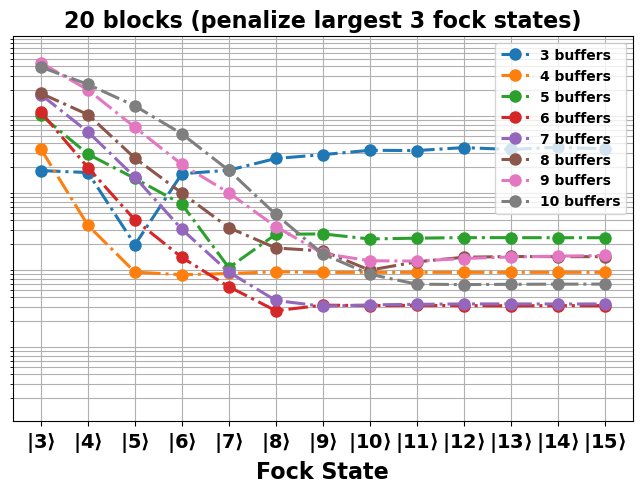

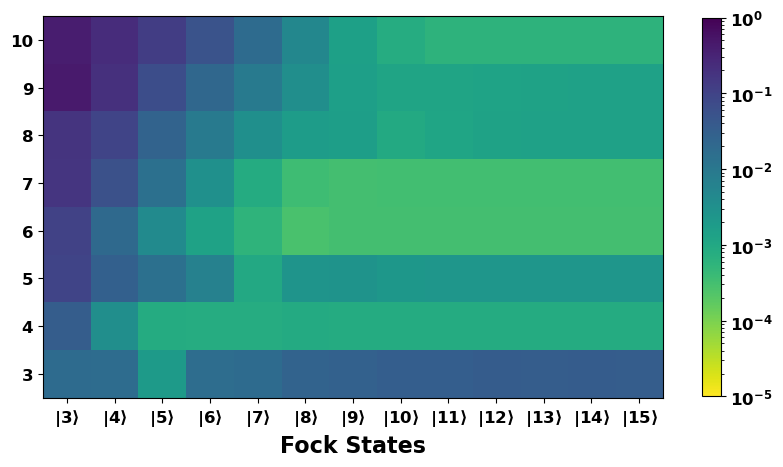

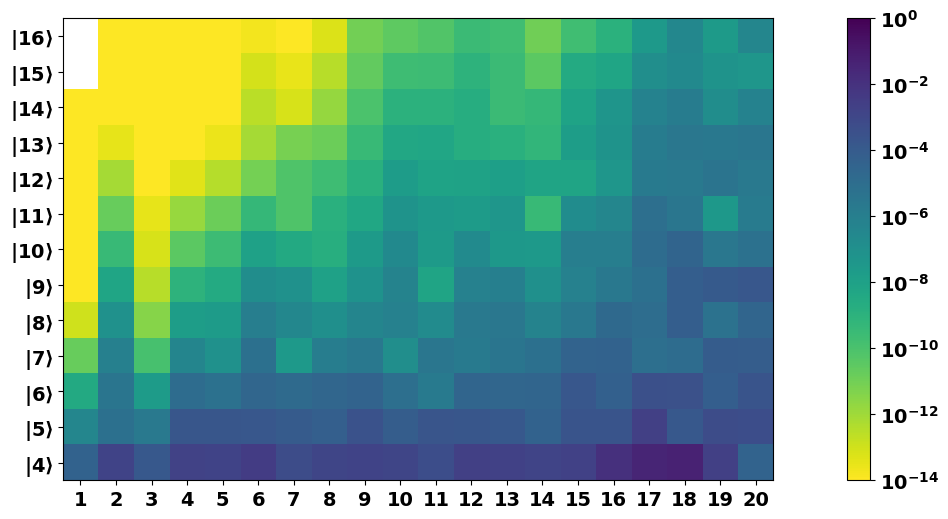

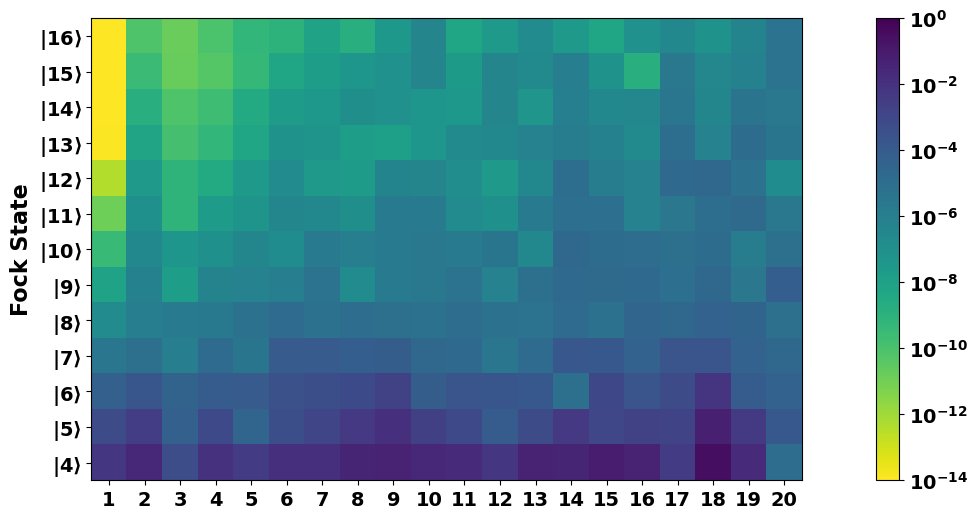

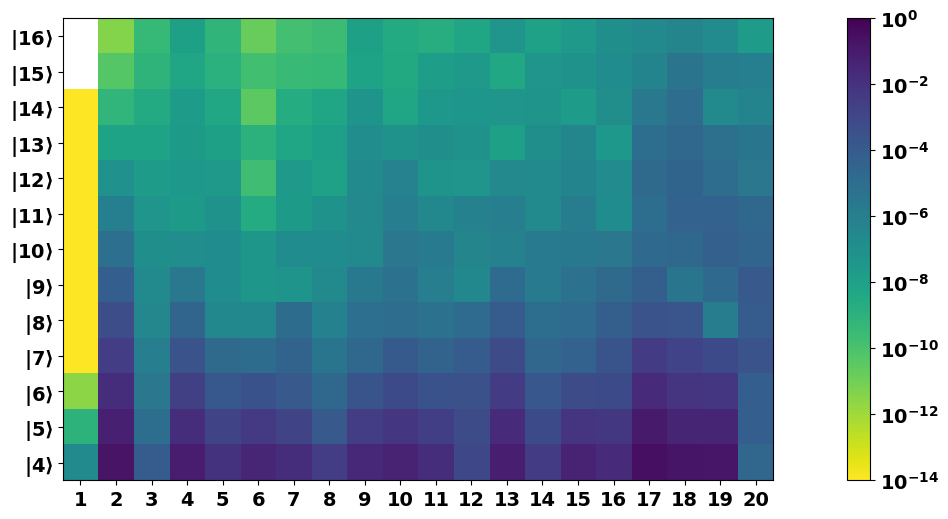

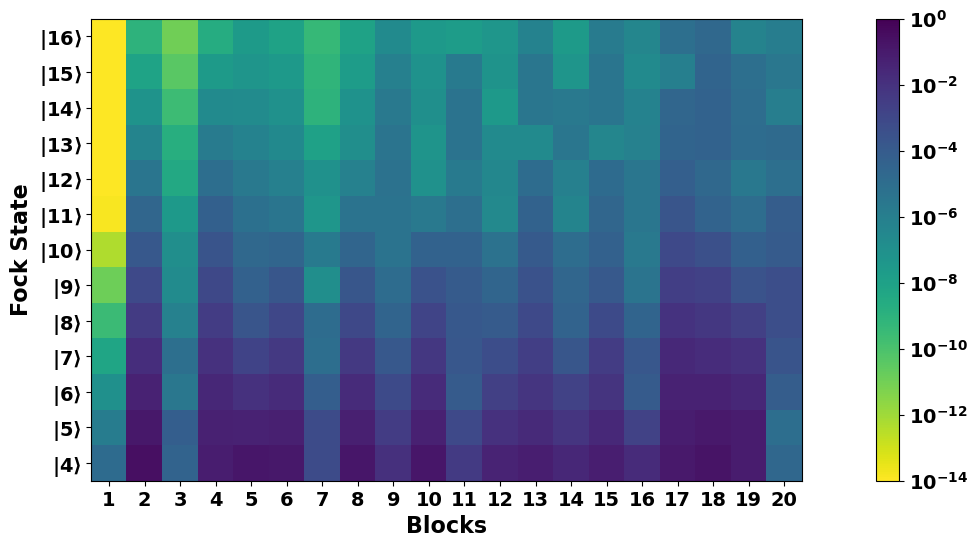

In [112]:
plt.figure(figsize =[8,5])
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
for k in range(len(dictlist19_2_out)):
    plt.plot(x2, dictlist19_2_out[k]['Bump_Infid'],  'o-.', markersize=8, lw = 2.2, label=f'{k+3} buffers')
plt.title('20 blocks (penalize largest 3 fock states)', fontsize =16, fontweight='bold')
# plt.ylabel('Infidelity', fontsize =16, fontweight='bold')
plt.ylim(vmin0, vmax0)
plt.yscale('log')
plt.xticks(x2)
plt.yticks([])
plt.legend()
plt.xticks(x2, [rf"$|{i+1}\rangle$" for i in x2])
plt.xlabel('Fock State', fontsize =16, fontweight='bold')
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.savefig('QubitGate_loss3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

L = len(dictlist19_2_out)
data = np.zeros((len(dictlist19_2_out), bumper_check))
for i in range(L):
    k = L-(i+1)
    data[k,:] = dictlist19_2_out[i]['Bump_Infid']


plt.rcParams["font.weight"] = "bold"
plt.figure(figsize=(10,6))
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
x2 = np.arange(N_trunc, bumper_check+N_trunc, dtype=int)
x3 = range(bumper_check)
x4 = range(L)
plt.imshow(data, cmap='viridis_r', norm='log', vmin = vmin0, vmax=vmax0)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(shrink=0.82)
plt.xticks(x3, [rf"$|{i+1}\rangle$" for i in x2])
plt.yticks(x4, [L-i+2 for i in range(L)])
plt.xlabel('Fock States', fontsize =16, fontweight='bold')
# plt.ylabel('Bumper Levels', fontsize =16)
plt.savefig('New_QubitGate_loss3.pdf', format = 'pdf',bbox_inches='tight')
plt.show()

vmin = 1e-14
vmax = 1# Fig, 3a


lev = 4
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
im = plt.imshow(dictlist19_2_out[ind]['data'], cmap='viridis_r', norm='log', vmin=vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(im, ticks= [10**k for k in range(-26,1,2)])
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
# plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

lev = 6
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[ind]['data'], cmap='viridis_r', norm='log', vmin=vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


lev = 7
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[ind]['data'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
# plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
# plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()




lev = 10
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[ind]['data'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
# plt.colorbar()
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
plt.xlabel('Blocks', fontsize=16,fontweight='bold')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

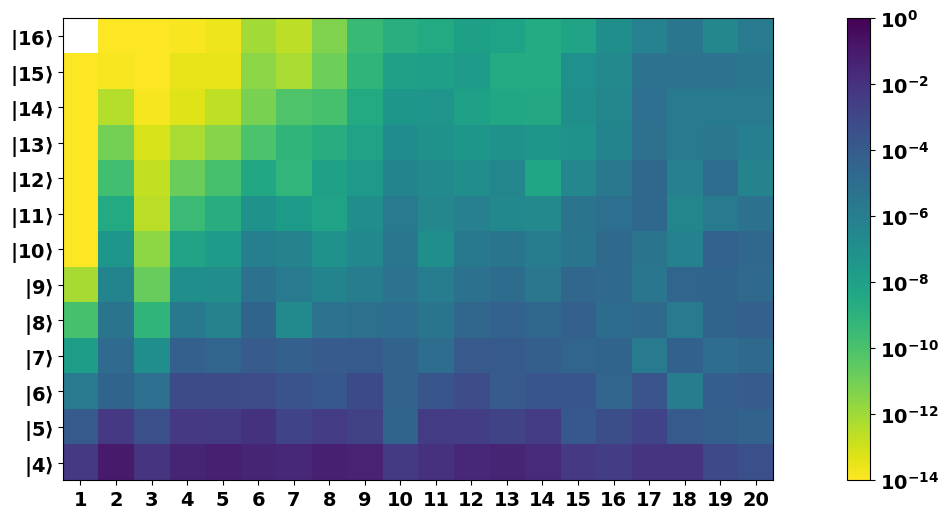

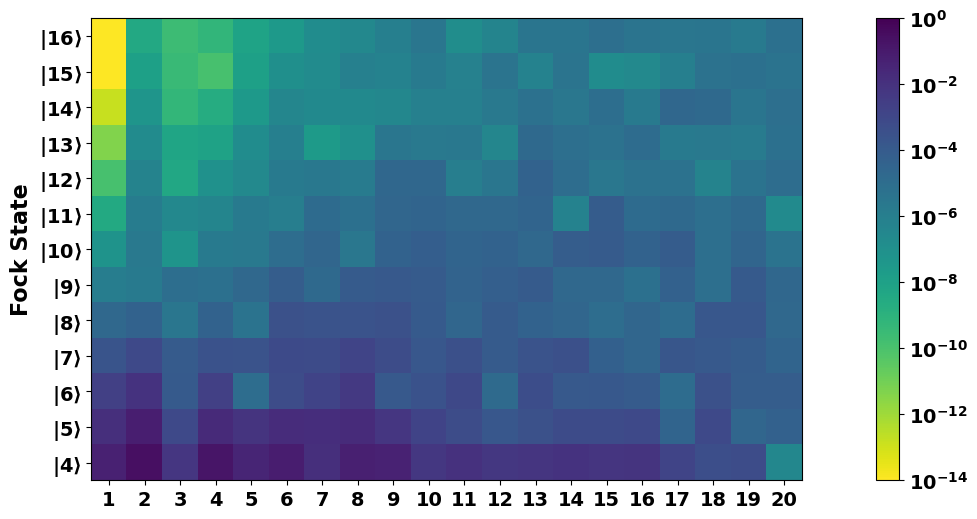

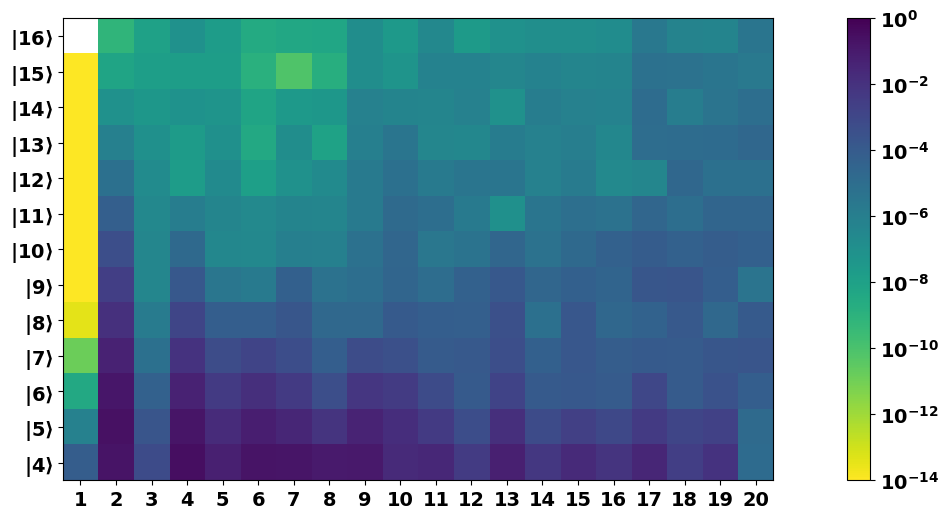

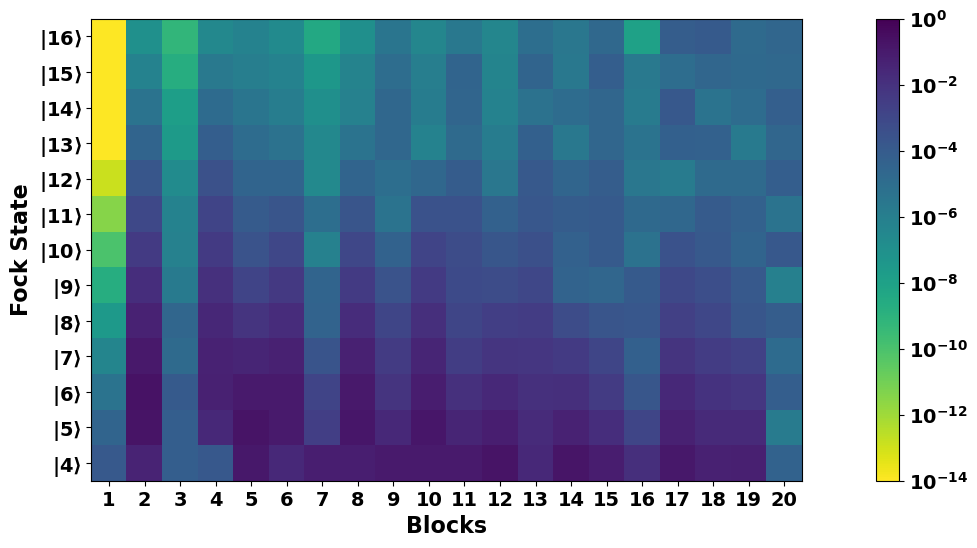

In [92]:
lev = 4
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
im = plt.imshow(dictlist19_2_out[ind]['data1'], cmap='viridis_r', norm='log', vmin=vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar(im, ticks= [10**k for k in range(-26,1,2)])
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
# plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

lev = 6
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[ind]['data1'], cmap='viridis_r', norm='log', vmin=vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()


lev = 7
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[ind]['data1'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
plt.colorbar()
# plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
# plt.xlabel('Blocks')
# plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()




lev = 10
ind = lev-3
plt.figure(figsize=(19,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
x5 = range(1, 21)
x6 = range(bumper)
plt.imshow(dictlist19_2_out[ind]['data1'], cmap='viridis_r', norm='log', vmin =vmin, vmax=vmax)  # ,  norm=colors.LogNorm(vmin=data.min(), vmax=data.max()   y = [rf"$|{i}\rangle$" for i in x2], , norm=colors.LogNorm(),
# plt.colorbar()
plt.colorbar()
plt.xticks(range(20), x5)
plt.yticks(x6, [rf"$|{i+4}\rangle$" for i in np.flip(x6)])
plt.xlabel('Blocks', fontsize=16,fontweight='bold')
plt.ylabel('Fock State', fontsize=16, fontweight='bold')
plt.savefig(f'1Qubit{lev}pen3.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

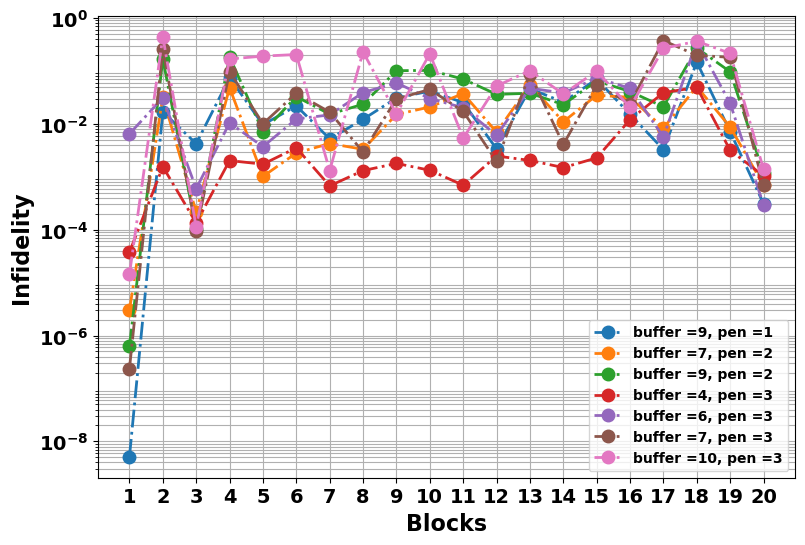

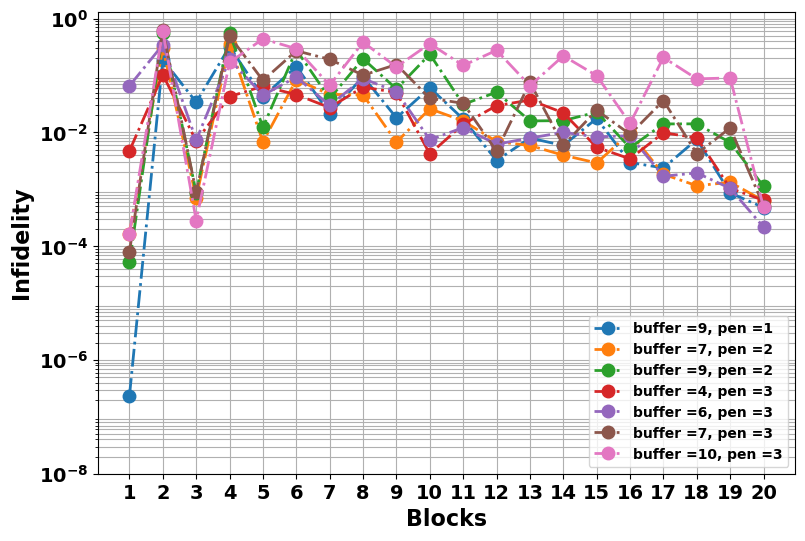

In [101]:
#  Summary plot for sum of infid from fock 4 -14 across 20 blocks 
case_id = ['buffer =9, pen =1', 'buffer =7, pen =2', 'buffer =9, pen =2', 'buffer =4, pen =3', 'buffer =6, pen =3', 'buffer =7, pen =3', 'buffer =10, pen =3']
case = [[],[],[],[],[],[],[]]
for b_num in range(20):    
    case[0].append(sum(dictlist19_0b_out[8]['data'][0:11,b_num]))      #  9pen1   
    case[1].append(sum(dictlist19_1_out[5]['data'][1:12,b_num]))       #  7pen2    
    case[2].append(sum(dictlist19_1_out[7]['data'][1:12,b_num]))       #  9pen2    
    case[3].append(sum(dictlist19_2_out[1]['data'][2:13,b_num]))       #  4pen3
    case[4].append(sum(dictlist19_2_out[3]['data'][2:13,b_num]))       #  6pen3
    case[5].append(sum(dictlist19_2_out[4]['data'][2:13,b_num]))       #  7pen3
    case[6].append(sum(dictlist19_2_out[7]['data'][2:13,b_num]))       #  10pen3



plt.figure(figsize=(9,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] ='bold'
x5 = range(1, 21)
# x6 = range(bumper)
for i in range(len(case)):
    plt.plot(x5, case[i], 'o-.' ,lw=2.0, markersize=9, label = case_id[i])
plt.yscale('log')
plt.xticks(x5)
plt.yticks(np.logspace(-8,0,5))
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.xlabel('Blocks', fontsize=16, fontweight='bold')
plt.legend()
plt.ylabel('Infidelity', fontsize=16, fontweight='bold')
plt.savefig('Qubitsummary0.pdf', format = 'pdf', bbox_inches='tight')
plt.show()




case1 = [[],[],[],[],[],[],[]]
for b_num in range(20):    
    case1[0].append(sum(dictlist19_0b_out[8]['data1'][0:11,b_num]))      #  9pen1   
    case1[1].append(sum(dictlist19_1_out[5]['data1'][1:12,b_num]))       #  7pen2    
    case1[2].append(sum(dictlist19_1_out[7]['data1'][1:12,b_num]))       #  9pen2    
    case1[3].append(sum(dictlist19_2_out[1]['data1'][2:13,b_num]))       #  4pen3
    case1[4].append(sum(dictlist19_2_out[3]['data1'][2:13,b_num]))       #  6pen3
    case1[5].append(sum(dictlist19_2_out[4]['data1'][2:13,b_num]))       #  7pen3
    case1[6].append(sum(dictlist19_2_out[7]['data1'][2:13,b_num]))       #  10pen3



plt.figure(figsize=(9,6))
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] ='bold'
x5 = range(1, 21)
# x6 = range(bumper)
for i in range(len(case1)):
    plt.plot(x5, case1[i], 'o-.' ,lw=2, markersize=9, label = case_id[i])
plt.yscale('log')
plt.xticks(x5)
plt.yticks(np.logspace(-8,0,5))
plt.grid(True, which="both", axis = 'both', ls="-",)
plt.xlabel('Blocks', fontsize=16, fontweight='bold')
plt.legend()
plt.ylabel('Infidelity', fontsize=16, fontweight='bold')
plt.savefig('Qubitsummary1.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

# Data Plots

In [110]:
# Fig. 2a Data
No_buffers = [7.422588055305823e-08, 4.02951769729043e-08, 5.878408870785279e-08, 4.181627843991009e-08, 6.495265125749938e-08,
                 8.033163112486363e-08, 5.449630080534007e-08, 9.750017682108592e-08]
TwoBuffer_nopen = [2.376323755015619e-05, 0.00010623427806422114, 9.002094157040119e-05, 4.5346801925916225e-05, 0.00010660885163815692,
                 2.809952275129035e-05, 7.450425619026646e-05, 0.0001020229174173437]
TwoBuffer_pen1 = [0.016544325277209282, 0.0016050804406404495, 0.002464152639731765, 0.001102112466469407, 0.0009976333240047097,
                     0.0021470836363732815, 0.0004913911106996238, 0.000746796082239598]
TwoBuffer_pen2 = [0.06874150037765503, 0.014713470824062824, 0.010987287387251854, 0.006725532468408346, 0.005286623258143663,
                     0.005890492349863052, 0.007293791510164738, 0.006233891937881708]

# Fig.3a data
data_Fig3a = {'1': [4.6695397e-05, 0.73751456, 0.7878276, 0.6072557, 0.8005679, 0.57916635, 0.71024495, 0.71453804, 0.7093193, 0.74995357, 0.6753264, 0.59476644, 0.69864744], 
              '2': [0.6957349, 8.3534025e-05, 0.8707038, 0.98863983, 0.76745486, 0.7379063, 0.5176713, 0.7343477, 0.6972432, 0.6296533, 0.6976868, 0.7165222, 0.7229332], 
              '3': [0.964375, 0.48375398, 0.00010269, 0.57380676, 0.7097867, 0.599656, 0.6642071, 0.6403657, 0.6493031, 0.63805294, 0.6179779, 0.624269, 0.623886], 
              '4': [0.87071097, 0.74476945, 0.7357008, 0.00020752, 0.7013455, 0.72845554, 0.6899478, 0.68886226, 0.59681135, 0.5145344, 0.62970465, 0.63438463, 0.63932633], 
              '5': [0.50997996, 0.62097955, 0.94106805, 0.78412706, 0.00022676, 0.6636528, 0.67508554, 0.67862576, 0.5055368, 0.50699973, 0.6180353, 0.61138755, 0.6424724], 
              '6': [0.7012018, 0.80034053, 0.7543879, 0.7456352, 0.58146065, 0.00044658, 0.53190047, 0.4306803, 0.61701816, 0.51426506, 0.5885469, 0.4952555, 0.48085877], 
              '7': [0.7195597, 0.96161616, 0.704274, 0.67186207, 0.45742348, 0.5838311, 0.00070426, 0.57396674, 0.4266538, 0.5258045, 0.49350047, 0.4449877, 0.44129747], 
              '8': [0.8046294, 0.7703309, 0.83874357, 0.735025, 0.7168202, 0.54639435, 0.47254616, 0.00078069, 0.4439976, 0.37663907, 0.45397606, 0.41255215, 0.39905822], 
              '9': [0.6806129, 0.66265935, 0.5691162, 0.7669171, 0.50164366, 0.44946024, 0.5069326, 0.529815, 0.00075677, 0.37215608, 0.3336843, 0.3861928, 0.4318681], 
              '10': [0.846605, 0.74309814, 0.8242975, 0.784696, 0.7119788, 0.65612346, 0.27936664, 0.6260955, 0.5681162, 0.0021634, 0.50934786, 0.5408731, 0.28710008]}

#  Fig.3b Data
data_Fig3b = {'1': [0.00016815, 1.1708049, 0.6891812, 0.7777762, 0.75671107, 0.5955009, 0.7663429, 0.6543734, 0.7222593, 0.7065801, 0.7348834, 0.7341868, 0.74627644], 
              '2': [0.07324083, 0.00016892, 0.08334092, 0.07195486, 0.07796041, 0.06792356, 0.08044174, 0.0783899, 0.0749076, 0.07856628, 0.07683183, 0.07645045, 0.07740612], 
              '3': [0.1714003, 0.13390182, 0.0006763, 0.13283917, 0.16910996, 0.25580344, 0.29772398, 0.3439759, 0.36116433, 0.37923267, 0.38287827, 0.38511693, 0.38717583], 
              '4': [0.5580831, 0.22175682, 0.10607094, 0.00121488, 0.0928205, 0.15456448, 0.21933804, 0.26036853, 0.2878847, 0.30157086, 0.30744857, 0.31142408, 0.31332263], 
              '5': [0.12605588, 0.03453507, 0.01705067, 0.00407432, 0.00067165, 0.00223891, 0.00305543, 0.00326839, 0.00333423, 0.00319175, 0.00310251, 0.00305262, 0.00303142], 
              '6': [0.1864282, 0.09234747, 0.03558685, 0.0140068, 0.00366283, 0.00064402, 0.00162474, 0.00153604, 0.00155026, 0.00154268, 0.00158497, 0.00158081, 0.00157412], 
              '7': [0.2943797, 0.07797279, 0.02241125, 0.0071849, 0.00227761, 0.00206845, 0.00126662, 0.0016874, 0.00178996, 0.00166981, 0.00165071, 0.00161812, 0.00161428], 
              '8': [0.16432731, 0.0595588, 0.02175451, 0.00740798, 0.00284434, 0.00247787, 0.00177489, 0.00075818, 0.00126587, 0.00139634, 0.00131447, 0.00129943, 0.00130525], 
              '9': [0.43712437, 0.24637976, 0.10173053, 0.03843706, 0.01275116, 0.00348756, 0.00092221, 0.00055317, 0.00035677, 0.00039216, 0.00043195, 0.00043687, 0.00045747], 
              '10': [0.73971224, 0.48298705, 0.26694337, 0.11686811, 0.05304017, 0.02162871, 0.00689546, 0.00265806, 0.00153862, 0.00115785, 0.0013556, 0.00148516, 0.00148437]}

#  Fig.3c Data
data_Fig3c = {'2': [0.20945713, 0.00189362, 0.12510242, 0.06459349, 0.0933108, 0.08342326, 0.07283477, 0.07878073, 0.07167365, 0.07552959, 0.0723008, 0.07412783, 0.07220098], 
              '3': [0.00624824, 0.00204488, 0.00060267, 0.00258879, 0.00417091, 0.00529249, 0.00618026, 0.00685785, 0.0070274, 0.00726999, 0.00733314, 0.00729525, 0.00740707], 
              '4': [0.05182332, 0.01424871, 0.00468749, 0.00072095, 0.00327331, 0.00505879, 0.00716078, 0.00840709, 0.00961185, 0.01006884, 0.01035973, 0.01058548, 0.01060687], 
              '5': [0.09306356, 0.03982773, 0.00499339, 0.00197899, 0.00048085, 0.00094111, 0.00120034, 0.00113901, 0.0011212, 0.00107796, 0.00106803, 0.00107432, 0.00107206], 
              '6': [0.27227977, 0.07332404, 0.01726246, 0.00526028, 0.00179315, 0.00078871, 0.00116766, 0.00135033, 0.0013443, 0.00131402, 0.00130683, 0.00131122, 0.00131019], 
              '7': [0.16321178, 0.06096992, 0.0157118, 0.00607338, 0.00309028, 0.00136863, 0.00039382, 0.000706, 0.00067729, 0.00069564, 0.00068596, 0.00069697, 0.00069572], 
              '8': [0.2740285, 0.12487974, 0.04898505, 0.01826225, 0.00596067, 0.00278979, 0.00121898, 0.00056632, 0.00122975, 0.00121111, 0.0011502, 0.00114219, 0.00115892], 
              '9': [0.19784479, 0.12576373, 0.06908631, 0.0207575, 0.00742463, 0.00167628, 0.00139403, 0.00094696, 0.00081025, 0.00094056, 0.0010201, 0.001008, 0.00100384], 
              '10': [0.6951112, 0.4533824, 0.23788992, 0.10120697, 0.04370919, 0.01600695, 0.00451541, 0.00205414, 0.00173599, 0.00172916, 0.00176204, 0.00178297, 0.00180778]}

#  Fig.3d Data
data_Fig3d = {'3': [0.0177242, 0.01670923, 0.00192784, 0.01611691, 0.0179378, 0.02544878, 0.02854169, 0.0324995, 0.03226189, 0.03524562, 0.03336139, 0.03552035, 0.03406931], 
              '4': [0.0336365, 0.00344891, 0.00085162, 0.0007875, 0.00081666, 0.00085946, 0.0008441, 0.00084514, 0.00084532, 0.00084495, 0.00084514, 0.00084506, 0.00084508], 
              '5': [0.09260537, 0.02899255, 0.0140231, 0.00648779, 0.0009722, 0.00263783, 0.00266711, 0.00229377, 0.00234901, 0.00238717, 0.00238505, 0.0023809, 0.00238026], 
              '6': [0.10155535, 0.01941325, 0.00405188, 0.00131869, 0.00055052, 0.0002682, 0.00031707, 0.00031261, 0.00031526, 0.00031251, 0.00031145, 0.00031228, 0.00031266], 
              '7': [0.17151502, 0.05655846, 0.01457766, 0.00305922, 0.0008514, 0.00036443, 0.00030686, 0.00031947, 0.00032486, 0.00032879, 0.00032885, 0.00032823, 0.0003286], 
              '8': [0.17822015, 0.09466652, 0.02573822, 0.00905352, 0.00321354, 0.0017509, 0.00160494, 0.00090347, 0.00115844, 0.00132715, 0.00135757, 0.00135147, 0.00134971], 
              '9': [0.44446853, 0.19830362, 0.06465211, 0.02130611, 0.0091092, 0.00331705, 0.00149005, 0.00119395, 0.00118468, 0.00127734, 0.00133996, 0.00137087, 0.00139905], 
              '10': [0.39157963, 0.23324214, 0.12271506, 0.05314349, 0.01782086, 0.00477977, 0.00146511, 0.00079905, 0.0005937, 0.00058623, 0.00059084, 0.00059397, 0.00059513]}

# data_Fig4a Data
data_Fig4a = np.array([[1.17794359e-23, 2.81347298e-12, 7.12278890e-12, 1.73235080e-07,
        2.02937713e-07, 2.33692710e-08, 3.81875509e-09, 1.51922974e-09,
        1.27426820e-05, 7.76456909e-06, 7.62046557e-06, 6.33173514e-09,
        6.12513304e-06, 1.10781434e-06, 8.06901789e-06, 1.63264929e-06,
        8.09647736e-06, 6.09869630e-06, 9.47226636e-06, 7.52610958e-07],
       [5.09312784e-22, 3.81877759e-11, 8.49388754e-11, 6.80870187e-07,
        4.83206918e-07, 1.21784751e-07, 9.76559207e-08, 1.81669280e-09,
        4.34266121e-06, 9.61277806e-07, 1.80752397e-06, 2.94412962e-06,
        5.36586242e-07, 3.27012913e-06, 3.53448536e-06, 1.01378591e-05,
        1.07740598e-05, 1.88740728e-06, 4.20937886e-06, 7.11964901e-07],
       [2.12850939e-20, 5.13719733e-10, 9.92443683e-10, 2.89469904e-06,
        1.00865509e-06, 3.48105033e-07, 2.09699053e-07, 2.91583735e-09,
        8.59079773e-06, 1.38613063e-06, 1.08218919e-05, 5.00670058e-06,
        2.19884697e-07, 7.92777610e-06, 3.55253105e-05, 1.81489522e-05,
        1.16225665e-05, 8.87519491e-06, 4.80720473e-07, 1.59782951e-06],
       [8.20506092e-19, 6.40693543e-09, 8.26862578e-09, 1.14357108e-05,
        3.09297911e-06, 1.76116623e-06, 2.14901036e-07, 5.65294556e-07,
        1.41842520e-05, 1.03020147e-06, 1.06704119e-05, 1.09439779e-05,
        1.53990586e-05, 9.93511276e-06, 2.63290458e-05, 9.33256251e-06,
        9.29886994e-07, 7.83092037e-06, 2.29945836e-05, 1.37912457e-06],
       [2.89937823e-17, 7.31623260e-08, 8.28142532e-08, 4.03033628e-05,
        9.03562341e-06, 8.76283866e-06, 2.33849755e-06, 1.37596692e-06,
        3.45398348e-06, 3.35651021e-06, 1.37927882e-05, 1.13922051e-05,
        1.61247499e-05, 8.76027934e-06, 1.07679134e-05, 2.73316400e-05,
        1.64546309e-05, 2.18177884e-05, 8.53530764e-06, 4.08914684e-06],
       [9.31397641e-16, 7.58828776e-07, 6.19434388e-07, 1.31968816e-04,
        2.86139075e-05, 3.02396220e-05, 1.90055187e-06, 6.09316021e-06,
        6.53789266e-06, 1.50862661e-05, 2.86191498e-05, 1.52086404e-05,
        8.21038702e-05, 2.14772263e-05, 4.89250524e-05, 3.06946276e-05,
        2.50193279e-05, 5.15657448e-05, 7.64987590e-07, 4.24677319e-06],
       [2.69282514e-14, 7.07956178e-06, 4.62856542e-06, 4.26927407e-04,
        1.03184255e-04, 1.32020898e-04, 1.91443614e-05, 2.58989235e-06,
        6.87343272e-05, 1.12091104e-04, 4.00589597e-05, 3.91329886e-05,
        3.74445692e-04, 6.02542241e-05, 3.71280476e-04, 1.60943637e-06,
        1.84320943e-05, 4.07793559e-04, 3.06248626e-06, 3.65353594e-06],
       [6.92035784e-13, 5.87056747e-05, 3.04003552e-05, 1.45439664e-03,
        2.79964064e-04, 7.15165981e-04, 2.28632140e-04, 7.76334764e-06,
        4.59530536e-04, 6.23716856e-04, 2.31621307e-04, 5.68488485e-06,
        1.22304400e-03, 2.29432306e-04, 1.10506907e-03, 5.49010911e-05,
        2.03281411e-06, 1.82592194e-03, 2.43907562e-05, 6.50168440e-05],
       [1.55616978e-11, 4.26010549e-04, 1.63170887e-04, 5.13940584e-03,
        8.23982409e-04, 2.46888772e-03, 8.09069723e-04, 1.47840125e-04,
        2.21335446e-03, 2.84649967e-03, 2.06806115e-03, 3.63478466e-05,
        3.13255680e-03, 1.60099217e-03, 3.45230498e-03, 2.34827414e-04,
        1.72966447e-05, 7.13116163e-03, 2.73353100e-04, 5.70525081e-05],
       [2.99942987e-10, 2.65020714e-03, 8.49246280e-04, 1.72566976e-02,
        2.05397164e-03, 5.62144257e-03, 1.23097422e-03, 1.93618657e-03,
        7.65604898e-03, 9.72760562e-03, 7.26689538e-03, 2.29043682e-04,
        9.27544292e-03, 5.85847534e-03, 1.40968254e-02, 1.31909084e-03,
        3.81106889e-04, 3.07886731e-02, 8.87968694e-04, 3.02830631e-05],
       [4.81769380e-09, 1.37402294e-02, 3.18294880e-03, 4.97229882e-02,
        6.33416371e-03, 1.28823593e-02, 2.93107284e-03, 1.01089086e-02,
        2.04368997e-02, 2.82616578e-02, 1.56592987e-02, 3.01305065e-03,
        3.21266949e-02, 1.80245787e-02, 5.12992218e-02, 1.34219062e-02,
        2.78659514e-03, 1.07047997e-01, 5.89027721e-03, 1.41026787e-04],
       [6.19055527e-08, 5.69905750e-02, 1.09218778e-02, 1.13153674e-01,
        1.70023534e-02, 3.99010479e-02, 6.49046060e-03, 3.11734546e-02,
        4.95286584e-02, 7.29173049e-02, 4.26419452e-02, 7.71705247e-03,
        8.10819790e-02, 4.74302359e-02, 1.21232234e-01, 7.81574100e-02,
        6.78651035e-03, 2.42180273e-01, 8.57799407e-03, 2.15138680e-05],
       [5.96597602e-07, 1.77281335e-01, 2.56491564e-02, 1.88707441e-01,
        4.39056978e-02, 1.32758364e-01, 6.19130349e-03, 1.05588600e-01,
        9.72512662e-02, 1.49526551e-01, 1.04931682e-01, 5.72896388e-04,
        1.39938638e-01, 5.68588823e-02, 1.36064634e-01, 2.19034314e-01,
        1.39337955e-02, 2.94952095e-01, 7.43165519e-03, 2.80887889e-05]])


# Fig.4b data
data_Fig4b = np.array([[2.07217761e-25, 3.97860943e-13, 1.24860085e-14, 2.81929965e-11,
        1.78215938e-12, 4.67937200e-09, 2.44824445e-08, 2.26827837e-08,
        4.19067419e-06, 3.28123569e-05, 3.29060185e-06, 1.16346621e-06,
        1.34077727e-05, 4.80035123e-06, 7.37917526e-06, 3.34256788e-06,
        1.57023151e-05, 7.22807772e-06, 8.66920618e-06, 3.08335575e-06],
       [1.87055613e-23, 4.01454781e-12, 3.92193839e-14, 1.22785726e-10,
        5.20111627e-11, 1.32356259e-08, 6.96850151e-08, 5.47641612e-08,
        3.82097824e-06, 1.21710973e-05, 1.02548138e-05, 1.75948771e-05,
        1.17805757e-06, 2.74297378e-07, 1.15708526e-05, 1.92317584e-05,
        1.95704542e-05, 3.18243328e-05, 2.66244137e-06, 8.14551242e-07],
       [1.59819524e-21, 5.17281461e-11, 4.25041339e-12, 7.78221210e-10,
        6.30050803e-11, 6.82073420e-08, 1.84102063e-07, 9.61265130e-08,
        4.80355311e-06, 1.06271336e-05, 1.23859390e-05, 7.80572645e-06,
        4.10575340e-05, 7.13533245e-06, 1.63957920e-05, 1.64141522e-06,
        2.50588473e-05, 1.73940543e-06, 5.88025705e-06, 2.55934028e-05],
       [1.26041853e-19, 6.20709095e-10, 5.48852196e-12, 4.39880932e-09,
        1.92836547e-09, 2.48175979e-07, 5.32406318e-07, 5.14246423e-08,
        1.12836069e-05, 4.47609955e-06, 4.98582131e-06, 2.03007821e-05,
        1.77101247e-05, 1.78624347e-07, 2.05984416e-05, 4.26445404e-05,
        2.23540555e-05, 2.36141896e-05, 7.48741513e-07, 9.40703831e-05],
       [9.11198505e-18, 6.77007872e-09, 1.24591004e-10, 2.41799398e-08,
        5.04282527e-09, 7.18251897e-07, 1.07753795e-06, 4.39176432e-07,
        1.42071267e-05, 7.04620152e-06, 1.67976123e-05, 2.14622432e-05,
        3.00041256e-06, 4.11460423e-05, 5.71969904e-05, 2.54765764e-05,
        1.95069551e-05, 1.15425814e-06, 3.16934456e-05, 9.84501821e-06],
       [5.98849011e-16, 6.92038569e-08, 7.00187186e-10, 1.95105969e-07,
        1.27713534e-07, 1.44547903e-06, 2.85282294e-06, 3.71891957e-07,
        1.91091258e-05, 2.41124271e-05, 1.99850765e-05, 3.76918774e-06,
        1.29516593e-05, 2.19279082e-05, 2.38519497e-05, 2.02644769e-05,
        2.60406468e-05, 8.60798900e-05, 1.71687570e-05, 2.83850441e-05],
       [3.54212678e-14, 6.98878807e-07, 4.09819734e-09, 2.06346363e-06,
        6.64058064e-07, 3.03740330e-06, 4.25350754e-06, 9.01562089e-06,
        2.32270977e-05, 4.49082181e-05, 2.66658590e-05, 5.22041819e-06,
        7.35203721e-05, 3.77081451e-05, 1.40001639e-05, 6.05561690e-05,
        5.72356439e-05, 1.36734045e-04, 2.86870290e-05, 2.39122596e-06],
       [1.86233689e-12, 7.11123403e-06, 2.95277314e-08, 1.82976710e-05,
        2.12588202e-06, 1.63364839e-05, 1.62433662e-05, 1.40386719e-05,
        3.06626607e-05, 1.01405087e-04, 4.63424112e-05, 6.63835749e-07,
        2.29106605e-04, 1.42996805e-05, 8.61454191e-06, 4.05539686e-05,
        4.08564156e-05, 4.34376489e-05, 5.43272072e-05, 6.36471595e-05],
       [8.56763063e-11, 6.98480508e-05, 5.56618602e-07, 1.48256921e-04,
        8.36949584e-06, 4.02873557e-05, 1.41331284e-05, 5.13254927e-05,
        2.21990122e-05, 1.20302677e-04, 1.65644989e-04, 3.02065814e-06,
        3.44071654e-04, 2.15003020e-04, 2.50946294e-04, 1.77901413e-04,
        1.11428511e-04, 6.00864114e-05, 1.18341961e-06, 6.82473983e-05],
       [3.37843842e-09, 6.16162433e-04, 8.25257575e-06, 1.22057903e-03,
        1.97214336e-04, 1.45132553e-05, 1.46821212e-05, 5.66102535e-05,
        1.51657106e-04, 1.20560275e-04, 1.37710990e-03, 1.19055994e-03,
        1.04725761e-04, 3.19672952e-04, 9.06890375e-04, 8.52988276e-04,
        5.22459159e-04, 5.52649435e-04, 1.16188983e-06, 1.68288083e-04],
       [1.11017258e-07, 4.57462622e-03, 3.94959643e-05, 8.10005143e-03,
        6.98236516e-04, 1.75562789e-04, 5.76915802e-04, 4.26612503e-04,
        1.33433472e-03, 1.81105337e-03, 8.47680401e-03, 1.15868053e-03,
        5.52861951e-03, 1.99888134e-03, 4.66569420e-03, 5.64440154e-03,
        2.32894416e-03, 6.69217715e-03, 1.64481741e-03, 1.92630687e-04],
       [2.91846663e-06, 2.70097386e-02, 1.66957368e-04, 3.88926752e-02,
        1.08814136e-04, 2.56761885e-03, 3.62652284e-03, 2.75327242e-03,
        1.34513499e-02, 1.86268613e-02, 2.72626765e-02, 4.54930868e-03,
        4.77524251e-02, 8.32833443e-03, 2.87844818e-02, 2.49276068e-02,
        5.15024504e-03, 4.30927463e-02, 6.91849785e-03, 4.46069243e-05],
       [5.75413360e-05, 1.18507341e-01, 2.70762175e-05, 1.40284210e-01,
        1.10978168e-03, 2.90866736e-02, 1.38223702e-02, 1.92521997e-02,
        5.40392399e-02, 9.56946686e-02, 6.28451705e-02, 3.15968879e-02,
        2.04009309e-01, 1.15108922e-01, 1.43107533e-01, 1.69481590e-01,
        1.94497388e-02, 2.07532927e-01, 2.95195878e-02, 2.90975436e-06]])

#  Fig.4c data
data_Fig4c = np.array([[5.86852328e-28, 3.99602823e-10, 2.95932417e-10, 5.08872589e-09,
        5.54899771e-09, 6.58843591e-10, 7.07440861e-09, 9.75678116e-09,
        9.63949333e-07, 1.37644683e-05, 1.41198461e-06, 5.65601397e-07,
        2.00612658e-06, 8.23880626e-08, 3.98955035e-06, 7.48787045e-07,
        6.26007677e-05, 1.23387899e-05, 2.79271646e-08, 1.14995855e-05],
       [7.87287559e-26, 3.38691297e-09, 1.07763720e-09, 1.66773972e-08,
        1.75143864e-08, 6.44190790e-09, 2.37453057e-09, 6.18662384e-08,
        5.23887820e-07, 3.68081487e-06, 7.36493291e-07, 8.83166138e-07,
        1.33422600e-06, 2.15958744e-06, 3.29140516e-06, 3.63328149e-06,
        5.71102428e-05, 2.83320915e-05, 8.07406741e-06, 8.54618236e-07],
       [9.93519823e-24, 3.13432480e-08, 4.46184911e-09, 1.06212028e-07,
        8.91093919e-08, 1.15718271e-08, 2.95565936e-08, 2.70145762e-07,
        2.58403497e-06, 4.60060346e-06, 6.47440459e-07, 2.69132488e-06,
        3.33603111e-06, 1.55640112e-06, 6.15997624e-06, 1.08118911e-06,
        7.78858885e-05, 2.64488335e-05, 1.07098640e-04, 3.62844257e-05],
       [1.15729070e-21, 2.65590984e-07, 1.77244495e-08, 6.55025758e-07,
        4.12889506e-07, 4.06498444e-08, 1.10165082e-07, 5.87146303e-07,
        7.31216824e-06, 3.92358152e-06, 2.32991079e-06, 2.81843654e-06,
        4.08677715e-06, 2.86190743e-06, 1.71066440e-05, 1.13162378e-06,
        9.87711683e-05, 4.45103105e-05, 7.90636841e-05, 1.48459355e-06],
       [1.23572046e-19, 2.06377717e-06, 6.52522019e-08, 4.03087915e-06,
        1.87488513e-06, 6.59125988e-07, 2.05264655e-07, 4.48225501e-06,
        1.27509365e-05, 1.20107343e-05, 4.19010121e-06, 3.13221676e-06,
        3.87048522e-06, 3.34683591e-06, 5.76725597e-06, 1.41896599e-05,
        6.63005485e-05, 8.54605605e-06, 5.16582122e-06, 8.54642349e-06],
       [1.19951322e-17, 1.46006550e-05, 2.11687578e-07, 2.43453615e-05,
        7.56096824e-06, 8.75898706e-07, 1.19233721e-06, 1.25804991e-05,
        4.64756740e-05, 3.02606099e-06, 2.23745574e-05, 1.94150107e-05,
        4.54145011e-05, 9.47796343e-06, 9.34370837e-06, 2.10307553e-06,
        1.27829029e-04, 1.50288338e-06, 8.78077917e-05, 1.32983869e-05],
       [1.04793010e-15, 9.31365066e-05, 5.98629526e-07, 1.39741940e-04,
        2.86120194e-05, 7.77134483e-06, 7.84584972e-06, 2.63772563e-05,
        2.18657486e-04, 3.97386902e-05, 4.44554316e-05, 2.19450067e-06,
        7.80952469e-05, 1.72416439e-05, 1.16625946e-04, 2.50872836e-05,
        2.49809993e-04, 4.57731912e-05, 8.48346008e-06, 1.31816952e-04],
       [8.13780196e-14, 5.29010198e-04, 1.90916057e-06, 7.29925407e-04,
        8.94470650e-05, 5.68821088e-05, 2.06832756e-05, 8.72081364e-05,
        1.03747926e-03, 5.63117792e-04, 2.47820601e-04, 5.88669682e-05,
        5.59454493e-04, 6.31546718e-05, 4.34230926e-04, 5.15168176e-06,
        3.04248300e-04, 2.48874509e-04, 4.14049318e-05, 3.88380249e-05],
       [5.52955294e-12, 2.63243355e-03, 3.15224406e-06, 3.40984925e-03,
        2.57277454e-04, 2.16129876e-04, 1.03542130e-04, 2.37207045e-04,
        4.06283140e-03, 2.81881960e-03, 1.43159111e-03, 9.29533562e-05,
        1.43174641e-03, 9.11277777e-04, 1.66566414e-03, 4.63383658e-05,
        7.77729438e-04, 1.46384200e-03, 1.11751338e-04, 2.39110614e-05],
       [3.22052079e-10, 1.12347547e-02, 8.97171776e-06, 1.37061486e-02,
        7.00727978e-04, 8.82729306e-04, 9.50699381e-04, 6.23795204e-04,
        1.24586541e-02, 9.71757807e-03, 5.96295018e-03, 1.29991130e-03,
        5.15801460e-03, 3.32220830e-03, 4.75451211e-03, 3.47344554e-04,
        1.44931534e-03, 1.07743656e-02, 3.49313486e-03, 2.04606593e-04],
       [1.56307856e-08, 3.99554819e-02, 5.02245603e-05, 4.58014272e-02,
        2.06596591e-03, 5.13297599e-03, 2.34736432e-03, 4.36261622e-03,
        2.95783542e-02, 2.72958837e-02, 1.70861576e-02, 5.47006261e-03,
        8.91644228e-03, 9.18490719e-03, 1.68837104e-02, 2.90810852e-03,
        4.85580694e-03, 6.05119579e-02, 2.17606314e-02, 6.97653377e-05],
       [6.06911897e-07, 1.13622203e-01, 3.77648248e-05, 1.22112259e-01,
        3.87583277e-03, 2.64269561e-02, 1.18498215e-02, 1.81880668e-02,
        5.36691919e-02, 6.23853579e-02, 4.54909801e-02, 2.91853715e-02,
        2.17298288e-02, 9.63020697e-03, 4.08776365e-02, 3.75686698e-02,
        1.30385831e-02, 1.98190853e-01, 7.08198920e-02, 6.43521314e-04],
       [1.76738849e-05, 2.42152348e-01, 4.03533748e-04, 2.48238638e-01,
        3.65531212e-03, 1.17907129e-01, 2.49793567e-03, 8.12038705e-02,
        7.00615421e-02, 1.22966260e-01, 8.19784105e-02, 1.41389910e-02,
        1.02866374e-01, 9.61494166e-03, 7.75342733e-02, 1.49354905e-01,
        2.68982500e-02, 3.20719212e-01, 1.14052244e-01, 4.11645760e-06]])

#  Fig.4d data
data_Fig4d = np.array([[0.00000000e+00, 1.36209257e-18, 5.72074058e-18, 2.56619563e-16,
        2.63674541e-17, 1.74550011e-14, 5.27346492e-15, 5.81164484e-14,
        9.64324714e-12, 3.11106869e-11, 6.44311271e-11, 2.84594348e-10,
        1.88154770e-10, 1.14971218e-11, 1.94081917e-10, 1.07718534e-09,
        2.95916802e-08, 3.39267558e-07, 2.33145290e-08, 3.84915325e-07],
       [0.00000000e+00, 4.06933686e-17, 3.85386657e-17, 1.21124663e-15,
        8.54260891e-16, 8.11609081e-14, 3.03753808e-14, 3.12656801e-13,
        2.23640308e-11, 2.20571866e-10, 2.44950643e-10, 8.95998442e-10,
        2.89079427e-10, 3.31371389e-11, 2.91604785e-09, 6.24138607e-09,
        1.15935791e-07, 2.18364917e-07, 6.83863846e-08, 4.59384744e-08],
       [1.42862209e-28, 1.19508980e-15, 2.89455007e-16, 3.35795624e-15,
        5.18279979e-15, 2.93328648e-13, 6.67193419e-14, 1.58204374e-12,
        9.67231642e-11, 1.06179510e-09, 1.03460196e-09, 1.96306682e-09,
        2.85347690e-10, 4.96681585e-10, 8.02380029e-09, 4.91948988e-08,
        6.08782443e-07, 1.31729757e-06, 1.42502273e-07, 6.56156487e-07],
       [5.48415793e-26, 3.23384033e-14, 1.81107566e-15, 7.52519995e-15,
        2.61169938e-14, 8.06595838e-13, 7.58282066e-12, 1.40668891e-11,
        3.91383259e-10, 4.28700275e-09, 5.29639044e-09, 1.94230076e-09,
        1.22280464e-09, 6.43441800e-10, 1.58571964e-08, 6.18517504e-08,
        1.25510451e-06, 2.95718201e-06, 2.58868863e-06, 3.00590204e-06],
       [1.86995328e-23, 8.00596135e-13, 9.10855948e-15, 4.22221157e-14,
        3.48868124e-13, 8.83251979e-12, 7.40364367e-11, 2.36061365e-10,
        1.35326050e-09, 1.87256433e-08, 7.93845256e-09, 8.30735303e-09,
        1.19581962e-08, 6.50200915e-09, 6.76502410e-09, 4.66458054e-08,
        1.89514526e-06, 2.16734747e-06, 4.28752310e-06, 2.31325112e-06],
       [5.98193956e-21, 1.79117970e-11, 3.27153262e-14, 1.50535910e-12,
        1.38475039e-11, 4.65800010e-10, 7.37550715e-11, 1.36701861e-09,
        4.74076822e-09, 6.82968277e-08, 2.68505502e-08, 1.99232773e-08,
        4.65523584e-08, 3.75755621e-10, 1.47808123e-07, 3.97318701e-07,
        7.34887408e-06, 3.37844745e-06, 3.23282983e-08, 1.55850682e-06],
       [1.72267631e-18, 3.55240060e-10, 7.24087741e-14, 3.46017451e-11,
        2.51216298e-10, 9.59256585e-09, 3.27824012e-09, 1.77315385e-09,
        2.27192931e-08, 2.17492584e-07, 2.29029560e-08, 1.97470825e-07,
        3.54099150e-08, 2.74412173e-08, 1.03899924e-06, 1.01673299e-06,
        1.19141887e-05, 2.92032728e-05, 2.65314543e-06, 5.84361896e-06],
       [4.40864291e-16, 6.04342931e-09, 3.36346456e-13, 9.10453823e-10,
        2.71174683e-09, 1.37264252e-07, 8.22844797e-08, 9.48050349e-09,
        7.58650742e-08, 5.69890403e-07, 6.47494369e-09, 6.89013234e-07,
        8.52719040e-07, 9.26732966e-08, 7.29576072e-07, 2.42255146e-06,
        7.04187687e-06, 6.77683565e-05, 1.15364142e-04, 1.57728369e-04],
       [9.87219475e-14, 8.29242239e-08, 3.31402679e-12, 1.61026410e-08,
        1.96150918e-08, 1.07884307e-06, 3.30809712e-07, 1.02055509e-07,
        4.20209318e-07, 7.14486077e-07, 1.78149449e-07, 2.05815149e-06,
        2.86744762e-06, 5.44515672e-07, 2.33017204e-06, 1.66714563e-05,
        9.30923306e-06, 6.43051244e-05, 5.36203333e-06, 2.87186176e-05],
       [1.89485597e-11, 8.02156933e-07, 1.23395669e-10, 4.29709530e-07,
        8.06112652e-08, 6.41715405e-06, 3.15921511e-08, 1.12609985e-06,
        2.34945742e-06, 1.16217379e-07, 3.33627077e-06, 1.69244231e-06,
        3.57330305e-06, 7.04226977e-06, 3.35869772e-05, 4.00805948e-05,
        7.53434324e-06, 1.10130159e-05, 8.66355185e-05, 7.86882665e-05],
       [3.03080183e-09, 3.62821629e-06, 2.16089102e-08, 1.12293501e-05,
        6.02043792e-06, 2.37162130e-05, 1.44106098e-05, 2.27443452e-05,
        3.60547383e-05, 7.92099036e-06, 1.64603102e-06, 2.60104334e-05,
        2.46919408e-05, 2.69388984e-05, 1.49339990e-04, 5.14267595e-05,
        3.83663224e-04, 3.48463480e-04, 6.73324248e-05, 2.25379379e-04],
       [3.87818744e-07, 6.39493283e-06, 2.05973379e-06, 1.86736579e-04,
        1.78235699e-04, 1.59849311e-04, 9.63462153e-05, 5.84492955e-05,
        2.87370756e-04, 7.39107709e-05, 2.12303639e-04, 1.75642665e-04,
        1.35219801e-04, 3.88778972e-05, 2.29852230e-04, 2.39577916e-04,
        2.09469418e-03, 1.42278615e-04, 5.76593040e-04, 5.01698873e-04],
       [3.72187023e-05, 1.54284912e-03, 1.32600180e-04, 1.82803685e-03,
        1.54929422e-03, 3.33706196e-03, 5.62844507e-04, 1.22738979e-03,
        1.46380952e-03, 1.24695478e-03, 4.75840672e-04, 2.26637465e-03,
        1.87177188e-03, 1.42124773e-03, 1.86223572e-03, 1.16888378e-02,
        3.63903493e-02, 4.84468751e-02, 2.30994378e-03, 3.66579588e-05]])

#  Fig.4e data
data_Fig4e = np.array([[2.09068866e-19, 7.30078706e-11, 1.52291756e-11, 9.35407307e-11,
        5.50924750e-10, 9.44085587e-10, 8.84051410e-09, 1.44018608e-09,
        3.51944855e-08, 4.34514646e-07, 5.98745808e-09, 2.86877562e-08,
        1.79661427e-07, 2.51492196e-08, 5.65656633e-09, 7.84722545e-08,
        2.99777639e-07, 6.07472330e-08, 4.59415332e-07, 4.43596946e-06],
       [8.58136027e-18, 2.70872519e-10, 1.85251328e-11, 4.78141068e-11,
        5.00321784e-10, 5.46646906e-09, 1.62524820e-08, 4.53118822e-08,
        8.63538432e-08, 4.07309670e-07, 2.24698198e-08, 4.51140210e-07,
        1.87838111e-07, 1.05382776e-06, 6.07648971e-08, 1.58941871e-09,
        2.42739839e-06, 3.43050260e-07, 7.24759616e-07, 4.60645651e-06],
       [3.41173013e-16, 1.41208778e-09, 7.48101858e-11, 2.11253598e-10,
        2.85609447e-09, 1.74851795e-08, 3.61577044e-08, 1.02008485e-07,
        8.81199185e-08, 4.54178455e-08, 3.54607401e-08, 4.02301993e-07,
        5.09487954e-08, 8.51464222e-07, 2.95704268e-07, 3.25232890e-07,
        3.07448568e-06, 3.61658635e-07, 4.01563966e-06, 2.38249891e-06],
       [1.25104844e-14, 6.36475583e-09, 1.28269631e-10, 5.59118807e-10,
        5.33860556e-09, 6.17748199e-08, 5.67886147e-08, 1.60026481e-08,
        1.19650370e-08, 4.40683330e-08, 2.13842554e-07, 2.95512734e-07,
        6.60034061e-07, 1.38545090e-06, 7.38464848e-07, 2.30918957e-07,
        9.22916570e-06, 6.15730869e-07, 1.07734977e-05, 3.75813875e-06],
       [4.20524265e-13, 2.64138880e-08, 8.19381729e-10, 2.82945978e-09,
        3.02463867e-08, 1.85777978e-07, 2.55236454e-08, 1.87497502e-08,
        4.76966079e-07, 4.37494350e-07, 1.33579732e-07, 2.69492784e-08,
        2.75796936e-07, 9.04856279e-06, 1.38950361e-06, 6.27360976e-07,
        1.57204140e-05, 1.77991969e-05, 5.86122633e-06, 1.63876237e-07],
       [1.28503605e-11, 9.79873462e-08, 7.54529605e-10, 1.92674712e-08,
        5.50988979e-08, 3.92249433e-07, 3.01244626e-07, 1.07537701e-07,
        1.57809109e-06, 1.79553660e-06, 1.86101744e-07, 9.74123253e-08,
        1.68986560e-06, 7.63049502e-06, 8.10932943e-06, 6.09098379e-07,
        2.84257499e-06, 8.75494061e-06, 1.50877040e-05, 2.44557577e-06],
       [3.53412882e-10, 3.10440441e-07, 4.53283278e-08, 9.78002532e-08,
        3.95732627e-07, 1.48527747e-07, 1.75470780e-06, 1.08651500e-06,
        1.44239050e-06, 2.54611336e-06, 1.51356949e-06, 3.68212795e-06,
        2.88038706e-07, 2.02407628e-05, 1.11465988e-05, 9.60396301e-06,
        6.74303647e-06, 1.09356333e-05, 1.13667068e-06, 6.68355824e-06],
       [8.63965788e-09, 7.45603870e-07, 1.43615244e-08, 5.33675347e-07,
        5.89627973e-07, 1.02584625e-06, 4.60734100e-06, 1.68997218e-07,
        1.65347956e-06, 2.42726856e-06, 4.95803351e-06, 5.90326636e-07,
        6.74072226e-06, 1.58290186e-05, 1.48854906e-05, 1.66428126e-05,
        8.00280213e-06, 1.92404350e-05, 2.87134844e-06, 6.15883764e-05],
       [1.84807234e-07, 1.07281187e-06, 1.90026390e-06, 2.16956278e-06,
        5.47970149e-06, 1.32656905e-05, 6.05939158e-06, 9.78577373e-06,
        7.18217598e-06, 5.18841489e-06, 9.97496409e-06, 6.34076423e-06,
        4.89689637e-06, 1.34981483e-05, 5.51830954e-06, 2.75220100e-05,
        2.18418081e-05, 3.89155066e-05, 2.95030004e-05, 6.38033453e-06],
       [3.38839959e-06, 6.78050083e-06, 1.00637726e-06, 1.21441153e-05,
        3.45868398e-06, 9.03337495e-05, 9.59004828e-05, 6.80482117e-05,
        7.55518195e-05, 1.86777743e-05, 1.71472529e-05, 3.17831291e-06,
        1.32030491e-05, 1.56528622e-04, 1.45835234e-04, 3.73976400e-05,
        2.16490807e-04, 1.96608598e-04, 3.73161165e-05, 1.95677112e-05],
       [5.17712906e-05, 1.80574018e-04, 3.50081136e-05, 8.52626763e-05,
        9.63581042e-05, 3.32181837e-04, 4.42053541e-04, 7.41405238e-04,
        1.92729454e-03, 7.00381424e-05, 1.96725465e-04, 1.82809352e-04,
        1.39111391e-04, 6.61505101e-06, 9.61950049e-04, 2.03762509e-04,
        5.25498763e-04, 6.65715616e-03, 8.32464721e-05, 3.96134928e-05],
       [6.32810057e-04, 2.75206682e-03, 5.19623245e-05, 7.85392651e-04,
        2.57834126e-05, 4.44521836e-04, 1.25751726e-03, 4.76142019e-03,
        1.18823685e-02, 2.18664319e-03, 7.88943144e-04, 8.37500847e-05,
        5.89399831e-04, 4.64678882e-03, 1.02109206e-03, 1.99472439e-03,
        1.36425870e-03, 6.07580133e-02, 4.13312763e-03, 1.42976773e-04],
       [5.80121577e-03, 2.81740390e-02, 5.07862889e-04, 9.56885237e-03,
        3.58182401e-03, 1.15067251e-02, 1.30071361e-02, 3.35456133e-02,
        4.57534827e-02, 2.78622434e-02, 1.91540699e-02, 5.81001630e-03,
        4.65951376e-02, 3.33787650e-02, 7.12323189e-02, 4.48278598e-02,
        3.48751992e-03, 2.88058341e-01, 2.01029889e-02, 9.38215726e-06]])

#  Fig.4f data
data_Fig4f = np.array([[0.00000000e+00, 3.73470222e-12, 4.01627009e-10, 1.09803784e-08,
        6.71274814e-10, 1.79509758e-11, 1.51937851e-10, 2.68069761e-10,
        1.13970753e-08, 2.82813750e-09, 2.01281503e-09, 6.13583051e-09,
        5.03335862e-08, 1.02985034e-08, 3.05585566e-08, 1.00432544e-07,
        2.19424834e-07, 4.50104437e-07, 1.69792898e-07, 2.11290221e-08],
       [0.00000000e+00, 4.73868271e-11, 8.18562607e-10, 5.68214853e-09,
        1.19209076e-09, 1.83051657e-10, 3.62227304e-10, 4.34995623e-10,
        7.16425363e-09, 3.06311754e-09, 1.40835885e-08, 3.17675806e-08,
        4.26664482e-09, 4.79485180e-08, 6.57173516e-08, 1.61515189e-07,
        4.61440408e-07, 4.08796632e-06, 1.40019347e-06, 8.60961734e-07],
       [5.48600286e-35, 6.35222930e-10, 2.77534529e-09, 2.06771062e-08,
        4.21974811e-09, 3.53128117e-11, 2.16706386e-09, 5.04407049e-09,
        5.61143345e-08, 5.00225017e-09, 3.60183243e-08, 4.37193748e-08,
        5.29351851e-08, 5.36664899e-08, 1.72581860e-08, 1.25155736e-07,
        2.41156408e-06, 1.01693031e-05, 2.19613881e-07, 4.77992785e-07],
       [5.55041514e-32, 7.78317055e-09, 8.04420797e-09, 2.44553480e-08,
        1.05668070e-08, 9.66522418e-10, 6.11673423e-09, 1.21231176e-08,
        1.45787254e-07, 6.64643878e-08, 1.07787173e-07, 6.61639703e-08,
        1.10500293e-08, 1.11306207e-07, 3.86634838e-07, 3.59888297e-08,
        9.17437956e-06, 2.15017826e-05, 6.64580330e-06, 3.43323063e-06],
       [5.08674270e-29, 8.73003714e-08, 2.12578879e-08, 3.61936934e-08,
        2.69856972e-08, 1.88133412e-10, 3.14267901e-08, 9.64406155e-09,
        2.30818074e-07, 6.42551470e-07, 5.42153344e-08, 5.21173256e-08,
        2.42228992e-07, 2.04403705e-07, 4.60247321e-07, 1.73194451e-07,
        1.45114427e-05, 3.05579633e-05, 9.50734557e-06, 2.98622672e-06],
       [4.28872181e-26, 8.89008220e-07, 5.16965173e-08, 2.26554349e-08,
        6.19523561e-08, 2.59428479e-09, 2.24597994e-08, 6.71888785e-08,
        2.59339345e-07, 1.09224095e-06, 3.03650580e-07, 6.76357729e-07,
        1.00225100e-06, 1.96017169e-07, 1.38414919e-06, 1.65316848e-07,
        8.76782724e-06, 4.00397985e-05, 4.18213494e-05, 2.02420706e-05],
       [3.25442074e-23, 8.13992847e-06, 1.12281647e-07, 1.44026160e-07,
        1.55517256e-07, 3.86638490e-08, 1.56156943e-07, 1.46082400e-07,
        2.22565149e-07, 2.84039947e-06, 1.95722987e-06, 4.25561296e-07,
        6.68549717e-07, 1.48303047e-06, 2.29972579e-06, 2.68806457e-06,
        1.58723160e-05, 2.00499653e-05, 5.02263174e-05, 2.80955028e-05],
       [2.19508677e-20, 6.62048406e-05, 2.03836592e-07, 2.46634477e-06,
        1.59077914e-07, 3.77112350e-08, 5.49541994e-08, 2.21526307e-07,
        2.23638153e-06, 5.27808334e-06, 1.01923877e-06, 3.04524178e-07,
        1.23896316e-05, 1.49105790e-06, 5.98556926e-06, 1.36999970e-05,
        5.76664388e-05, 3.61109824e-06, 1.56897368e-05, 1.29855485e-04],
       [1.29550116e-17, 4.70950734e-04, 3.36503916e-07, 2.55896757e-05,
        2.85507696e-07, 3.05170545e-07, 1.11984764e-05, 7.03717717e-07,
        7.24479059e-06, 9.96003928e-06, 6.37710946e-06, 1.35608470e-05,
        8.17202163e-05, 9.26175289e-06, 1.25889355e-05, 5.62256246e-05,
        2.48175696e-04, 2.12351690e-04, 1.21662208e-06, 8.03476578e-05],
       [6.55355617e-15, 2.87079345e-03, 1.02772492e-06, 2.53003760e-04,
        1.51806871e-05, 1.08218601e-05, 3.55125776e-05, 3.73300259e-06,
        1.89474285e-05, 1.11794427e-04, 3.40804581e-05, 8.00367779e-05,
        5.61706256e-04, 2.43108807e-05, 4.13642447e-05, 2.42630180e-04,
        3.49004590e-03, 1.49115245e-03, 7.21192802e-04, 2.69374432e-04],
       [2.76270890e-12, 1.45813348e-02, 2.79474261e-06, 2.29209685e-03,
        1.46513179e-04, 3.12804681e-04, 1.27837659e-04, 1.76395606e-05,
        2.41535832e-04, 7.34753092e-04, 2.82276538e-04, 3.31174873e-04,
        3.36779724e-03, 1.55992224e-04, 5.36359497e-04, 7.10521359e-04,
        1.96295641e-02, 7.60000991e-03, 5.79424389e-03, 6.67916756e-05],
       [9.31715149e-10, 5.92488088e-02, 8.54983227e-06, 1.54894749e-02,
        1.27100374e-03, 4.26177867e-03, 1.36373669e-03, 1.28453612e-04,
        3.02675460e-03, 5.83232706e-03, 2.43021711e-03, 6.03855297e-04,
        1.81130078e-02, 7.30732922e-04, 6.99940789e-03, 5.10752108e-03,
        9.25468132e-02, 3.60970162e-02, 3.74600925e-02, 6.52614981e-05],
       [2.35663620e-07, 1.80573896e-01, 8.10725978e-05, 7.84636512e-02,
        8.64944421e-03, 3.33465338e-02, 1.51721602e-02, 2.79546482e-03,
        2.62491517e-02, 3.80986854e-02, 1.45037649e-02, 9.22615640e-04,
        6.61608130e-02, 3.16033512e-03, 4.64391820e-02, 1.80121101e-02,
        2.59457290e-01, 1.51888847e-01, 1.37143344e-01, 2.35551197e-05]])

#  Fig.4g data
data_Fig4g = np.array([[1.43077861e-22, 8.80184259e-10, 1.14188381e-11, 2.07573270e-09,
        2.27784440e-08, 8.59969873e-09, 4.36033321e-10, 8.39076808e-09,
        2.11859572e-07, 2.84799082e-08, 1.86147684e-08, 4.38546088e-08,
        6.60714363e-07, 2.27182841e-08, 1.50473386e-06, 3.57117898e-07,
        7.69615417e-06, 1.94976019e-05, 5.34457399e-07, 1.12908469e-06],
       [6.50661441e-21, 7.29682448e-09, 3.94746076e-11, 2.24811210e-08,
        5.01435977e-08, 3.01549790e-08, 7.01463443e-10, 1.93438545e-08,
        8.22465154e-07, 7.35580414e-08, 1.93205005e-06, 6.32272332e-08,
        3.08551830e-06, 5.13521918e-08, 3.54397457e-06, 1.89431162e-07,
        8.63248488e-07, 2.89093514e-05, 7.30213560e-06, 2.76398782e-06],
       [2.85442607e-19, 6.26991294e-08, 2.52045274e-10, 2.02455880e-07,
        1.86926670e-07, 8.71480808e-08, 9.22820875e-10, 6.89007749e-08,
        2.18333912e-06, 1.06354008e-07, 4.46980357e-06, 2.73341918e-08,
        3.04981700e-06, 2.31905665e-06, 3.84366103e-06, 6.51874700e-07,
        2.28592471e-05, 4.07301268e-05, 1.03953071e-05, 9.78432013e-07],
       [1.15512323e-17, 5.00979922e-07, 1.68303538e-09, 1.45971512e-06,
        6.20894468e-07, 2.25579825e-07, 1.01935527e-08, 1.27040835e-07,
        4.08371534e-06, 5.95702936e-08, 4.45320256e-06, 1.95752051e-07,
        2.12197548e-07, 3.07444338e-06, 3.92792003e-07, 6.72348847e-07,
        3.26699119e-05, 4.14304486e-05, 1.12728112e-05, 1.52104603e-05],
       [4.28503248e-16, 3.66223435e-06, 3.76139919e-09, 8.99544830e-06,
        2.12495729e-06, 7.95155927e-07, 8.25215238e-08, 7.09260576e-07,
        5.54144208e-06, 8.39546743e-08, 1.75832372e-06, 3.45370893e-07,
        1.08442655e-05, 7.53998620e-07, 1.32968753e-05, 3.36573407e-06,
        5.69678159e-05, 1.87072001e-05, 2.34892241e-06, 7.39236566e-06],
       [1.44506430e-14, 2.43232589e-05, 2.86688788e-08, 4.83872682e-05,
        6.76084755e-06, 3.80944948e-06, 4.52313955e-08, 4.47591447e-06,
        4.71337444e-06, 2.19896788e-06, 7.82321877e-06, 2.62949101e-07,
        3.87832333e-05, 4.61863976e-07, 2.32748534e-05, 3.27009548e-06,
        1.93205618e-04, 3.56888122e-05, 1.02804825e-05, 7.16181894e-05],
       [4.38593931e-13, 1.45318903e-04, 1.25995555e-07, 2.28380391e-04,
        1.94131444e-05, 2.76264418e-05, 1.74348952e-06, 2.80895838e-05,
        4.88585829e-06, 4.15567847e-05, 3.84883315e-05, 5.29464296e-06,
        1.04596358e-04, 1.04295814e-05, 4.40172371e-05, 2.27889427e-06,
        7.67753343e-04, 3.88080691e-04, 4.96775756e-05, 9.37825680e-05],
       [1.18327553e-11, 7.71681021e-04, 1.87311670e-07, 9.46075830e-04,
        4.54706533e-05, 1.87810409e-04, 1.18720621e-07, 1.82982461e-04,
        1.13006272e-05, 2.84964655e-04, 9.18867663e-05, 2.84028902e-05,
        3.11574608e-04, 2.30683618e-05, 1.17945317e-04, 4.06979461e-06,
        2.68814876e-03, 1.99413369e-03, 2.75311089e-04, 4.25083621e-04],
       [2.79329532e-10, 3.58660449e-03, 6.66806386e-07, 3.37267877e-03,
        1.94212436e-04, 1.03280658e-03, 1.09723042e-05, 9.44997650e-04,
        3.21280822e-05, 1.37191301e-03, 1.43509533e-04, 1.00998055e-04,
        8.55883525e-04, 3.39870458e-05, 7.41194468e-04, 2.90415646e-05,
        9.11408477e-03, 5.63308457e-03, 2.29574367e-03, 4.45312966e-04],
       [5.65198377e-09, 1.42937610e-02, 7.84033091e-06, 1.01548517e-02,
        1.57638593e-03, 4.95148543e-03, 8.36350409e-06, 4.59980359e-03,
        1.48386971e-04, 5.34532033e-03, 1.55666887e-04, 5.04895404e-04,
        2.54005706e-03, 1.89074635e-04, 3.41711706e-03, 1.57677947e-04,
        2.55622324e-02, 1.64025165e-02, 1.03455093e-02, 2.18278714e-04],
       [9.53024397e-08, 4.74820361e-02, 2.81674238e-06, 2.59661935e-02,
        1.04897199e-02, 1.98661443e-02, 6.73510585e-05, 1.96562409e-02,
        6.91244262e-04, 1.79891903e-02, 9.19917147e-05, 2.15422548e-03,
        6.79884572e-03, 1.68398349e-03, 8.31730571e-03, 1.01256395e-04,
        4.85588498e-02, 4.83001545e-02, 2.66150236e-02, 7.51351108e-05],
       [1.28557451e-06, 1.26182497e-01, 6.47940178e-05, 5.28614931e-02,
        4.33037877e-02, 5.73624074e-02, 6.10142655e-04, 6.03656359e-02,
        3.14466050e-03, 5.16601168e-02, 8.04136740e-04, 1.03581352e-02,
        2.27979235e-02, 6.54495787e-03, 2.35863850e-02, 1.65351469e-03,
        7.38262460e-02, 1.11517154e-01, 8.62363651e-02, 8.61397621e-06],
       [1.30062299e-05, 2.51450181e-01, 3.58545149e-05, 7.52942115e-02,
        1.35028750e-01, 1.21352032e-01, 6.14531164e-04, 1.43931642e-01,
        1.12858238e-02, 1.35167316e-01, 4.02190816e-03, 3.88622694e-02,
        6.78219870e-02, 2.82347146e-02, 6.31047711e-02, 1.85681898e-02,
        1.07146427e-01, 1.80641100e-01, 8.96301195e-02, 2.00697123e-05]])
data_Fig5a = np.array([[7.13038008e-21, 4.99603525e-10, 9.72075309e-10, 7.82887491e-06,
        4.30424689e-06, 6.23780409e-07, 2.81816284e-07, 1.48065169e-07,
        3.52895186e-05, 4.70187479e-05, 2.35336556e-05, 1.09507175e-06,
        4.10018984e-05, 9.66719836e-06, 6.65622906e-07, 4.67902282e-06,
        1.31280080e-06, 1.33574940e-05, 1.15282191e-05, 2.42025908e-05],
       [2.63360840e-19, 5.75037573e-09, 1.03211306e-08, 2.51604142e-05,
        9.55665200e-06, 2.18160972e-06, 1.22709616e-06, 8.76481963e-08,
        1.89974276e-06, 2.08697452e-06, 4.67045993e-06, 1.74604952e-06,
        1.64890280e-05, 1.23579721e-05, 1.57358409e-05, 2.53525413e-05,
        1.37107145e-05, 7.12192605e-06, 2.27987243e-06, 2.53601902e-05],
       [9.34204218e-18, 6.49889600e-08, 8.02233444e-08, 8.43397647e-05,
        2.05167999e-05, 1.25657534e-05, 1.09353050e-06, 4.48700439e-06,
        1.28119427e-05, 2.93475769e-05, 3.18306629e-05, 1.92559000e-05,
        5.77618766e-06, 2.25044023e-05, 1.69618488e-05, 3.22568144e-06,
        1.96715555e-05, 1.98990238e-05, 1.43942043e-05, 5.46303376e-08],
       [3.01135883e-16, 6.69836993e-07, 7.15921715e-07, 2.75244267e-04,
        6.13546945e-05, 5.88158800e-05, 1.10995434e-05, 7.62862783e-06,
        1.53628173e-06, 3.54077602e-05, 1.87043281e-06, 1.23299560e-05,
        3.89089882e-06, 2.47560774e-06, 1.22771980e-05, 3.24997891e-05,
        4.82505238e-05, 2.83530676e-06, 2.24133455e-05, 3.60654776e-05],
       [8.74313168e-15, 6.19450157e-06, 4.75889010e-06, 8.24525428e-04,
        1.76098358e-04, 1.99570350e-04, 1.20569430e-05, 2.53884136e-05,
        3.33323551e-05, 1.58118710e-05, 1.18113148e-05, 5.91639036e-06,
        3.27913986e-05, 7.90718514e-06, 4.22159837e-06, 1.63308541e-05,
        6.23266751e-05, 4.55679583e-05, 6.49146432e-06, 7.70296265e-06],
       [2.25879103e-13, 5.07879377e-05, 3.09823772e-05, 2.44882400e-03,
        5.13820851e-04, 7.63273274e-04, 1.05479237e-04, 1.41875410e-06,
        1.73239596e-06, 3.77414908e-05, 7.73364081e-06, 2.25923372e-06,
        8.05303171e-06, 5.84199825e-06, 2.22596486e-06, 5.87248578e-05,
        4.65912353e-06, 5.86701253e-06, 4.70251398e-05, 6.29944543e-06],
       [5.11381736e-12, 3.63225758e-04, 1.73613749e-04, 7.40844524e-03,
        1.06920872e-03, 3.43122240e-03, 1.07632321e-03, 1.28534011e-04,
        2.77863705e-06, 2.16869608e-04, 2.83260420e-06, 5.71620112e-05,
        1.14944371e-04, 5.85152484e-05, 1.32147252e-04, 2.59876979e-05,
        2.32201055e-05, 5.13314080e-06, 1.64984958e-05, 1.46555294e-05],
       [9.94588509e-11, 2.21699663e-03, 7.74869288e-04, 2.15242375e-02,
        2.23631365e-03, 9.70181264e-03, 3.01950192e-03, 9.99801327e-04,
        2.30459354e-05, 1.40832341e-03, 1.53315596e-05, 3.06612196e-06,
        2.21538998e-04, 9.09404989e-05, 4.93027386e-04, 2.84377184e-05,
        1.19492972e-04, 1.42326593e-04, 3.44180517e-05, 3.53900390e-07],
       [1.61776237e-09, 1.12005360e-02, 3.20456969e-03, 5.41286543e-02,
        3.99276568e-03, 1.79162193e-02, 3.31051508e-03, 7.99748302e-03,
        5.07192162e-04, 5.77836111e-03, 5.18647605e-04, 1.58939962e-04,
        6.15140831e-04, 3.30277020e-04, 8.71294877e-04, 3.16084115e-05,
        1.48528896e-04, 4.13477013e-04, 2.58427259e-04, 1.98654219e-04],
       [2.11824229e-08, 4.47552167e-02, 9.02254507e-03, 1.04302213e-01,
        9.72837117e-03, 3.28939557e-02, 5.65409195e-03, 2.74330601e-02,
        3.79636697e-03, 1.67749021e-02, 3.62966326e-03, 6.41942141e-04,
        1.33279606e-03, 1.40598335e-03, 2.75431247e-03, 1.87009864e-04,
        3.92918679e-04, 1.67837099e-03, 6.50369111e-05, 2.95165792e-05],
       [2.10580524e-07, 1.31288052e-01, 2.07881611e-02, 1.31117195e-01,
        2.43917815e-02, 7.88628086e-02, 8.21242388e-03, 5.88930175e-02,
        1.36155011e-02, 3.64578478e-02, 1.29388496e-02, 2.29489920e-03,
        5.56818675e-03, 3.94231360e-03, 1.32545270e-02, 2.53581908e-03,
        1.53721718e-03, 5.20517631e-03, 3.83084960e-04, 1.35418086e-04],
       [1.43763066e-06, 2.44853675e-01, 2.66092587e-02, 7.46700168e-02,
        7.42700770e-02, 1.64693683e-01, 1.08748926e-02, 1.34366676e-01,
        3.99233438e-02, 6.23386875e-02, 4.07100469e-02, 2.44740117e-02,
        2.43353974e-02, 1.98168438e-02, 5.06344177e-02, 2.99325343e-02,
        4.77727968e-03, 2.26353351e-02, 3.06553766e-03, 4.68892431e-05],
       [5.46538558e-06, 1.97120637e-01, 1.18413791e-02, 1.19420863e-03,
        1.25923529e-01, 1.28605396e-01, 1.29416669e-02, 1.87373653e-01,
        1.17387719e-01, 9.91903022e-02, 1.26365513e-01, 9.86131728e-02,
        4.38542888e-02, 7.81077966e-02, 1.26085922e-01, 1.37442797e-01,
        1.06574371e-02, 8.21300223e-02, 5.03251981e-03, 4.04205857e-05]])

# Fig5b Data
data_Fig5b = np.array([[2.61877789e-22, 5.19070793e-11, 2.79786719e-12, 1.47436119e-09,
        1.44823112e-10, 1.66051763e-07, 5.70904717e-07, 2.52437047e-07,
        2.85627320e-05, 1.51253218e-04, 9.37347613e-06, 2.18487457e-05,
        3.30944131e-05, 2.54273018e-05, 5.71622513e-05, 1.86944453e-05,
        7.66795856e-05, 1.11258314e-05, 2.46480886e-05, 3.17704712e-06],
       [2.02884318e-20, 5.35445910e-10, 1.10886501e-10, 6.78205225e-09,
        2.91416835e-10, 4.11274556e-07, 1.26845646e-06, 7.36799905e-07,
        2.30648366e-05, 6.97637097e-06, 7.90366630e-06, 7.71876512e-05,
        1.78342707e-05, 3.83650513e-06, 7.67801248e-06, 7.72728818e-05,
        1.06002670e-04, 6.80211961e-05, 3.95080460e-05, 1.80849711e-05],
       [1.47438916e-18, 6.04573591e-09, 1.68343464e-11, 3.67260604e-08,
        1.81847444e-08, 1.55948976e-06, 2.63057063e-06, 3.39572068e-08,
        3.52603615e-06, 5.99067462e-05, 9.27394740e-06, 3.58617035e-05,
        2.68789299e-05, 3.11871045e-05, 5.32215890e-05, 2.54510142e-05,
        1.17896110e-04, 9.46278160e-05, 8.84923065e-05, 1.50193533e-04],
       [9.74781133e-17, 6.09986444e-08, 9.86891346e-10, 2.03709789e-07,
        4.22702335e-08, 3.80563733e-06, 4.63710694e-06, 3.50647088e-06,
        5.17369426e-06, 1.03022321e-04, 6.13810480e-05, 9.30033480e-07,
        5.49714423e-05, 1.53669152e-05, 5.23439558e-05, 1.33477226e-06,
        2.06482036e-05, 5.20630201e-05, 1.45102633e-04, 7.02938050e-05],
       [5.80763693e-15, 5.74626199e-07, 5.33518385e-09, 1.64885864e-06,
        9.98179303e-07, 6.24148925e-06, 1.18239486e-05, 1.74872775e-06,
        2.23180286e-05, 1.62897195e-04, 7.25663558e-05, 5.49833567e-05,
        2.20296992e-04, 9.42512561e-05, 5.16179971e-05, 8.07076431e-05,
        2.84465550e-05, 6.99582815e-05, 6.53010284e-05, 1.14174345e-05],
       [3.08103234e-13, 5.29022827e-06, 2.62714135e-08, 1.58584826e-05,
        4.47924685e-06, 1.22209358e-05, 1.09827697e-05, 4.87994876e-05,
        1.03652506e-04, 4.78897782e-05, 9.43312334e-05, 2.13544336e-04,
        3.78528648e-06, 1.79886032e-04, 1.09502813e-04, 1.87568367e-05,
        7.92351930e-05, 3.24702182e-06, 3.17885824e-05, 8.93307297e-05],
       [1.43373481e-11, 4.78571092e-05, 1.77906870e-07, 1.22618483e-04,
        1.16487081e-05, 7.03395417e-05, 4.95819295e-05, 3.96989999e-05,
        1.76370042e-04, 1.54370373e-05, 1.16788535e-04, 6.35000542e-05,
        8.80980151e-05, 2.36046471e-04, 1.82656993e-04, 1.31080786e-04,
        7.90379727e-06, 2.09676400e-05, 1.89777475e-05, 4.54375004e-05],
       [5.73944725e-10, 4.03473736e-04, 3.11324925e-06, 8.39033280e-04,
        3.43861138e-05, 1.23649952e-04, 1.01722755e-04, 2.19142225e-04,
        1.13370224e-04, 1.18259260e-04, 2.35846910e-05, 5.50197547e-05,
        2.41299960e-04, 7.70487750e-05, 3.48732756e-05, 3.84026571e-05,
        2.35812040e-04, 5.03980709e-06, 7.69194521e-05, 8.19779871e-06],
       [1.92555589e-08, 2.93724146e-03, 3.81294158e-05, 5.56383468e-03,
        7.92111503e-04, 1.49023208e-07, 1.78234332e-04, 1.61177653e-04,
        4.18208510e-05, 4.88869671e-04, 7.83836003e-05, 9.94620059e-05,
        8.91626696e-05, 2.46338168e-04, 1.74102133e-05, 6.55500771e-05,
        2.04745840e-04, 2.55539198e-05, 6.19277533e-04, 3.11742879e-05],
       [5.21815707e-07, 1.71581618e-02, 1.58409588e-04, 2.84487046e-02,
        2.03765579e-03, 3.83931590e-04, 2.01211660e-03, 1.62346230e-03,
        2.25864511e-04, 1.98908569e-03, 3.06157308e-04, 1.35204478e-04,
        1.02012171e-04, 5.07975674e-05, 5.47198542e-05, 2.71096680e-04,
        2.82550347e-04, 5.59818509e-05, 5.02515795e-05, 4.24011487e-05],
       [1.08026170e-05, 7.42892325e-02, 4.45519981e-04, 9.84865278e-02,
        5.72510296e-04, 8.02651327e-03, 1.41897453e-02, 1.12683633e-02,
        1.21431099e-03, 6.66715018e-03, 9.86620202e-04, 1.98830967e-03,
        1.11168913e-04, 2.41159942e-04, 3.31767333e-05, 9.51548223e-04,
        3.08865565e-05, 1.70544648e-04, 6.60080696e-05, 9.07170033e-05],
       [1.55557354e-04, 2.10617274e-01, 6.11905270e-05, 2.24041596e-01,
        3.33900028e-03, 7.58529454e-02, 2.99764816e-02, 3.22430842e-02,
        4.81719943e-03, 1.63424164e-02, 1.41923120e-02, 4.17258590e-03,
        4.92983172e-03, 2.78914813e-03, 2.30956776e-03, 8.16013291e-03,
        7.24667741e-04, 5.88209368e-04, 1.26199520e-04, 7.35456852e-05],
       [1.29126047e-03, 2.93338031e-01, 9.52707138e-04, 2.38062218e-01,
        3.48783447e-03, 2.37361193e-01, 1.21106515e-02, 1.80169672e-01,
        5.42761534e-02, 2.39286870e-02, 1.04864739e-01, 3.00024096e-02,
        6.57727793e-02, 2.05154363e-02, 2.72656158e-02, 6.28190711e-02,
        5.04163094e-03, 3.51289462e-04, 9.99959186e-04, 3.30735602e-05]])

#  Fig.5c Data
data_Fig5c = np.array([[1.10220257e-24, 4.59390996e-08, 1.21879440e-08, 2.15027825e-07,
        2.21917560e-07, 5.56008750e-08, 1.20386233e-07, 4.11185141e-07,
        5.93214136e-05, 6.95428680e-05, 4.96753419e-05, 1.16210758e-05,
        2.89342988e-05, 1.94973236e-05, 1.78102673e-05, 6.13742668e-05,
        1.02367230e-05, 1.62696251e-05, 1.28921083e-05, 1.53293731e-04],
       [1.27105573e-22, 3.20638605e-07, 3.50448630e-08, 8.49132675e-07,
        7.09427241e-07, 8.32659168e-08, 2.44518617e-07, 8.36327047e-07,
        1.51350496e-05, 5.36774633e-06, 1.21999501e-05, 3.20056570e-05,
        8.33571721e-06, 1.69662735e-06, 9.46426462e-06, 6.64105664e-06,
        6.28241196e-06, 7.12587553e-06, 2.42242622e-05, 1.37662748e-04],
       [1.36500698e-20, 2.48209130e-06, 1.16281143e-07, 5.22596292e-06,
        3.07406640e-06, 3.09779693e-07, 6.22314985e-07, 2.11884708e-06,
        2.48769793e-05, 3.18511957e-06, 1.61142252e-05, 3.72072304e-06,
        2.39154433e-05, 4.21528830e-06, 2.24562859e-06, 3.68352994e-06,
        9.30553870e-05, 6.87708380e-05, 1.65220372e-05, 9.03358014e-05],
       [1.33395157e-18, 1.72613800e-05, 3.78090959e-07, 3.08671952e-05,
        1.25516972e-05, 4.51016285e-06, 1.91455729e-06, 2.53439284e-05,
        3.05504363e-05, 2.20960446e-05, 4.79421979e-05, 4.66619531e-05,
        4.49632716e-05, 4.86513636e-05, 3.94043709e-05, 1.53411986e-06,
        6.83789622e-05, 5.42874768e-05, 1.47654297e-04, 7.29525782e-05],
       [1.17492642e-16, 1.07787346e-04, 1.02330819e-06, 1.69710736e-04,
        4.36589180e-05, 7.15108854e-06, 7.03123760e-06, 6.39841383e-05,
        7.79214388e-05, 1.50170681e-05, 2.28630088e-05, 1.15806206e-05,
        1.25268607e-05, 3.26059053e-05, 8.03209423e-06, 1.60623458e-05,
        1.33787122e-04, 2.48015749e-05, 7.62667114e-05, 8.08969926e-05],
       [9.21669594e-15, 5.96541853e-04, 2.31281047e-06, 8.62240966e-04,
        1.38749761e-04, 4.96680441e-05, 4.42059209e-05, 1.08834909e-04,
        9.23383195e-05, 1.92995387e-04, 8.18359549e-05, 3.29609866e-05,
        1.11348323e-04, 6.15799072e-05, 1.79154576e-05, 1.43887182e-05,
        1.22049976e-04, 1.43667576e-05, 9.11840471e-05, 2.30371254e-04],
       [6.34365336e-13, 2.87381094e-03, 6.26454494e-06, 3.84847634e-03,
        3.46862827e-04, 3.12363787e-04, 9.82861675e-05, 2.91898585e-04,
        1.54320151e-04, 1.23844261e-03, 1.29556662e-04, 2.68440399e-05,
        8.07783999e-06, 9.46241926e-05, 5.47450236e-06, 4.37212066e-06,
        9.15018682e-05, 4.30146720e-05, 8.67175404e-05, 2.91760116e-05],
       [3.75759701e-11, 1.17597841e-02, 6.55207623e-06, 1.47845149e-02,
        7.63654942e-04, 1.12369342e-03, 3.73054703e-04, 6.69242698e-04,
        1.73939829e-04, 5.69301425e-03, 8.51345394e-05, 1.94940483e-04,
        3.65877277e-05, 1.30147555e-05, 1.06821797e-04, 3.36610028e-05,
        2.80212640e-04, 5.36490843e-05, 8.87290807e-05, 1.76213216e-04],
       [1.86652738e-09, 3.94760743e-02, 1.98033067e-05, 4.65090536e-02,
        1.52368145e-03, 4.08504345e-03, 3.50790028e-03, 1.56043761e-03,
        4.59232077e-04, 1.67433918e-02, 1.17799231e-04, 3.52764473e-05,
        2.70192948e-04, 3.94186034e-04, 7.47292594e-04, 1.63019286e-06,
        5.76475111e-04, 1.91272135e-04, 4.31621265e-06, 1.65445763e-05],
       [7.49665929e-08, 1.03053197e-01, 1.15808449e-04, 1.12785995e-01,
        3.56935454e-03, 1.97755378e-02, 7.22501427e-03, 1.06964158e-02,
        2.67211627e-03, 4.15843539e-02, 1.03485002e-03, 4.36264418e-05,
        4.23440803e-03, 5.70539443e-04, 2.71183392e-03, 2.23146999e-04,
        7.55688816e-04, 8.87058442e-04, 7.50737323e-04, 1.59447052e-04],
       [2.30421233e-06, 1.90656960e-01, 2.21780094e-04, 1.91517562e-01,
        4.21593944e-03, 7.06957504e-02, 2.42731385e-02, 4.14786451e-02,
        1.35796983e-02, 8.09780732e-02, 4.84736729e-03, 5.30486647e-03,
        4.74358490e-03, 6.95876358e-03, 4.34138114e-03, 2.69112992e-04,
        2.35667592e-03, 2.75136367e-03, 7.01658253e-04, 2.72425823e-05],
       [4.94426895e-05, 2.04203382e-01, 4.98183013e-04, 1.88116103e-01,
        1.67199248e-03, 1.86363980e-01, 4.01020329e-03, 1.41792223e-01,
        4.08028848e-02, 9.02037919e-02, 2.46475600e-02, 4.51018177e-02,
        6.41942536e-03, 7.91202951e-03, 1.47197722e-02, 4.80753230e-03,
        9.59929172e-03, 1.00375749e-02, 4.64403443e-03, 1.08811844e-04],
       [6.17366342e-04, 5.99427335e-02, 4.51539934e-04, 4.28639613e-02,
        9.68200620e-03, 1.99188963e-01, 2.05588154e-02, 2.92372882e-01,
        8.77432004e-02, 2.40073483e-02, 8.34659263e-02, 9.03823599e-02,
        8.89100581e-02, 2.58950721e-02, 1.29726276e-01, 6.09162077e-02,
        2.65643466e-02, 3.76285091e-02, 1.87452100e-02, 2.20075046e-04]])

# Fig.5d Data
data_Fig5d = np.array([[0.00000000e+00, 5.69132819e-16, 5.40113629e-16, 1.33991761e-14,
        2.22575932e-14, 8.91892788e-13, 2.36684207e-13, 4.81596013e-12,
        3.05837300e-10, 1.39215450e-09, 2.62942113e-09, 1.16914833e-08,
        7.83145460e-09, 2.46834309e-09, 6.36556496e-09, 1.04511081e-07,
        6.02973728e-07, 3.33997605e-06, 3.33856633e-07, 1.49960351e-06],
       [1.85720853e-27, 1.44681444e-14, 2.75316879e-15, 3.01765042e-14,
        2.75341629e-14, 2.86146866e-12, 5.91601800e-13, 1.30416121e-11,
        6.79853285e-10, 9.27265820e-09, 1.20535315e-08, 1.81379765e-08,
        2.58472488e-09, 2.28813968e-09, 9.29693513e-08, 2.58324121e-07,
        4.52527547e-06, 4.67665404e-06, 4.80765084e-06, 3.00492025e-06],
       [6.58099026e-25, 3.59944848e-13, 1.57323122e-14, 4.53878641e-14,
        2.18784748e-13, 6.78667149e-12, 7.30982150e-11, 1.18879226e-10,
        2.84883739e-09, 3.90531056e-08, 4.72382311e-08, 9.90553151e-09,
        3.99762623e-09, 3.65548725e-09, 1.11017606e-07, 3.69871373e-07,
        8.12575490e-06, 1.89619630e-06, 1.90394292e-06, 1.74430829e-06],
       [2.04508921e-22, 8.11084793e-12, 6.68977542e-14, 5.83532951e-13,
        3.49743541e-12, 9.30621552e-11, 6.65627720e-10, 1.93914862e-09,
        8.71092798e-09, 1.51789862e-07, 7.27181941e-08, 4.01517717e-08,
        6.38868869e-08, 3.72837441e-08, 6.31750510e-08, 4.83391716e-07,
        6.50289212e-06, 2.01949365e-06, 2.73462251e-06, 8.53560095e-07],
       [5.94400679e-20, 1.63543207e-10, 1.87435272e-13, 1.57826564e-11,
        1.23846725e-10, 4.14463575e-09, 6.26843799e-10, 9.77531922e-09,
        2.63995350e-08, 5.07567449e-07, 2.17864525e-07, 1.22466318e-07,
        3.58929753e-07, 5.61923619e-09, 3.48325614e-07, 2.35498987e-06,
        1.90038445e-05, 7.89276100e-07, 9.59149293e-06, 5.72011061e-07],
       [1.53965857e-17, 2.88656810e-09, 2.83312626e-13, 2.97143948e-10,
        1.99309613e-09, 7.40788693e-08, 2.39731648e-08, 8.99949892e-09,
        1.14473600e-07, 1.42282568e-06, 3.34398294e-07, 7.58581450e-07,
        2.78062487e-07, 2.48040010e-07, 3.93162691e-06, 7.35394451e-06,
        1.99533424e-05, 3.71243289e-07, 1.75896355e-06, 6.23331698e-06],
       [3.49940884e-15, 4.29707292e-08, 2.28785242e-12, 6.54680044e-09,
        1.88811509e-08, 9.19047579e-07, 5.17100545e-07, 6.37764614e-08,
        2.94361712e-07, 3.29859836e-06, 1.10920887e-07, 2.11732686e-06,
        3.73148714e-06, 1.15958665e-06, 3.42899421e-06, 1.42182926e-05,
        4.03642298e-06, 6.78445588e-07, 4.07163207e-05, 1.78261525e-05],
       [6.84895283e-13, 5.03251556e-07, 1.78858820e-11, 1.01364442e-07,
        1.17658800e-07, 6.13409657e-06, 1.81893427e-06, 5.11270230e-07,
        1.40683005e-06, 4.43456884e-06, 1.26628743e-06, 5.89548972e-06,
        1.14259847e-05, 2.87126795e-06, 2.40087866e-05, 1.37722955e-05,
        3.19442051e-06, 2.61541190e-05, 3.17769918e-05, 1.38867072e-05],
       [1.12509821e-10, 3.97332542e-06, 6.59227062e-10, 2.31762124e-06,
        5.20885976e-07, 3.04640726e-05, 1.89704735e-07, 4.85561304e-06,
        6.77121852e-06, 9.48562501e-06, 3.71515080e-06, 2.35598127e-05,
        3.87564833e-05, 1.81024261e-05, 5.11151229e-05, 1.16981946e-05,
        1.47938435e-05, 1.93656979e-06, 2.94379679e-05, 4.88026235e-05],
       [1.49651189e-08, 1.27774738e-05, 1.07259886e-07, 5.05353382e-05,
        2.83117752e-05, 9.02838656e-05, 5.24919960e-05, 9.31674876e-05,
        1.05907937e-04, 3.31187257e-05, 9.55345786e-06, 1.20698220e-04,
        1.10822708e-04, 5.88446637e-05, 2.87631938e-05, 3.00188949e-05,
        1.49431730e-06, 4.33468631e-05, 1.03860320e-05, 1.49837142e-05],
       [1.52712300e-06, 3.00085121e-05, 8.01354417e-06, 6.61377213e-04,
        6.26562163e-04, 5.22826740e-04, 2.72390345e-04, 1.44851118e-04,
        6.88914210e-04, 3.55469165e-05, 1.79665760e-04, 5.19086374e-04,
        9.68395543e-05, 1.84094621e-04, 1.76779504e-04, 2.63008678e-05,
        2.15397275e-04, 1.27159797e-06, 6.85156992e-05, 9.55487267e-05],
       [1.09341345e-04, 4.85173101e-03, 3.85273364e-04, 4.59895283e-03,
        4.36160341e-03, 9.08621401e-03, 1.43557123e-03, 3.15489457e-03,
        1.83680409e-03, 3.11269650e-05, 3.71051743e-03, 2.86325137e-03,
        1.42814941e-03, 3.90604511e-03, 1.36682356e-04, 4.13464208e-04,
        1.46339822e-03, 1.03034174e-04, 6.09658273e-05, 3.65922569e-05],
       [4.61476203e-03, 9.81946066e-02, 6.65402086e-03, 3.72713692e-02,
        5.99084683e-02, 3.64260487e-02, 2.55211908e-02, 5.92554957e-02,
        4.76120114e-02, 4.05695988e-03, 9.99961141e-03, 2.59419288e-02,
        3.53428163e-02, 1.79301966e-02, 5.04044816e-03, 2.90647196e-03,
        8.09762720e-03, 7.86160678e-03, 7.81376788e-04, 4.04007122e-04]])

# Fig.5e Data
data_Fig5e = np.array([[1.20139050e-16, 3.75322795e-09, 2.50190868e-10, 5.97255967e-10,
        7.26168015e-09, 3.00952365e-08, 1.59280191e-07, 2.92923886e-07,
        8.55425242e-07, 3.15562011e-06, 1.33128395e-07, 4.69151701e-07,
        3.70646217e-06, 3.50674304e-06, 7.96145559e-06, 3.99694545e-06,
        3.34235119e-06, 3.74837987e-06, 1.68659687e-06, 7.12603378e-06],
       [4.21030135e-15, 1.07916343e-08, 3.33441330e-10, 1.18825755e-10,
        1.05168354e-08, 1.03383009e-07, 1.67410221e-07, 7.94877224e-07,
        6.02131990e-07, 2.02775277e-06, 6.84898453e-07, 3.87227647e-06,
        6.05517755e-07, 4.05601941e-06, 1.60472055e-07, 2.66561273e-07,
        9.51976801e-07, 4.97006113e-06, 6.40299322e-06, 4.64655659e-06],
       [1.42052494e-13, 4.70236969e-08, 5.67545733e-10, 2.09047113e-09,
        3.19547091e-08, 3.72290117e-07, 2.16549864e-07, 2.21121837e-07,
        3.18659573e-07, 7.83670430e-07, 8.42484440e-07, 2.07323728e-06,
        6.33272884e-06, 2.74619242e-06, 8.36944309e-06, 1.81345797e-06,
        2.07924040e-05, 1.67168109e-05, 3.62744322e-06, 7.34814103e-06],
       [4.35462950e-12, 1.67284043e-07, 5.61407454e-09, 8.95738950e-09,
        1.48908143e-07, 9.45687532e-07, 2.48850878e-08, 9.73692593e-08,
        3.39009307e-06, 2.17077968e-06, 2.43255045e-06, 3.81623892e-07,
        1.69016184e-05, 7.66663288e-06, 5.36864718e-06, 1.09979446e-05,
        1.67708345e-06, 2.12890200e-06, 1.56092790e-06, 6.88241289e-06],
       [1.20230742e-10, 5.26556676e-07, 3.91686861e-09, 8.63391847e-08,
        2.69065993e-07, 1.82383940e-06, 2.38044981e-06, 1.52649932e-06,
        2.15077343e-05, 2.14111114e-05, 9.67020924e-07, 3.23437462e-06,
        3.85419335e-05, 9.75378680e-06, 2.81041207e-06, 5.34059018e-06,
        5.52992606e-06, 5.49956724e-07, 4.43128965e-06, 1.01670112e-05],
       [2.95361358e-09, 1.34369247e-06, 3.08828419e-07, 4.00477802e-07,
        1.75727394e-06, 1.04534502e-06, 1.29254022e-05, 7.13758618e-06,
        2.44448074e-05, 3.00721458e-05, 1.87580063e-05, 1.89170805e-05,
        3.25853762e-05, 5.89120816e-07, 8.11389255e-05, 1.28397278e-05,
        1.54090667e-05, 7.64255583e-06, 1.57923641e-05, 2.11918405e-07],
       [6.35783337e-08, 2.27256101e-06, 5.95462311e-08, 1.99147985e-06,
        2.13053772e-06, 9.49515197e-06, 2.50063094e-05, 2.91223182e-06,
        4.21147815e-05, 6.58659992e-05, 3.24988468e-05, 4.20549150e-05,
        1.84229284e-05, 7.89549376e-05, 9.84688304e-05, 3.86889842e-05,
        8.76356935e-05, 7.84815074e-06, 2.60696070e-05, 4.55059671e-06],
       [1.17552247e-06, 1.75295952e-06, 9.22978961e-06, 7.14636826e-06,
        1.90602368e-05, 7.19365635e-05, 1.67448179e-05, 9.02146057e-05,
        1.30806497e-04, 9.38312369e-05, 3.38084865e-05, 5.62759342e-05,
        9.50309768e-05, 1.74826528e-05, 1.77089441e-05, 7.19961326e-06,
        4.27074883e-05, 7.30903821e-06, 1.01934136e-04, 2.10810667e-05],
       [1.81731812e-05, 3.95709358e-05, 3.38863401e-06, 3.95918178e-05,
        4.60337378e-06, 3.45283159e-04, 2.47468619e-04, 2.55185354e-04,
        3.31648509e-04, 1.06286359e-04, 2.50935955e-05, 9.74725262e-05,
        3.77563738e-05, 2.52130631e-05, 1.03679340e-05, 2.39261553e-05,
        1.09340363e-05, 1.51018598e-04, 1.53464949e-04, 1.89979201e-05],
       [2.26081203e-04, 8.26494070e-04, 1.01751197e-04, 2.86526483e-04,
        2.70494493e-04, 7.04704318e-04, 6.72625203e-04, 1.26529927e-03,
        5.52983838e-04, 1.57083370e-04, 3.74884839e-04, 9.00008454e-05,
        2.56422907e-04, 4.01894591e-04, 4.83441836e-05, 2.45055653e-05,
        1.75125198e-04, 1.29868247e-04, 8.93045362e-05, 3.16510377e-05],
       [2.13401066e-03, 9.31262318e-03, 1.09581983e-04, 2.18306738e-03,
        1.00044608e-05, 5.23388095e-04, 1.53580948e-03, 4.58889734e-03,
        1.29567241e-04, 3.00911313e-04, 9.24467749e-04, 1.38182122e-05,
        4.89653845e-04, 1.30318149e-04, 1.47284518e-04, 9.29023809e-05,
        1.06685884e-05, 3.40870349e-04, 7.01388490e-05, 7.08583102e-05],
       [1.38138635e-02, 6.72175214e-02, 8.31494981e-04, 2.16167327e-02,
        7.76653271e-03, 1.59176756e-02, 1.48487622e-02, 1.98050477e-02,
        6.06918195e-03, 1.54903787e-03, 5.59652224e-04, 1.65492733e-04,
        3.43307620e-04, 6.30994269e-04, 6.46497007e-04, 7.77046080e-04,
        3.08675153e-05, 8.43943213e-04, 2.45516258e-05, 4.43976933e-05],
       [4.96028513e-02, 2.69584954e-01, 6.23981748e-03, 1.67144686e-01,
        3.71426232e-02, 7.61970207e-02, 1.24918791e-02, 6.22809827e-02,
        4.46804613e-02, 5.10706939e-03, 1.01431021e-02, 5.70859807e-03,
        6.61181938e-03, 8.70600343e-03, 7.24581396e-03, 7.76626589e-03,
        1.29421789e-03, 4.34904243e-04, 5.47879667e-04, 3.35561850e-07]])

# Fig.5f Data
data_Fig5f = np.array([[0.00000000e+00, 6.61357968e-10, 1.02296536e-08, 8.01111426e-08,
        1.77275421e-08, 2.80670953e-09, 3.87063315e-09, 5.22833643e-09,
        1.37501189e-07, 3.19723732e-08, 2.74831251e-07, 2.29747918e-08,
        8.75775754e-08, 1.23359669e-07, 1.24234873e-07, 1.56822722e-07,
        2.55314285e-06, 5.73618820e-07, 4.86323245e-07, 3.83526412e-06],
       [7.13180458e-34, 6.98475544e-09, 1.51204862e-08, 1.59385856e-08,
        1.67493237e-08, 1.28924627e-09, 7.20443288e-11, 1.73301229e-09,
        1.45788633e-07, 5.68965959e-08, 6.02708269e-07, 6.23025755e-07,
        3.85632404e-07, 6.55087831e-07, 4.26925368e-07, 4.94179858e-07,
        6.08265100e-06, 5.44130535e-06, 3.55356883e-06, 2.08846632e-06],
       [6.66049628e-31, 7.87117855e-08, 4.12997103e-08, 7.37737409e-08,
        5.67498226e-08, 7.03364478e-09, 2.75876815e-08, 3.81173919e-08,
        7.07695790e-07, 4.84123291e-07, 4.52228051e-07, 6.97039354e-07,
        8.29205575e-08, 1.11510872e-06, 7.05131924e-07, 6.37872802e-07,
        1.19446777e-05, 1.15404498e-06, 3.97358053e-06, 8.25182542e-06],
       [5.58328535e-28, 7.95643018e-07, 9.16393290e-08, 2.06319992e-08,
        9.96422429e-08, 3.69737307e-09, 1.38402754e-07, 8.48386605e-09,
        9.58375608e-07, 3.76446906e-06, 3.93486602e-07, 3.36906794e-07,
        1.37426241e-06, 7.37072639e-07, 9.92171181e-07, 3.23943226e-07,
        9.95034497e-06, 1.18647349e-05, 1.21661778e-05, 2.02049032e-05],
       [4.27849362e-25, 7.22143932e-06, 1.77739693e-07, 1.88916829e-08,
        1.99998638e-07, 1.25887967e-08, 7.87036711e-08, 1.93967338e-07,
        1.82495887e-06, 6.42229816e-06, 1.95352436e-06, 3.74091542e-06,
        3.68749556e-06, 7.18900651e-07, 1.57356430e-06, 2.61176439e-07,
        3.91195982e-07, 2.02925839e-05, 6.99350448e-06, 6.59468378e-06],
       [2.92126376e-22, 5.80714150e-05, 2.95358973e-07, 1.22408881e-06,
        4.33287028e-07, 2.43745632e-07, 4.83002509e-07, 4.04444251e-07,
        1.81987116e-06, 1.52866323e-05, 8.48209675e-06, 1.70193209e-06,
        8.91033096e-08, 3.43196598e-06, 8.05793752e-06, 5.05551270e-06,
        2.51336769e-05, 9.07381218e-06, 2.71958543e-05, 2.69835091e-05],
       [1.75086632e-19, 4.07039362e-04, 3.57576226e-07, 1.55164144e-05,
        3.47018982e-07, 3.05031136e-07, 9.64355877e-07, 8.37159973e-07,
        6.11912174e-06, 2.39898836e-05, 2.80505242e-06, 4.49859999e-06,
        2.48553424e-05, 5.55559291e-06, 1.61728494e-05, 4.71770836e-05,
        8.90268857e-05, 4.36749069e-05, 7.78504400e-05, 5.32151280e-05],
       [9.03780250e-17, 2.43301806e-03, 3.66412138e-07, 1.37710857e-04,
        3.27330918e-06, 1.96100063e-06, 5.11421858e-05, 5.03835508e-06,
        9.00057057e-06, 2.81074790e-05, 9.63164985e-06, 4.62420794e-05,
        1.46634411e-04, 2.44177118e-05, 5.09005913e-05, 2.93894027e-05,
        1.69857434e-04, 1.93193468e-04, 6.24218083e-05, 4.28317753e-06],
       [3.91660344e-14, 1.20287100e-02, 1.54464715e-06, 1.20605016e-03,
        6.62013117e-05, 6.20090286e-05, 1.84679709e-04, 1.84210730e-05,
        1.87409678e-05, 1.04050094e-04, 6.70979716e-05, 6.08873488e-05,
        3.88718909e-04, 7.17522789e-06, 1.48798135e-04, 2.14741103e-05,
        4.20786782e-05, 1.19542005e-04, 1.87278984e-05, 1.06685693e-04],
       [1.37480860e-11, 4.69973385e-02, 6.79634604e-06, 8.87878705e-03,
        5.61385765e-04, 1.34615728e-03, 4.68521350e-04, 6.82262398e-05,
        5.50171768e-04, 3.76248528e-04, 9.42086408e-05, 1.20237761e-04,
        4.55753558e-04, 5.33944331e-05, 1.67235339e-04, 7.15944843e-05,
        1.03568287e-04, 9.44484855e-05, 1.70202693e-04, 1.95394314e-04],
       [3.70479181e-09, 1.34632662e-01, 4.74497829e-05, 4.48875763e-02,
        4.18675924e-03, 1.32794594e-02, 4.10341565e-03, 4.15626186e-04,
        6.06454397e-03, 3.46054696e-03, 6.36127486e-04, 1.12587404e-04,
        1.58795691e-03, 1.10553039e-04, 1.48330786e-04, 1.00746533e-04,
        1.09036919e-03, 9.91330307e-05, 2.83458998e-04, 6.70319205e-05],
       [7.01411693e-07, 2.44453549e-01, 2.15694672e-04, 1.52670324e-01,
        1.91986449e-02, 6.97193071e-02, 3.05812210e-02, 8.15413892e-03,
        3.92577909e-02, 1.48982126e-02, 4.15815553e-03, 4.98004723e-04,
        1.25521878e-02, 6.17689686e-04, 2.20337091e-03, 9.16801917e-04,
        4.19048825e-03, 1.26111752e-03, 1.99755398e-03, 1.39348758e-05],
       [7.85369411e-05, 1.89257175e-01, 6.07195601e-04, 2.87178725e-01,
        5.77471703e-02, 1.87568888e-01, 1.56620100e-01, 9.26019996e-02,
        1.10097773e-01, 2.08704416e-02, 2.74898633e-02, 3.82264657e-03,
        6.06007688e-02, 5.11327665e-03, 2.17556544e-02, 8.08379892e-03,
        3.04991920e-02, 2.38567987e-03, 9.31230467e-03, 1.22844222e-05]])

# Fig.5g Data
data_Fig5g = np.array([[9.10926058e-20, 9.29890689e-08, 5.90945348e-10, 3.02953481e-07,
        6.06115634e-07, 1.95798563e-07, 3.42510176e-09, 1.10037085e-07,
        3.55824864e-06, 3.68049825e-07, 2.55926943e-06, 3.86059213e-07,
        8.25115421e-06, 2.76892615e-06, 1.80291536e-05, 1.00314130e-08,
        7.41315816e-05, 1.05164276e-04, 1.42036324e-05, 2.42561982e-05],
       [3.54032930e-18, 6.41883844e-07, 1.99226013e-09, 2.06133109e-06,
        1.04652179e-06, 6.33498416e-07, 3.94946156e-08, 5.15178897e-07,
        1.05531799e-05, 9.89617774e-07, 2.93957237e-05, 4.54819371e-07,
        3.06650327e-05, 2.51920051e-06, 6.55523254e-05, 2.16300418e-06,
        9.49622790e-06, 2.52022837e-05, 1.74466586e-05, 1.92768912e-05],
       [1.31851054e-16, 4.58761633e-06, 1.33604923e-08, 1.28894535e-05,
        3.46753131e-06, 1.22344079e-06, 1.02804698e-07, 6.66950370e-07,
        2.20370403e-05, 1.32831349e-06, 2.84994003e-05, 6.33701916e-07,
        5.31909473e-06, 1.09377679e-05, 2.26378052e-05, 1.49978632e-06,
        1.36163944e-04, 4.43575163e-06, 1.10118044e-05, 5.60984445e-05],
       [4.46283322e-15, 3.00154661e-05, 2.38893367e-08, 6.93469774e-05,
        1.08835502e-05, 5.02799276e-06, 2.93214157e-07, 4.54789415e-06,
        2.05457691e-05, 6.25431710e-07, 1.48178087e-05, 1.33231890e-06,
        5.34065221e-05, 2.36463757e-06, 2.51052934e-05, 4.75738170e-06,
        5.40716355e-05, 4.55012669e-05, 1.99793180e-06, 2.39591318e-05],
       [1.36063429e-13, 1.75492285e-04, 1.71176310e-07, 3.18769569e-04,
        3.16857004e-05, 2.89802665e-05, 2.69350409e-07, 3.24787579e-05,
        8.51168625e-06, 2.11572769e-05, 8.23159935e-05, 2.84776002e-06,
        1.22066194e-04, 2.63838629e-05, 7.22396362e-05, 2.64949313e-06,
        1.52041900e-06, 1.47277951e-05, 1.41338569e-05, 6.78588913e-05],
       [3.69151801e-12, 9.06853122e-04, 6.27839256e-07, 1.26784772e-03,
        9.01963504e-05, 1.95689368e-04, 8.64617323e-06, 1.94086097e-04,
        4.93638026e-06, 2.80255539e-04, 2.92128010e-04, 4.39703290e-05,
        1.57211558e-04, 8.24345989e-05, 1.10606961e-04, 1.61107218e-05,
        2.07983376e-05, 1.00540892e-04, 4.69922088e-05, 4.65123730e-06],
       [8.77745099e-11, 4.06845426e-03, 7.05931996e-07, 4.31591179e-03,
        2.76267034e-04, 1.06766529e-03, 7.44109400e-07, 1.02002162e-03,
        3.97389776e-05, 1.31279114e-03, 5.51226956e-04, 1.72036176e-04,
        3.93500493e-04, 4.48712126e-05, 1.01879188e-04, 5.53321070e-06,
        2.93248391e-04, 1.29993743e-04, 3.16816695e-05, 1.33228896e-04],
       [1.79315607e-09, 1.54682994e-02, 1.79121037e-06, 1.21493516e-02,
        1.38321088e-03, 4.62394161e-03, 3.27466369e-05, 4.29616868e-03,
        2.52055848e-04, 4.42751637e-03, 7.26907281e-04, 5.58031898e-04,
        1.08484307e-03, 3.33078315e-05, 2.35427378e-05, 1.10610898e-04,
        8.97398102e-04, 4.22091078e-04, 1.29711276e-04, 8.45612249e-07],
       [3.06427772e-08, 4.81232181e-02, 2.27066685e-05, 2.71496903e-02,
        7.95005914e-03, 1.70957800e-02, 3.28684764e-05, 1.63770672e-02,
        1.19483436e-03, 1.27369529e-02, 1.13291852e-03, 2.52937898e-03,
        3.21914023e-03, 5.29663288e-04, 2.10052196e-04, 1.52777124e-04,
        2.15601735e-03, 1.00487366e-03, 1.72105254e-04, 7.33174529e-05],
       [4.21668034e-07, 1.15958802e-01, 1.39527319e-05, 4.70264554e-02,
        3.53888907e-02, 5.00896759e-02, 2.28915436e-04, 5.18239550e-02,
        3.57063930e-03, 3.45691592e-02, 2.82855635e-03, 7.33879255e-03,
        5.78351365e-03, 4.30088257e-03, 1.23648578e-03, 4.95062595e-05,
        7.58242467e-03, 3.19449557e-03, 1.93760009e-03, 1.34676848e-05],
       [4.40813301e-06, 1.96264073e-01, 1.07368367e-04, 5.36247790e-02,
        9.61051956e-02, 9.37054083e-02, 1.34879455e-03, 1.05056971e-01,
        8.12551379e-03, 7.87520036e-02, 1.11147305e-02, 2.39313506e-02,
        1.15898512e-02, 1.24443071e-02, 3.87926982e-03, 1.91091152e-04,
        2.32761204e-02, 9.47448332e-03, 6.02076482e-03, 6.96028656e-05],
       [3.16864462e-05, 1.87151939e-01, 6.97232899e-05, 2.39008348e-02,
        1.74022570e-01, 1.03478797e-01, 2.47476925e-03, 1.42406434e-01,
        2.56931148e-02, 1.36147350e-01, 3.37613635e-02, 6.27580434e-02,
        1.86307617e-02, 4.72143106e-02, 1.46529814e-02, 1.11834879e-03,
        5.04970364e-02, 2.23778151e-02, 2.18613390e-02, 1.50125311e-06],
       [1.27278137e-04, 4.08017822e-02, 6.41322913e-05, 1.37588446e-04,
        1.24419928e-01, 2.53854357e-02, 6.32669330e-02, 6.33709282e-02,
        1.02552757e-01, 9.50681269e-02, 9.95595008e-02, 1.79753169e-01,
        2.49026418e-02, 1.56907067e-01, 7.91050345e-02, 1.27107399e-02,
        1.22449748e-01, 5.04824519e-02, 6.03937320e-02, 3.76613752e-05]])

#  Fig 4h Data
Fig4h_data  = {'buffer =9, pen =1': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048, 
                                     0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136,
                                     0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726], 
               'buffer =7, pen =2': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048, 
                                     0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136, 
                                     0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726], 
               'buffer =9, pen =2': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048, 
                                     0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136, 
                                     0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726], 
               'buffer =4, pen =3': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048, 
                                     0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136, 
                                     0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726], 
               'buffer =6, pen =3': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048, 
                                     0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136, 
                                     0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726], 
               'buffer =7, pen =3': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048, 
                                     0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136,
                                     0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726], 
               'buffer =10, pen =3': [1.4393050444079609e-05, 0.4439406281916689, 0.0001123200849396655, 0.16888292970210728, 0.1906674331189464, 0.2047852297575048,
                                      0.0013133617650104568, 0.22971477342100854, 0.015334951940758401, 0.2118628262829496, 0.005366092677263623, 0.052015052470164136, 
                                      0.1012837572879306, 0.03672682498387303, 0.09936954399597653, 0.02052398914946707, 0.2679694446596841, 0.365012780053803, 0.21548204739292487, 0.0013814761153980726]}
#  Fig 5h Data
Fig5h_data = {'buffer =9, pen =1': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337, 
                                    0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838,
                                    0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521], 
              'buffer =7, pen =2': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337, 
                                    0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838,
                                    0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521], 
              'buffer =9, pen =2': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337,
                                    0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838,
                                    0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521], 
              'buffer =4, pen =3': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337, 
                                    0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838, 
                                    0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521], 
              'buffer =6, pen =3': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337, 
                                    0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838, 
                                    0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521], 
              'buffer =7, pen =3': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337, 
                                    0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838, 
                                    0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521], 
              'buffer =10, pen =3': [0.00016382691211643528, 0.608953516751626, 0.00028121675640147004, 0.1699734651556355, 0.43968235427109903, 0.29567762462818337, 
                                     0.06739508297157926, 0.38458332552744423, 0.14148468466328268, 0.3633172666791893, 0.15009296510743297, 0.2770895870999084, 0.06594225546950838, 
                                     0.22159653018889003, 0.09943983531229605, 0.014363624680299836, 0.2073645479216566, 0.08725141008699211, 0.09062106993610541, 0.0004821928444016521]}

# Multimode (Two-mode) ECD + Rotation Universal control 

Since single mode universal control is achieved using the ECD + Rotation sequence, multimode universal is established by defining the unitary of the Beam splitter  interaction $\hat{B}_{j,k}=\hat{x}_j\hat{p}_k - \hat{p}_j\hat{x}_k$ where $\hat{x}_j = (1/\sqrt{2})(\hat{a}_j^\dagger +\hat{a}_j)$ and $\hat{p}_k = (i/\sqrt{2})(\hat{a}_k^\dagger +\hat{a}_k)$. 

(https://arxiv.org/pdf/quant-ph/0410100, Page 48).



A two-mode Echoed Conditional Displacement (ECD) gate (coupled with a Transmon) are defined as 

$$\text{ECD}_1(\beta) = (|e\rangle |g\rangle\otimes D(\beta/2) + |g\rangle |e\rangle\otimes D(-\beta/2)) \otimes \mathbb{I} = \sigma_x\otimes D(\beta\sigma_z/2)\otimes \mathbb{I}$$

$$\text{ECD}_2(\beta) = |e\rangle |g\rangle\otimes \mathbb{I} \otimes D(\beta/2) + |g\rangle |e\rangle\otimes \mathbb{I}\otimes D(-\beta/2) = \sigma_x\otimes \mathbb{I}\otimes D(\beta\sigma_z/2)$$

where $\beta\in \mathbb{C}$ and $D(\alpha) = e^{\alpha \hat{a}^\dagger- \alpha^*\hat{a}}$.


The $kth$ block in the universal sequence is defined by 

$$(\text{ROT+ECD})_k = R_{\varphi_{1,k}}(\theta_{1,k})ECD_1(\beta_{1,k})\cdot R_{\varphi_{2,k}}(\theta_{2,k})\cdot ECD_2(\beta_{2,k}) $$


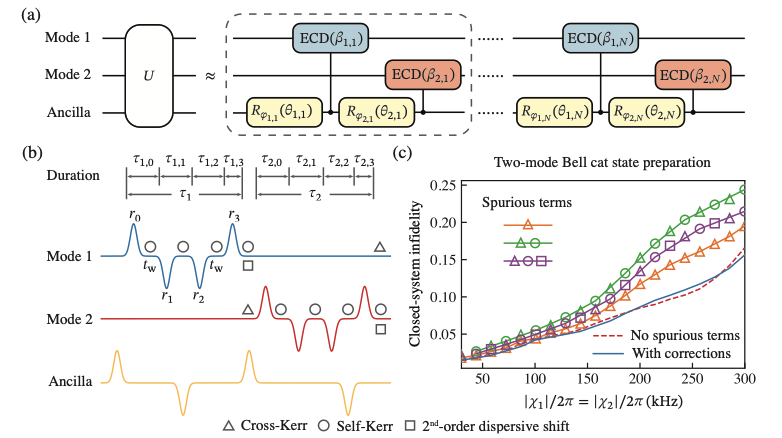

(Fig extracted from https://arxiv.org/pdf/2403.00275)

In [12]:
def Multimode_ECD_Compile(betas1_real,betas1_imag, betas2_real,betas2_imag, phis1, thetas1, phis2, thetas2,
                          Unitary, N_trunc, tol, Add_block = False, Disp = False, Mode='A'):

    '''Mode 'A'- cavity 1 
       Mode 'B' - cavity 2
       Mode 'AB' - cavities 1 and 2'''

    
       #   Transmon-Cavity1-Cavity2 
    def ECD1(beta_real, beta_imag, N_trunc):         
        return qt.tensor(qt.tensor(sigmap(), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)) + 
                qt.tensor(sigmam(), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2)), qt.qeye(N_trunc))

    def ECD2(beta_real, beta_imag, N_trunc):         
        return qt.tensor(qt.tensor(sigmap(), qt.qeye(N_trunc)), displace(N_trunc, (beta_real+ 1j*beta_imag)/2)
                        ) + qt.tensor(qt.tensor(sigmam(), qt.qeye(N_trunc)), displace(N_trunc, -(beta_real+ 1j*beta_imag)/2))
    
    # def Rot(phi, theta, N_trunc):
    #     return tensor(rz(phi) * rx(theta) * rz(-phi), qeye(N_trunc))
    
    def mRot(phi, theta, N_trunc):
        sx = qt.tensor(qt.tensor(qt.sigmax(), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        sy = qt.tensor(qt.tensor(qt.sigmay(), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        idty = qt.tensor(qt.tensor(qt.qeye(2), qt.qeye(N_trunc)), qt.qeye(N_trunc))
        if theta == 0:
            return idty
        else:          
            return ((np.cos(theta/2.0))*idty - 1j * ((np.cos(phi) * sx) + (np.sin(phi) * sy)) * np.sin(theta/2.0))
       
        # return (-1j*(theta/2.0)*(np.cos(phi)*self.sx + np.sin(phi)*self.sy)).expm()        
        # return np.cos(theta / 2.0) * idty - 1j * (
        #     np.cos(phi) * sx + np.sin(phi) * sy
        # ) * np.sin(theta / 2.0)
    
    
    # One ECD Block
    def U_block_ECD(beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2,  N_trunc):
        return  ECD2(beta2_real, beta2_imag,  N_trunc)*mRot(phi2, theta2, N_trunc)*ECD1(beta1_real, beta1_imag, 
                                                                                   N_trunc) * mRot(phi1, theta1, N_trunc) 

    # Sequence of ECD blocks
    def U_circuit_ECD(betas1_real, betas1_imag, betas2_real, betas2_imag, phis1, thetas1, phis2, thetas2, N_trunc):
        
        U = qt.tensor(qt.tensor(qt.identity(2), qt.identity(N_trunc)), qt.qeye(N_trunc))
        for beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2 in zip(betas1_real[:-1], 
                betas1_imag[:-1], betas2_real[:-1], betas2_imag[:-1], phis1[:-1], thetas1[:-1], phis2[:-1], thetas2[:-1]): # [:-1] removes the last element in the list since they are  Disp. and rotation parameter
            U = U_block_ECD(beta1_real, beta1_imag, beta2_real, beta2_imag, phi1, theta1, phi2, theta2,  N_trunc) * U
            # U = U_block_ECD2(beta_real, beta_imag, phi, theta, N_trunc) * U
        
        if Add_block == False:
            return U
        else:
            return qt.tensor(qt.tensor(qt.qeye(2), qt.qeye(N_trunc)),displace(N_trunc, (betas2_real[-1]+ 1j*
                    betas2_imag[-1])/2)) * mRot(phis2[-1], thetas2[-1], N_trunc)*qt.tensor(qt.tensor(qt.qeye(2), displace(N_trunc, 
                        (betas1_real[-1]+ 1j*betas1_imag[-1])/2)),qt.qeye(N_trunc)) * mRot(phis1[-1], thetas1[-1], N_trunc) * U
    
    def Unitary_cost(Oper1, Oper2):
              # tracedist(Oper1, Oper1)
            # cost = 1- (abs((Oper1.dag()*Oper2).tr()/Oper1.shape[0]))**2
            U1 = Qobj(Oper1[0:N_trunc**2, 0:N_trunc**2]- Oper2[0:N_trunc**2, 0:N_trunc**2], dims = [N_trunc**2, N_trunc**2])
            # U2 = Qobj(Oper1[N_trunc:2*N_trunc, N_trunc:2*N_trunc]- Oper2[N_trunc:2*N_trunc, N_trunc:2*N_trunc],dims = [N_trunc, N_trunc])      
            cost = np.sqrt((U1.dag()*U1).tr())        
            return cost                      
    
    opt_process = {}  
    def my_callback(result):
        """
        A callback function to monitor optimization progress.
        """
        val = Error_func(result, Unitary, N_trunc)
        opt_process[val]= result
    
    # Trace norm
    
    def Error_func(params, Unitary, N_trunc):
        '''params=[betas1_real, betas1_imag, betas2_real, betas2_imag, phis1, thetas1, phis2, thetas2] - hence 8l sized list '''
        ''''  args = (Unitary)'''
        
        r = int(len(params)/8)
        U = U_circuit_ECD(params[0:r], params[r:2*r], params[2*r:3*r], params[3*r:4*r], params[4*r:5*r], 
                          params[5*r:6*r], params[6*r:7*r], params[7*r:8*r],N_trunc)
        return Unitary_cost(Unitary, U)

    def grad(ini_params, Unitary, N_trunc):

        deriv = [] 
        epsilon = 5e-8
        for i in range(len(ini_params)):
            new_params_plus = [ele for ele in ini_params]
            new_params_minus = [ele for ele in ini_params] 
            new_params_plus[i] = ini_params[i] + epsilon
            new_params_minus[i] = ini_params[i] - epsilon
            partial_deriv_i = (Error_func(new_params_plus, Unitary, N_trunc) 
                               - Error_func(new_params_minus, Unitary, N_trunc))/(2*np.sinh(epsilon))
            deriv.append(partial_deriv_i)  
        return deriv

    def grad2(ini_params, Unitary, N_trunc):

        deriv = []
        h = 1e-8
        for i in range(len(ini_params)):            
            params_plus = [ele for ele in ini_params]
            params_plus[i] = params_plus[i] + h
            partial_deriv_i = (Error_func(params_plus, Unitary, N_trunc) 
                               - Error_func(ini_params, Unitary, N_trunc))/h
            deriv.append(partial_deriv_i)  
        return deriv


    if Mode == 'A':
        print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 1 '+ '*'*20 )
        return  ECD_Compile(betas1_real,betas1_imag , phis1, thetas1, Unitary, N_trunc, tol, Add_block = Add_block, Disp = Disp)

    elif Mode == 'B':
         print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 2 '+ '*'*20 )
         return ECD_Compile(betas2_real,betas2_imag , phis2, thetas2, Unitary, N_trunc, tol, Add_block = Add_block, Disp = Disp)

    
    else: 
        print('\n'+'*'*20 + ' Compiling for Unitary in Cavity 1 and 2 '+ '*'*20 )
        if Unitary.isunitary == False:
            raise ValueError("Provided operator is non-unitary.")
        
    
        
        if Add_block == True:
            Extra_block = 1
        else:
            Extra_block = 0        
            
        phis_thetas = np.concatenate((phis1, np.concatenate((thetas1, np.concatenate((phis2, thetas2))))))
        betasreal_betas_imag = np.concatenate((betas1_real, np.concatenate((betas1_imag, np.concatenate((betas2_real, betas2_imag))))))
        ini_params = np.concatenate((betasreal_betas_imag, phis_thetas))
        k = int(len(ini_params)/8)

        print('\n' + '*'* 20 + f' Optimizing Parameters for {k - 1 + Extra_block} blocks ' 
              + f'including {Extra_block} Disp_Rot block ' + '*'* 20 )
        res = minimize(Error_func, ini_params, args = (Unitary, N_trunc), method = 'L-BFGS-B',  jac = grad,
                       tol = tol, callback = my_callback)    # jac = grad,, options={'gtol': 1e-8, 'maxiter':1000}

        opt_arg = res.x
        opt_val = res.fun   
        opt_hist = list(opt_process.keys())
    
        out_dict = {'Infidelity': opt_val, 'Betas1_real': opt_arg[0:k], 'Betas1_imag': opt_arg[k:2*k], 'Betas2_real': opt_arg[2*k:3*k],
                    'Betas2_imag': opt_arg[3*k:4*k], 'Phis1': opt_arg[4*k:5*k], 'Thetas1': opt_arg[5*k:6*k], 'Phis2': opt_arg[6*k:7*k],
                    'Thetas2': opt_arg[7*k:8*k]}    
        


        # Plot optimization History
        if Disp==True:
            plt.plot(range(len(opt_hist)), opt_hist, marker='o', linestyle='dashed')
            plt.axhline(y = opt_val, color = 'r', linestyle='--', label= f'y = {opt_val:.3g}')
            plt.title(f'Optimization History for {k} blocks with {Extra_block} Disp_Rot block.')
            plt.grid(which = 'both', axis='both')
            plt.ylabel('Infidelity')
            plt.xlabel('Number of shots')
            plt.yscale('log')
            plt.legend()
            plt.show()
            Mat = U_circuit_ECD(opt_arg[0:k],opt_arg[k:2*k], opt_arg[2*k:3*k], opt_arg[3*k:4*k],  opt_arg[4*k:5*k], opt_arg[5*k:6*k], opt_arg[6*k:7*k],
                          opt_arg[7*k:8*k],N_trunc)
            
        return out_dict, Mat

In [16]:
np.random.seed(10)
length = 6

# ECD sequence length (+1 since an extra block is used for unconditional displacement + Rotation)
N_blocks = length +1 

N_trunc = 2
betas1_real= np.random.randn(N_blocks) 
betas1_imag= np.random.randn(N_blocks)
betas2_real= np.random.randn(N_blocks) 
betas2_imag= np.random.randn(N_blocks)
phis1 =  np.random.randn(N_blocks)
thetas1 = 2*np.pi*np.random.randn(N_blocks)
phis2 =  np.random.randn(N_blocks)
thetas2 = 2*np.pi*np.random.randn(N_blocks)
tol = 1e-12 

In [17]:
# Define cavity unitary
# mat = np.zeros((N_trunc, N_trunc), dtype = np.complex64)
# mat[0,1]= 1
# mat[1,0] = 1
# for k in range(N_trunc):
#     mat[k,k] = np.exp(1j*np.pi*(k+1)/2)
# cav_unitary = Qobj(mat, dims = [N_trunc, N_trunc])

# generate random cavity unitary
mcav_unitary1 = Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])   
mcav_unitary2 = qt.qeye(N_trunc)       #Qobj(unitary_group.rvs(N_trunc), dims = [N_trunc, N_trunc])  

# generate random Transmon unitary
trans_unitary = Qobj(unitary_group.rvs(2), dims = [2, 2])      
# mUnitary = qt.tensor(qt.tensor(trans_unitary, mcav_unitary1), mcav_unitary2)
mUnitary = qt.tensor(qt.tensor(qt.qeye(2), mcav_unitary1), mcav_unitary2)


# generate random full unitary for 2-mode
twoMode_unitary = Qobj(unitary_group.rvs(N_trunc**2), dims = [[N_trunc, N_trunc], [N_trunc, N_trunc]]) 
mUnitary2 = qt.tensor(qt.qeye(2), twoMode_unitary)
   


******************** Compiling for Unitary in Cavity 1 and 2 ********************

******************** Optimizing Parameters for 6 blocks including 0 Disp_Rot block ********************


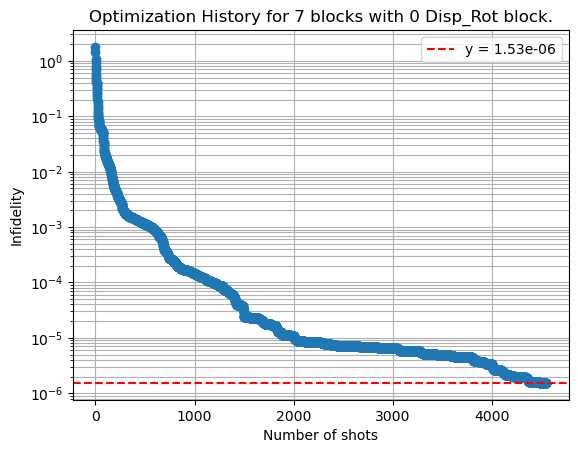

CPU times: user 1h 37min 5s, sys: 876 ms, total: 1h 37min 6s
Wall time: 1h 37min 6s


({'Infidelity': 1.534884863095222e-06,
  'Betas1_real': array([ 0.0488301 ,  0.80867379, -0.89720308, -0.49108853, -0.54508241,
         -1.01705455,  0.26551159]),
  'Betas1_imag': array([ 1.87758837,  1.62168319, -0.87178649,  0.54738381,  0.95002416,
         -1.13057876,  1.02827408]),
  'Betas2_real': array([ 0.61610311,  0.80558273, -0.68454095,  0.42894885,  1.84373604,
         -0.40609987, -1.97772828]),
  'Betas2_imag': array([-2.05096148,  0.31134229,  1.35210868, -0.3866069 ,  1.56847633,
          0.76742327,  1.39799638]),
  'Phis1': array([-1.20199267,  0.28178358,  0.27382683, -1.11131119,  2.10222987,
         -2.2704007 ,  1.30847308]),
  'Thetas1': array([ 2.68021337,  2.45425915, -1.41848597,  7.69749624, -5.11402249,
          4.53144043, -2.20459311]),
  'Phis2': array([ 0.1103019 , -1.40349905, -1.49607354, -0.24322807, -1.4025905 ,
          0.85429797,  0.56515267]),
  'Thetas2': array([-1.3271753 , -0.38548386,  1.68527566, -4.36287781,  4.62676139,
          

In [18]:
%time Multimode_ECD_Compile(betas1_real,betas1_imag, betas2_real,betas2_imag, phis1, thetas1, phis2, thetas2, mUnitary2, N_trunc, tol, Add_block = False, Disp=True, Mode='AB')

In [19]:
mUnitary2

Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dia, isherm=False
Qobj data =
[[-0.08422774+0.08480357j  0.28998502-0.49896756j -0.01751261+0.19443708j
   0.78015784-0.07678133j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.58873247-0.02416569j  0.25631957-0.02458436j -0.62346028+0.11589575j
  -0.24922364-0.34965556j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.77482405-0.18817201j  0.25315445-0.15783482j -0.44069184+0.19527835j
  -0.16217787-0.1288231j   0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.02570193+0.04585345j -0.52474614-0.4860848j  -0.45737787-0.34382486j
  -0.00903989+0.39762817j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j         -0.08422774+0.08480357j  0.28998502-